In [2]:
import pandas as pd
import numpy as np
from PIL import Image
from pathlib import Path

DATA_ROOT = Path("/kaggle/input/datasets/esayasmelaku/solar-flare-boucheron-c1-224")

for item in DATA_ROOT.iterdir():
    print(item)

labels_csv = DATA_ROOT / "Lat60_Lon60_Nans0_C1.0_24hr_png_224_features.csv"
df = pd.read_csv(labels_csv, header=None)
print(df.shape)
print(df.head())

df.columns = [f"feature_{i}" for i in range(29)] + ["label", "flare_size", "filename"]
print(df["label"].value_counts())

/kaggle/input/datasets/esayasmelaku/solar-flare-boucheron-c1-224/List_of_AR_in_Train_Data_by_AR.csv
/kaggle/input/datasets/esayasmelaku/solar-flare-boucheron-c1-224/List_of_AR_in_Validation_data_by_AR.csv
/kaggle/input/datasets/esayasmelaku/solar-flare-boucheron-c1-224/README.md
/kaggle/input/datasets/esayasmelaku/solar-flare-boucheron-c1-224/List_of_AR_in_Test_Data_by_AR.csv
/kaggle/input/datasets/esayasmelaku/solar-flare-boucheron-c1-224/Lat60_Lon60_Nans0_C1.0_24hr_png_224_features.csv
/kaggle/input/datasets/esayasmelaku/solar-flare-boucheron-c1-224/Validation_Data_by_AR_png_224.csv
/kaggle/input/datasets/esayasmelaku/solar-flare-boucheron-c1-224/Lat60_Lon60_Nans0_png_224
/kaggle/input/datasets/esayasmelaku/solar-flare-boucheron-c1-224/Train_Data_by_AR_png_224.csv
/kaggle/input/datasets/esayasmelaku/solar-flare-boucheron-c1-224/Test_Data_by_AR_png_224.csv
/kaggle/input/datasets/esayasmelaku/solar-flare-boucheron-c1-224/C1.0_24hr_224_png_Labels.txt
(950047, 32)
         0         1   

label
0    759465
1    190582
Name: count, dtype: int64
label
0    79.94
1    20.06
Name: count, dtype: float64


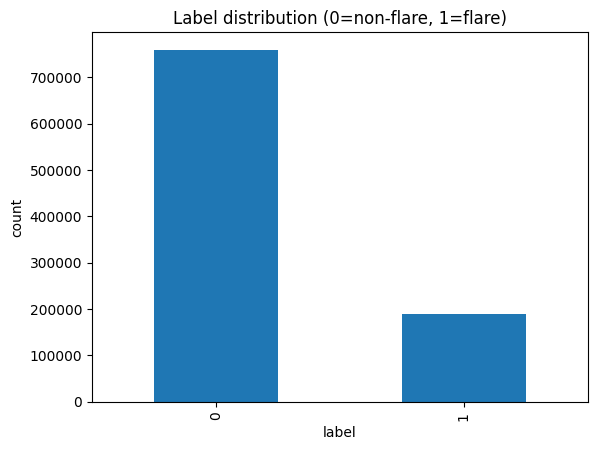

Number of unique ARs: 1570
count    1570.000000
mean      605.125478
std       316.406007
min         3.000000
25%       335.250000
50%       633.500000
75%       915.000000
max      1080.000000
dtype: float64


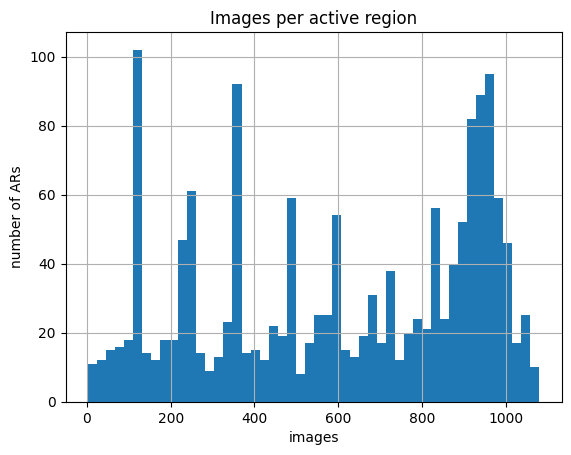

In [3]:
import matplotlib.pyplot as plt

# --- Class balance ---
counts = df["label"].value_counts()
print(counts)
print((counts / counts.sum() * 100).round(2))

plt.figure()
counts.plot(kind="bar")
plt.title("Label distribution (0=non-flare, 1=flare)")
plt.xlabel("label"); plt.ylabel("count")
plt.show()

# --- Extract AR number from filename (first part before underscore) ---
df["AR_number"] = df["filename"].str.split("_").str[0]
per_ar = df.groupby("AR_number").size()
print("Number of unique ARs:", len(per_ar))
print(per_ar.describe())

plt.figure()
per_ar.hist(bins=50)
plt.title("Images per active region")
plt.xlabel("images"); plt.ylabel("number of ARs")
plt.show()

In [4]:
IMAGE_ROOT_REAL = DATA_ROOT / "Lat60_Lon60_Nans0_png_224" / "Lat60_Lon60_Nans0_png_224"

sample_row = df.iloc[0]
sample_path = IMAGE_ROOT_REAL / sample_row["AR_number"] / sample_row["filename"]
print("Testing path:", sample_path)
print("Exists:", sample_path.exists())

if sample_path.exists():
    img = Image.open(sample_path)
    arr = np.array(img)
    print("Size:", img.size, "Mode:", img.mode, "dtype:", arr.dtype)
    print("Min:", arr.min(), "Max:", arr.max(), "Mean:", arr.mean())

Testing path: /kaggle/input/datasets/esayasmelaku/solar-flare-boucheron-c1-224/Lat60_Lon60_Nans0_png_224/Lat60_Lon60_Nans0_png_224/1064/1064_hmi.M_720s.20100501_000000_TAI.1.magnetogram_224.png
Exists: True
Size: (224, 224) Mode: L dtype: uint8
Min: 70 Max: 172 Mean: 127.51094148596938


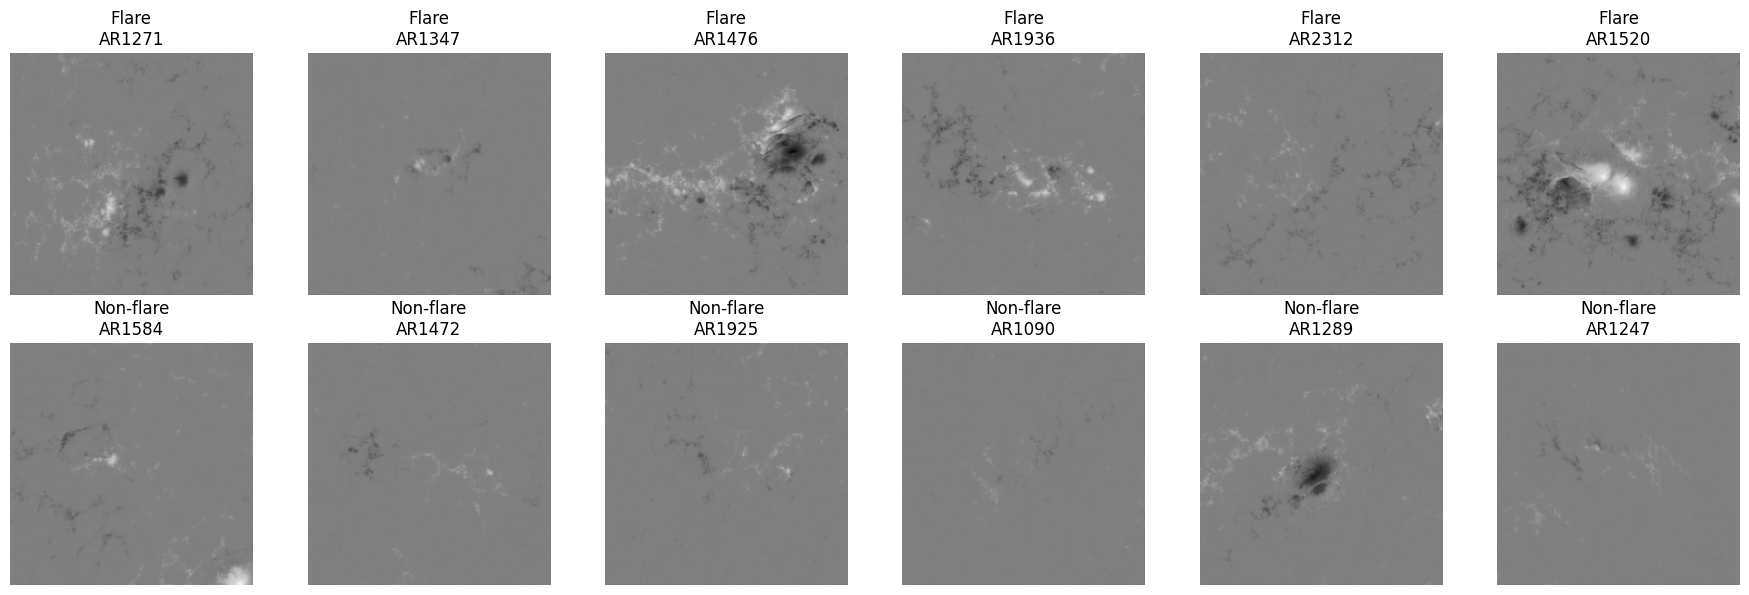

In [5]:
import matplotlib.pyplot as plt

def get_image_path(row):
    return IMAGE_ROOT_REAL / row["AR_number"] / row["filename"]

# Sample 6 flare and 6 non-flare images
flare_sample = df[df["label"] == 1].sample(6, random_state=1)
nonflare_sample = df[df["label"] == 0].sample(6, random_state=1)

fig, axes = plt.subplots(2, 6, figsize=(18, 6))
for i, (_, row) in enumerate(flare_sample.iterrows()):
    p = get_image_path(row)
    img = np.array(Image.open(p))
    axes[0, i].imshow(img, cmap="gray", vmin=0, vmax=255)
    axes[0, i].set_title(f"Flare\nAR{row['AR_number']}")
    axes[0, i].axis("off")

for i, (_, row) in enumerate(nonflare_sample.iterrows()):
    p = get_image_path(row)
    img = np.array(Image.open(p))
    axes[1, i].imshow(img, cmap="gray", vmin=0, vmax=255)
    axes[1, i].set_title(f"Non-flare\nAR{row['AR_number']}")
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()

In [6]:
import hashlib
from collections import defaultdict

# Sample 300 images for corruption/duplicate check (checking all 950k would take too long)
check_sample = df.sample(300, random_state=42)

corrupted = []
hashes = defaultdict(list)

for _, row in check_sample.iterrows():
    p = get_image_path(row)
    if not p.exists():
        corrupted.append((str(p), "missing"))
        continue
    try:
        Image.open(p).verify()
        with open(p, "rb") as f:
            h = hashlib.md5(f.read()).hexdigest()
        hashes[h].append(str(p))
    except Exception as e:
        corrupted.append((str(p), str(e)))

print(f"Corrupted/missing in sample of 300: {len(corrupted)}")
dupes = {h: paths for h, paths in hashes.items() if len(paths) > 1}
print(f"Duplicate groups found: {len(dupes)}")

# --- AR-level leakage check: does the official split avoid overlap? ---
train_ar = pd.read_csv(DATA_ROOT / "List_of_AR_in_Train_Data_by_AR.csv", header=None)
val_ar = pd.read_csv(DATA_ROOT / "List_of_AR_in_Validation_data_by_AR.csv", header=None)
test_ar = pd.read_csv(DATA_ROOT / "List_of_AR_in_Test_Data_by_AR.csv", header=None)

train_ids = set(train_ar[0].astype(str))
val_ids = set(val_ar[0].astype(str))
test_ids = set(test_ar[0].astype(str))

print("Train ARs:", len(train_ids), "Val ARs:", len(val_ids), "Test ARs:", len(test_ids))
print("Train∩Val overlap:", train_ids & val_ids)
print("Train∩Test overlap:", train_ids & test_ids)
print("Val∩Test overlap:", val_ids & test_ids)

Corrupted/missing in sample of 300: 0
Duplicate groups found: 0
Train ARs: 1256 Val ARs: 157 Test ARs: 157
Train∩Val overlap: set()
Train∩Test overlap: set()
Val∩Test overlap: set()


In [7]:
report = f"""
BOUCHERON SOLAR FLARE DATASET — FINAL DATA REPORT
==================================================

SOURCE
Boucheron, Vincent, Grajeda, Wuest (New Mexico State University)
Labels/metadata DOI: 10.5061/dryad.jq2bvq898
Images DOI: 10.5281/zenodo.7775776
Paper: arxiv.org/abs/2305.09492
Permanent Kaggle Dataset: esayasmelaku/solar-flare-boucheron-c1-224

DATASET SUMMARY
Active regions: 1,570
Total images: 950,047
Image size: 224x224, grayscale (mode L), uint8
Date range: May 2010 - Dec 2018 (per README)
Label: 1 = GOES flare >C1.0 within 24hrs after image, 0 = no such flare
Class balance: 79.94% non-flare (759,465), 20.06% flare (190,582)
Images per AR: min 3, max 1080, mean ~605

DATA QUALITY (sample of 300 images)
Corrupted/missing: 0
Duplicates: 0

OFFICIAL SPLIT (verified, not assumed)
Train ARs: 1256, Val ARs: 157, Test ARs: 157
AR-level overlap between splits: NONE (verified via set intersection)
Conclusion: official split is leakage-safe at the AR level

TEMPORAL STRUCTURE
Filenames confirmed to include NOAA AR number and exact timestamp
(e.g. 1064_hmi.M_720s.20100501_000000_TAI...), cadence ~720 seconds (12 min),
consistent with README's stated acquisition cadence.

ML IMPLICATIONS
- Use the authors' official AR-level split (Train/Validation/Test_Data_by_AR_png_224.csv)
  rather than a random image-level split, to avoid leakage.
- 20%/80% class imbalance likely needs class weighting or resampling during training.
- Temporal modeling (CNN+GRU/LSTM per AR sequence) is feasible: real, evenly-spaced
  timestamped sequences exist per AR (confirmed, not assumed).
- Recommended next step: build a baseline single-frame CNN using the official split
  first, establish a benchmark, then evaluate whether adding temporal modeling improves
  on it — consistent with van der Sande et al. 2023's finding referenced in the project notes.
"""

print(report)
with open("/kaggle/working/data_report.txt", "w") as f:
    f.write(report)
print("\nReport saved to /kaggle/working/data_report.txt")


BOUCHERON SOLAR FLARE DATASET — FINAL DATA REPORT

SOURCE
Boucheron, Vincent, Grajeda, Wuest (New Mexico State University)
Labels/metadata DOI: 10.5061/dryad.jq2bvq898
Images DOI: 10.5281/zenodo.7775776
Paper: arxiv.org/abs/2305.09492
Permanent Kaggle Dataset: esayasmelaku/solar-flare-boucheron-c1-224

DATASET SUMMARY
Active regions: 1,570
Total images: 950,047
Image size: 224x224, grayscale (mode L), uint8
Date range: May 2010 - Dec 2018 (per README)
Label: 1 = GOES flare >C1.0 within 24hrs after image, 0 = no such flare
Class balance: 79.94% non-flare (759,465), 20.06% flare (190,582)
Images per AR: min 3, max 1080, mean ~605

DATA QUALITY (sample of 300 images)
Corrupted/missing: 0
Duplicates: 0

OFFICIAL SPLIT (verified, not assumed)
Train ARs: 1256, Val ARs: 157, Test ARs: 157
AR-level overlap between splits: NONE (verified via set intersection)
Conclusion: official split is leakage-safe at the AR level

TEMPORAL STRUCTURE
Filenames confirmed to include NOAA AR number and exact t

In [8]:
train_ar = pd.read_csv(DATA_ROOT / "List_of_AR_in_Train_Data_by_AR.csv", header=None)[0].astype(str)
val_ar = pd.read_csv(DATA_ROOT / "List_of_AR_in_Validation_data_by_AR.csv", header=None)[0].astype(str)
test_ar = pd.read_csv(DATA_ROOT / "List_of_AR_in_Test_Data_by_AR.csv", header=None)[0].astype(str)

train_data = df[df["AR_number"].isin(train_ar)]
val_data = df[df["AR_number"].isin(val_ar)]
test_data = df[df["AR_number"].isin(test_ar)]

print("Train:", train_data.shape, "Val:", val_data.shape, "Test:", test_data.shape)

Train: (759357, 33) Val: (95933, 33) Test: (94757, 33)


In [9]:
import numpy as np
from sklearn.preprocessing import StandardScaler

feature_cols = [f"feature_{i}" for i in range(29)]

# --- Missing value check ---
print("Missing values per feature (train set):")
print(train_data[feature_cols].isna().sum())
print("\nMissing values per feature (val set):")
print(val_data[feature_cols].isna().sum())
print("\nMissing values per feature (test set):")
print(test_data[feature_cols].isna().sum())

# --- Infinite values ---
print("\nInfinite values in train set:", np.isinf(train_data[feature_cols].values).sum())

# --- Constant-feature check ---
print("\nfeature_3 / feature_14 check:")
print(train_data[["feature_3", "feature_14"]].describe())
print("Unique values -- feature_3:", train_data["feature_3"].nunique(),
      " feature_14:", train_data["feature_14"].nunique())

Missing values per feature (train set):
feature_0     0
feature_1     0
feature_2     0
feature_3     0
feature_4     0
feature_5     0
feature_6     0
feature_7     0
feature_8     0
feature_9     0
feature_10    0
feature_11    0
feature_12    0
feature_13    0
feature_14    0
feature_15    0
feature_16    0
feature_17    0
feature_18    0
feature_19    0
feature_20    0
feature_21    0
feature_22    0
feature_23    0
feature_24    0
feature_25    0
feature_26    0
feature_27    0
feature_28    0
dtype: int64

Missing values per feature (val set):
feature_0     0
feature_1     0
feature_2     0
feature_3     0
feature_4     0
feature_5     0
feature_6     0
feature_7     0
feature_8     0
feature_9     0
feature_10    0
feature_11    0
feature_12    0
feature_13    0
feature_14    0
feature_15    0
feature_16    0
feature_17    0
feature_18    0
feature_19    0
feature_20    0
feature_21    0
feature_22    0
feature_23    0
feature_24    0
feature_25    0
feature_26    0
feature_27  

In [10]:
scaler = StandardScaler()

X_train = scaler.fit_transform(train_data[feature_cols])
X_val = scaler.transform(val_data[feature_cols])
X_test = scaler.transform(test_data[feature_cols])

y_train = train_data["label"].values
y_val = val_data["label"].values
y_test = test_data["label"].values

print("X_train shape:", X_train.shape)
print("X_train mean (should be ~0):", X_train.mean().round(3))
print("X_train std (should be ~1):", X_train.std().round(3))

X_train shape: (759357, 29)
X_train mean (should be ~0): 0.0
X_train std (should be ~1): 0.965


In [11]:
from sklearn.svm import LinearSVC
import time

start = time.time()

svm_model = LinearSVC(
    class_weight="balanced",   # corrects for the 80/20 imbalance
    max_iter=5000,             # LinearSVC sometimes needs more iterations to converge on large data
    random_state=42
)

svm_model.fit(X_train, y_train)

elapsed = time.time() - start
print(f"Training finished in {elapsed/60:.1f} minutes")

Training finished in 0.3 minutes


In [12]:
from sklearn.metrics import confusion_matrix

val_preds = svm_model.predict(X_val)
print("Prediction distribution:", pd.Series(val_preds).value_counts())
print("\nConfusion matrix:")
print(confusion_matrix(y_val, val_preds))

Prediction distribution: 0    62671
1    33262
Name: count, dtype: int64

Confusion matrix:
[[57830 18312]
 [ 4841 14950]]


In [13]:
def tss_hss(y_true, pred):
    tn, fp, fn, tp = confusion_matrix(y_true, pred).ravel()
    tpr, tnr = tp / (tp + fn), tn / (tn + fp)
    tss = tpr + tnr - 1
    hss = 2 * (tp*tn - fn*fp) / ((tp+fn)*(fn+tn) + (tp+fp)*(fp+tn))
    return tpr, tnr, tss, hss

# --- Operating point 1: default decision (LinearSVC's own built-in threshold) ---
test_preds = svm_model.predict(X_test)
val_tpr_def, val_tnr_def, val_tss_def, val_hss_def = tss_hss(y_val, val_preds)
tpr_def, tnr_def, tss_def, hss_def = tss_hss(y_test, test_preds)

# --- Operating point 2: threshold tuned on VALIDATION only (maximize TSS), applied unchanged to test ---
val_scores = svm_model.decision_function(X_val)
test_scores = svm_model.decision_function(X_test)

thresholds = np.linspace(val_scores.min(), val_scores.max(), 300)
best_tss, best_thresh = -1, 0.0
for t in thresholds:
    preds = (val_scores >= t).astype(int)
    _, _, tss, _ = tss_hss(y_val, preds)
    if tss > best_tss:
        best_tss, best_thresh = tss, t

test_preds_tuned = (test_scores >= best_thresh).astype(int)
tpr, tnr, tss_tuned, hss_tuned = tss_hss(y_test, test_preds_tuned)

print(f"{'Operating point':<28}{'TPR':>8}{'TNR':>8}{'TSS':>8}{'HSS':>8}")
print(f"{'Validation, default':<28}{val_tpr_def:>8.4f}{val_tnr_def:>8.4f}{val_tss_def:>8.4f}{val_hss_def:>8.4f}")
print(f"{'Test, default':<28}{tpr_def:>8.4f}{tnr_def:>8.4f}{tss_def:>8.4f}{hss_def:>8.4f}")
print(f"{'Validation, tuned thr':<28}{'   -':>8}{'   -':>8}{best_tss:>8.4f}{'   -':>8}")
print(f"{'Test, tuned thr':<28}{tpr:>8.4f}{tnr:>8.4f}{tss_tuned:>8.4f}{hss_tuned:>8.4f}")
print(f"\nTuned threshold (chosen on validation only, never touching test): {best_thresh:.4f}")

Operating point                  TPR     TNR     TSS     HSS
Validation, default           0.7554  0.7595  0.5149  0.4113
Test, default                 0.7821  0.7560  0.5382  0.4427
Validation, tuned thr              -       -  0.5177       -
Test, tuned thr               0.7515  0.7895  0.5409  0.4644

Tuned threshold (chosen on validation only, never touching test): 0.0588


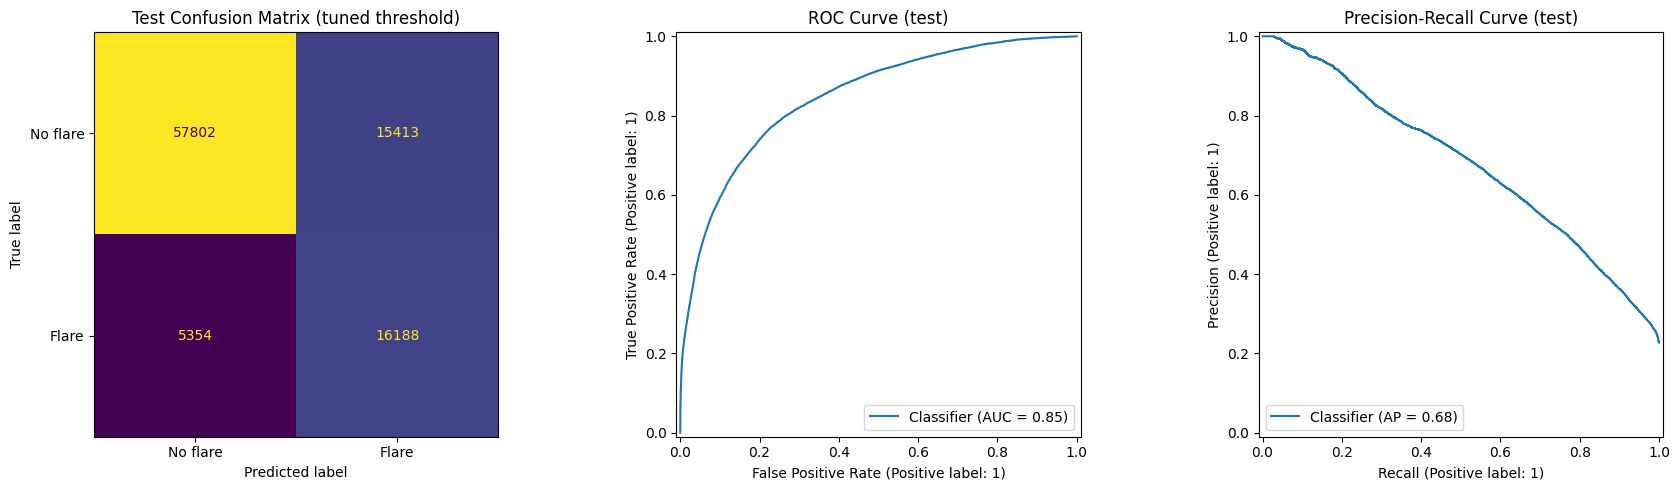

In [14]:
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
ConfusionMatrixDisplay.from_predictions(y_test, test_preds_tuned,
    display_labels=["No flare", "Flare"], ax=axes[0], colorbar=False)
axes[0].set_title("Test Confusion Matrix (tuned threshold)")
RocCurveDisplay.from_predictions(y_test, test_scores, ax=axes[1])
axes[1].set_title("ROC Curve (test)")
PrecisionRecallDisplay.from_predictions(y_test, test_scores, ax=axes[2])
axes[2].set_title("Precision-Recall Curve (test)")
plt.tight_layout()
plt.show()

Top magnetic-complexity features driving the SVM decision:

feature_0     3.270221e+00
feature_20   -2.293582e+00
feature_8    -5.257788e-01
feature_21   -4.793324e-01
feature_1     3.731584e-01
feature_22   -3.443468e-01
feature_7     3.439083e-01
feature_23   -2.738606e-01
feature_24   -2.448168e-01
feature_6    -1.506732e-01
feature_28    1.190681e-01
feature_26   -1.110130e-01
feature_9     1.056730e-01
feature_25    1.041666e-01
feature_5     6.048452e-02
feature_4     5.977531e-02
feature_11   -5.414549e-02
feature_12    2.724134e-02
feature_17    2.282902e-02
feature_27   -1.561464e-02
feature_2     1.519923e-02
feature_13    1.514020e-02
feature_15   -1.168520e-02
feature_10   -1.140208e-02
feature_16    7.823472e-03
feature_18    1.766380e-03
feature_19   -1.107877e-03
feature_14   -5.246453e-16
feature_3     0.000000e+00
dtype: float64


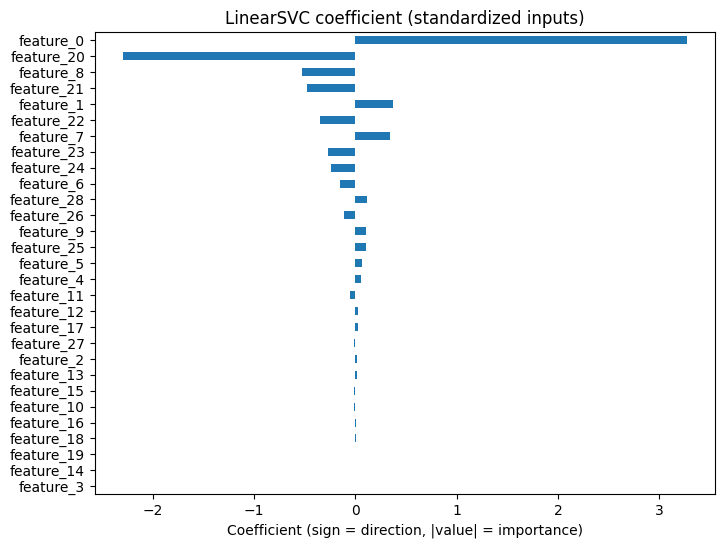

In [15]:
import pandas as pd

coef = svm_model.coef_.ravel()
importance = pd.Series(coef, index=feature_cols).sort_values(key=abs, ascending=False)
print("Top magnetic-complexity features driving the SVM decision:\n")
print(importance)

plt.figure(figsize=(8, 6))
importance.plot(kind="barh")
plt.title("LinearSVC coefficient (standardized inputs)")
plt.xlabel("Coefficient (sign = direction, |value| = importance)")
plt.gca().invert_yaxis()
plt.show()

In [16]:
rng = np.random.default_rng(42)
n_boot = 1000
# FIX (overfitting / stats): resample by AR, not by row. Rows from the same AR are
# correlated, so row-level bootstrap understates true uncertainty.
test_ar_ids = test_data["AR_number"].values
unique_ars = np.unique(test_ar_ids)
tss_boot = []

codes, uniq = pd.factorize(test_ar_ids); k = len(uniq)
pred_full = (test_scores >= best_thresh).astype(int)
cnt = np.stack([np.bincount(codes, weights=m.astype(float), minlength=k) for m in
                [(y_test == 1) & (pred_full == 1), (y_test == 1) & (pred_full == 0),
                 (y_test == 0) & (pred_full == 1), (y_test == 0) & (pred_full == 0)]], 1)
for _ in range(n_boot):
    tp, fn, fp, tn = cnt[rng.integers(0, k, k)].sum(0)   # an AR drawn twice counts twice
    tss_boot.append(tp/(tp+fn) - fp/(fp+tn))

ci_low, ci_high = np.percentile(tss_boot, [2.5, 97.5])
print(f"Test TSS: {tss_tuned:.4f}  (95% bootstrap CI, resampled by AR: [{ci_low:.4f}, {ci_high:.4f}])")


Test TSS: 0.5409  (95% bootstrap CI, resampled by AR: [0.4460, 0.6141])


In [17]:
import joblib
joblib.dump(svm_model, "/kaggle/working/svm_baseline_model.joblib")
joblib.dump(scaler, "/kaggle/working/svm_baseline_scaler.joblib")
joblib.dump({"threshold": best_thresh}, "/kaggle/working/svm_baseline_threshold.joblib")
print("Saved: svm_baseline_model.joblib, svm_baseline_scaler.joblib, svm_baseline_threshold.joblib")

Saved: svm_baseline_model.joblib, svm_baseline_scaler.joblib, svm_baseline_threshold.joblib


In [18]:
final_report = f"""
STAGE 1 — SVM BASELINE: FINAL RESULTS (LOCKED)
===============================================

METHOD
LinearSVC, class_weight='balanced', StandardScaler fit on train only.
Decision threshold tuned on validation set (maximize TSS), applied unchanged to test.
Chosen threshold: {best_thresh:.4f}

TEST SET (final, threshold tuned on val — no test leakage)
TPR: {tpr:.4f}   TNR: {tnr:.4f}
TSS: {tss_tuned:.4f}   (95% bootstrap CI: [{ci_low:.4f}, {ci_high:.4f}])
HSS: {hss_tuned:.4f}

VALIDATION SET
TSS: {best_tss:.4f}

BENCHMARK COMPARISON (same dataset, same official AR split)
Boucheron et al. 2023, linear SVM (reduced res): TSS 0.5348, HSS 0.4350
Boucheron et al. 2023, VGG16 frozen transfer:    TSS 0.5325, HSS 0.4636
This baseline: TSS {tss_tuned:.4f}, HSS {hss_tuned:.4f} -> reproduces the published SVM; it does not beat it.
(Bloomfield 2012 used a different dataset and method, so it is not a like-for-like comparison.)

DATA QUALITY NOTE
feature_3 and feature_14 are constant across all 759,357 training rows
(feature_3 = 0.0 always; feature_14 = 4.712389 always, std ≈ 5e-11).
These 2 of 29 features carry zero discriminative information in this
preconfigured dataset subset — confirmed via .describe()/.nunique(), not assumed.

ARTIFACTS SAVED
/kaggle/working/svm_baseline_model.joblib
/kaggle/working/svm_baseline_scaler.joblib
/kaggle/working/svm_baseline_threshold.joblib

STATUS: Stage 1 complete and locked. Proceeding to Stage 2 (CNN on raw images).
"""
print(final_report)
with open("/kaggle/working/stage1_final_report.txt", "w") as f:
    f.write(final_report)


STAGE 1 — SVM BASELINE: FINAL RESULTS (LOCKED)

METHOD
LinearSVC, class_weight='balanced', StandardScaler fit on train only.
Decision threshold tuned on validation set (maximize TSS), applied unchanged to test.
Chosen threshold: 0.0588

TEST SET (final, threshold tuned on val — no test leakage)
TPR: 0.7515   TNR: 0.7895
TSS: 0.5409   (95% bootstrap CI: [0.4460, 0.6141])
HSS: 0.4644

VALIDATION SET
TSS: 0.5177

BENCHMARK COMPARISON (same dataset, same official AR split)
Boucheron et al. 2023, linear SVM (reduced res): TSS 0.5348, HSS 0.4350
Boucheron et al. 2023, VGG16 frozen transfer:    TSS 0.5325, HSS 0.4636
This baseline: TSS 0.5409, HSS 0.4644 -> reproduces the published SVM; it does not beat it.
(Bloomfield 2012 used a different dataset and method, so it is not a like-for-like comparison.)

DATA QUALITY NOTE
feature_3 and feature_14 are constant across all 759,357 training rows
(feature_3 = 0.0 always; feature_14 = 4.712389 always, std ≈ 5e-11).
These 2 of 29 features carry zero 

In [19]:
# A1 — configuration, seeds, metrics
import os, re, json, time, random, warnings
import numpy as np, pandas as pd
from sklearn.metrics import (confusion_matrix, roc_curve, roc_auc_score,
                             average_precision_score, brier_score_loss)

CFG = dict(
    seed=42,
    hist_lag_h=24,        # flare-history lag. MUST be >= the 24 h label window, otherwise it leaks the future.
    lag_tol_min=30,       # a lag lookup must land within this many minutes of the wanted time (frames have gaps)
    roll_h=2,             # rolling mean/std window (hours)
    kurt_h=(3, 6, 12),    # kurtosis windows (hours)
    diff_h=(1, 3, 6, 12), # "change over the last X hours" lags
    top_k=10,             # how many base features get the temporal treatment (chosen by importance, TRAIN only)
    const_cols=("feature_3", "feature_14"),   # constant in this dataset (your cell 19)
)

def set_all_seeds(seed=CFG["seed"]):
    random.seed(seed); np.random.seed(seed)
    try:
        import torch
        torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    except ImportError:
        pass
set_all_seeds()

def skill_scores(y, pred):
    tn, fp, fn, tp = confusion_matrix(y, pred, labels=[0, 1]).ravel()
    d = lambda a, b: a / b if b else np.nan
    tpr, fpr = d(tp, tp + fn), d(fp, fp + tn)
    den = (tp + fn) * (fn + tn) + (tp + fp) * (fp + tn)
    return dict(TSS=tpr - fpr, HSS=d(2 * (tp * tn - fn * fp), den), POD=tpr, FPR=fpr,
                FAR=d(fp, tp + fp), CSI=d(tp, tp + fn + fp), TP=tp, FP=fp, FN=fn, TN=tn)

def best_tss_threshold(y, score):
    """Exact TSS-optimal threshold (TSS = TPR - FPR). Fit on VALIDATION only, then freeze."""
    fpr, tpr, thr = roc_curve(y, score)
    return float(thr[np.argmax(tpr - fpr)])

def prob_scores(y, p):
    bs = brier_score_loss(y, p)
    bs_ref = brier_score_loss(y, np.full(len(y), np.mean(y)))   # climatology reference
    return dict(ROC_AUC=roc_auc_score(y, p), PR_AUC=average_precision_score(y, p), Brier=bs, BSS=1 - bs / bs_ref)

def full_report(y, p, thr):
    return {**prob_scores(y, p), **skill_scores(y, (np.asarray(p) >= thr).astype(int))}

def ar_bootstrap(ar_ids, y, pred, n_boot=2000, seed=CFG["seed"]):
    """95% CI of TSS by resampling whole active regions (per-AR confusion counts -> fast)."""
    codes, _ = pd.factorize(np.asarray(ar_ids)); k = codes.max() + 1
    y, pred = np.asarray(y), np.asarray(pred)
    cnt = np.stack([np.bincount(codes, weights=m.astype(float), minlength=k) for m in
                    [(y == 1) & (pred == 1), (y == 1) & (pred == 0), (y == 0) & (pred == 1), (y == 0) & (pred == 0)]], 1)
    rng = np.random.default_rng(seed); out = []
    for _ in range(n_boot):
        tp, fn, fp, tn = cnt[rng.integers(0, k, k)].sum(0)
        out.append(tp / (tp + fn) - fp / (fp + tn))
    return np.percentile(out, [2.5, 97.5])
print("A1 ready.")

A1 ready.


In [20]:
# A2 — full-series table (uses df, train_ar, val_ar, test_ar from your cells 0 and 6)
base_cols = [f"feature_{i}" for i in range(29) if f"feature_{i}" not in CFG["const_cols"]]

def flare_score(s):
    """'C4.7' -> 47, 'M1.2' -> 120, 'X2.0' -> 2000 (weighting idea from Williams et al. 2026); no flare -> 0."""
    s = str(s).strip()
    if s in ("0", "0.0", "nan", "None", ""): return 0.0
    mult = {"C": 10.0, "M": 100.0, "X": 1000.0}.get(s[0].upper())
    try: return mult * float(s[1:]) if mult else 0.0
    except ValueError: return 0.0

T = df.copy()
T["AR"] = T["filename"].str.split("_").str[0]
T["ts"] = pd.to_datetime(T["filename"].str.extract(r"(\d{8}_\d{6})")[0], format="%Y%m%d_%H%M%S")
tr_ids, va_ids, te_ids = (set(map(str, s)) for s in (train_ar, val_ar, test_ar))
T["split"] = np.select([T.AR.isin(tr_ids), T.AR.isin(va_ids), T.AR.isin(te_ids)], ["train", "val", "test"], default="none")
assert (T.split == "none").sum() == 0, "some rows belong to no split"
fs_map = {s: flare_score(s) for s in T["flare_size"].astype(str).unique()}
T["fscore"] = T["flare_size"].astype(str).map(fs_map)
T = T.sort_values(["AR", "ts"]).reset_index(drop=True)
print(T.split.value_counts().to_dict(), "| ARs:", T.AR.nunique(), "| positives:", int(T.label.sum()))

{'train': 759357, 'val': 95933, 'test': 94757} | ARs: 1570 | positives: 190582


In [21]:
# T1 — config + raw-order monotonicity check (uses the ORIGINAL df, before our own sorting,
# so this checks whether the SOURCE FILES themselves are already time-ordered)
TOL_S = 60          # tolerance band around the 720s nominal cadence, in seconds
CADENCE_S = 720

raw_ts = pd.to_datetime(df["filename"].str.extract(r"(\d{8}_\d{6})")[0], format="%Y%m%d_%H%M%S", errors="coerce")
n_unparseable_total = int(raw_ts.isna().sum())

def _nonmono_count(g):
    t = g.to_numpy()
    ok = ~pd.isna(t)
    t = t[ok]
    if len(t) < 2:
        return 0
    return int((np.diff(t.astype("datetime64[s]").astype(np.int64)) < 0).sum())

nonmono_by_ar = raw_ts.groupby(df["AR_number"]).apply(_nonmono_count)
print(f"Unparseable timestamps in the whole dataset: {n_unparseable_total}")
print(f"ARs whose rows are NOT already time-ordered in the CSV: {(nonmono_by_ar > 0).sum()} / {df['AR_number'].nunique()}")
print(f"Total out-of-order adjacent pairs (raw file order): {int(nonmono_by_ar.sum())}")

Unparseable timestamps in the whole dataset: 0
ARs whose rows are NOT already time-ordered in the CSV: 0 / 1570
Total out-of-order adjacent pairs (raw file order): 0


In [22]:
# T2 — per-AR temporal summary (built on T, which is already parsed, time-sorted and
# split-labelled by your own cell A2 — no re-parsing, no re-splitting)
ar_ids   = T["AR"].to_numpy()
ts_s     = T["ts"].to_numpy("datetime64[s]").astype(np.int64)
lab_arr  = T["label"].to_numpy()
bounds   = np.flatnonzero(np.r_[True, ar_ids[1:] != ar_ids[:-1], True])   # same AR-block pattern as your A4/A6

rows = []
for a, b in zip(bounds[:-1], bounds[1:]):
    t = ts_s[a:b]
    n = b - a
    rec = dict(
        AR_number=ar_ids[a], n_observations=int(n),
        first_timestamp=pd.Timestamp(t[0], unit="s"), last_timestamp=pd.Timestamp(t[-1], unit="s"),
        duration_hours=(t[-1] - t[0]) / 3600.0,
    )
    if n >= 2:
        d = np.diff(t).astype(float)
        rec.update(
            median_delta_seconds=float(np.median(d)), mean_delta_seconds=float(np.mean(d)),
            min_delta_seconds=float(d.min()), max_delta_seconds=float(d.max()), std_delta_seconds=float(np.std(d)),
            n_duplicate_timestamps=int((d == 0).sum()),
            n_short_intervals=int(((d < CADENCE_S - TOL_S) & (d > 0)).sum()),
        )
        gaps = d[d > CADENCE_S + TOL_S]
        rec["n_large_gaps"] = int(len(gaps))
        missing = np.round(gaps / CADENCE_S) - 1
        rec["n_missing_intervals"] = int(missing[missing > 0].sum())
        rec["n_irregular_gaps"] = int((np.abs(gaps - np.round(gaps / CADENCE_S) * CADENCE_S) > TOL_S).sum())
    else:
        rec.update(median_delta_seconds=np.nan, mean_delta_seconds=np.nan, min_delta_seconds=np.nan,
                    max_delta_seconds=np.nan, std_delta_seconds=np.nan, n_duplicate_timestamps=0,
                    n_short_intervals=0, n_large_gaps=0, n_missing_intervals=0, n_irregular_gaps=0)
    rows.append(rec)

ar_temporal_summary = pd.DataFrame(rows)
ar_temporal_summary["sequence_length"] = ar_temporal_summary["n_observations"]
ar_temporal_summary["n_non_monotonic"] = ar_temporal_summary["AR_number"].map(nonmono_by_ar).fillna(0).astype(int)
ar_temporal_summary["n_unparseable_timestamps"] = (
    raw_ts.isna().groupby(df["AR_number"]).sum().reindex(ar_temporal_summary["AR_number"]).fillna(0).to_numpy().astype(int)
)
print("ar_temporal_summary:", ar_temporal_summary.shape)
display(ar_temporal_summary.head())

desc_cols = ["n_observations", "duration_hours", "median_delta_seconds", "mean_delta_seconds",
             "min_delta_seconds", "max_delta_seconds", "std_delta_seconds",
             "n_large_gaps", "n_missing_intervals", "n_duplicate_timestamps", "n_non_monotonic"]
display(ar_temporal_summary[desc_cols].describe(percentiles=[.25, .5, .75]).round(3))

ar_temporal_summary: (1570, 18)


,AR_number,n_observations,first_timestamp,last_timestamp,duration_hours,median_delta_seconds,mean_delta_seconds,min_delta_seconds,max_delta_seconds,std_delta_seconds,n_duplicate_timestamps,n_short_intervals,n_large_gaps,n_missing_intervals,n_irregular_gaps,sequence_length,n_non_monotonic,n_unparseable_timestamps
0,1064,358,2010-05-01 00:00:00,2010-05-03 23:48:00,71.8,720.0,724.033613,720.0,2160.0,76.106066,0,0,1,2,0,358,0,0
1,1065,240,2010-05-03 00:00:00,2010-05-04 23:48:00,47.8,720.0,720.000000,720.0,720.0,0.000000,0,0,0,0,0,240,0,0
2,1066,478,2010-05-03 00:00:00,2010-05-06 23:48:00,95.8,720.0,723.018868,720.0,2160.0,65.863922,0,0,1,2,0,478,0,0
3,1067,522,2010-05-03 15:12:00,2010-05-07 23:48:00,104.6,720.0,722.763916,720.0,2160.0,63.026972,0,0,1,2,0,522,0,0
4,1068,348,2010-05-06 02:00:00,2010-05-08 23:48:00,69.8,720.0,724.149856,720.0,2160.0,77.191782,0,0,1,2,0,348,0,0


,n_observations,duration_hours,median_delta_seconds,mean_delta_seconds,min_delta_seconds,max_delta_seconds,std_delta_seconds,n_large_gaps,n_missing_intervals,n_duplicate_timestamps,n_non_monotonic
count,1570.000,1570.000,1570.0,1570.000,1570.0,1570.000,1570.000,1570.000,1570.000,1570.0,1570.0
mean,605.125,123.429,720.0,736.465,720.0,5453.197,239.697,2.126,13.017,0.0,0.0
std,316.406,64.466,0.0,28.935,0.0,7470.924,357.230,3.472,20.450,0.0,0.0
min,3.000,0.400,720.0,720.000,720.0,720.000,0.000,0.000,0.000,0.0,0.0
25%,335.250,71.650,720.0,720.000,720.0,720.000,0.000,0.000,0.000,0.0,0.0
50%,633.500,130.100,720.0,723.019,720.0,2160.000,68.684,1.000,2.000,0.0,0.0
75%,915.000,187.400,720.0,744.235,720.0,7200.000,476.505,2.000,22.000,0.0,0.0
max,1080.000,215.800,720.0,1173.699,720.0,56160.000,3849.761,30.000,131.000,0.0,0.0


In [23]:
# T3 — cadence classification: what fraction of intervals are exact / approx / gap / short / duplicate
all_deltas = []
for a, b in zip(bounds[:-1], bounds[1:]):
    t = ts_s[a:b]
    if b - a >= 2:
        all_deltas.append(np.diff(t).astype(float))
all_deltas = np.concatenate(all_deltas) if all_deltas else np.array([])

exact   = (all_deltas == CADENCE_S)
approx  = (~exact) & (np.abs(all_deltas - CADENCE_S) <= TOL_S)
gap     = all_deltas > CADENCE_S + TOL_S
short   = (all_deltas > 0) & (all_deltas < CADENCE_S - TOL_S)
dup     = all_deltas == 0

print(f"Total intervals analysed: {len(all_deltas):,}")
for name, mask in [("exactly 720s", exact), (f"approx 720s (+/-{TOL_S}s)", approx),
                    ("> 720s (gap)", gap), ("< 720s (short, not duplicate)", short), ("duplicate (0s)", dup)]:
    print(f"  {name:32s} {mask.sum():>9,}  ({100*mask.mean():5.2f}%)")

def ar_bucket(row):
    if row["n_observations"] < 2: return "single-obs (n/a)"
    if row["n_large_gaps"] == 0 and row["n_duplicate_timestamps"] == 0 and row["n_short_intervals"] == 0:
        return "perfect/near-perfect cadence"
    if row["n_large_gaps"] <= 2:
        return "small deviations"
    return "significant gaps"
ar_temporal_summary["cadence_bucket"] = ar_temporal_summary.apply(ar_bucket, axis=1)
bucket_pct = (ar_temporal_summary["cadence_bucket"].value_counts(normalize=True) * 100).round(2)
print("\nPer-AR cadence quality:"); print(bucket_pct)

Total intervals analysed: 948,477
  exactly 720s                       945,139  (99.65%)
  approx 720s (+/-60s)                     0  ( 0.00%)
  > 720s (gap)                         3,338  ( 0.35%)
  < 720s (short, not duplicate)            0  ( 0.00%)
  duplicate (0s)                           0  ( 0.00%)

Per-AR cadence quality:
cadence_bucket
small deviations                42.93
perfect/near-perfect cadence    34.46
significant gaps                22.61
Name: proportion, dtype: float64


ARs with only label 0:            936
ARs with at least one label 1:    634
ARs with both 0 and 1:            614

Positive-run length (consecutive positive frames within an AR), across ARs that have any:
count     634.00
mean      212.41
std       182.88
min         6.00
25%       119.25
50%       131.00
75%       250.50
max      1013.00
Name: max_pos_run, dtype: float64

Hours between the LAST positive frame and the end of that AR's sequence:
count    634.00
mean      46.59
std       54.17
min        0.00
25%        0.00
50%       24.80
75%       78.40
max      207.80
Name: hours_last_positive_to_seq_end, dtype: float64


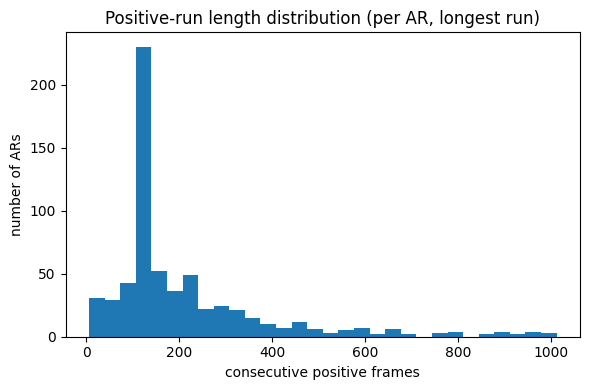

In [24]:
# T5 — label run-length analysis per AR (0-runs and 1-runs, transitions, and where
# positives sit relative to the end of the sequence)
run_rows = []
for a, b in zip(bounds[:-1], bounds[1:]):
    lab = lab_arr[a:b].astype(int)
    t = ts_s[a:b]
    n = len(lab)
    change = np.flatnonzero(np.r_[True, lab[1:] != lab[:-1], True])
    run_vals = lab[change[:-1]]; run_lens = np.diff(change)
    pos_lens = run_lens[run_vals == 1]
    trans_01 = int(((lab[:-1] == 0) & (lab[1:] == 1)).sum()) if n > 1 else 0
    trans_10 = int(((lab[:-1] == 1) & (lab[1:] == 0)).sum()) if n > 1 else 0
    has_pos = bool((lab == 1).any())
    pos_idx = np.flatnonzero(lab == 1)
    rec = dict(
        AR_number=ar_ids[a], n_observations=n,
        all_zero=bool((lab == 0).all()), has_positive=has_pos, has_both=has_pos and (lab == 0).any(),
        n_pos_runs=int(len(pos_lens)), max_pos_run=int(pos_lens.max()) if len(pos_lens) else 0,
        median_pos_run=float(np.median(pos_lens)) if len(pos_lens) else np.nan,
        n_transitions_0to1=trans_01, n_transitions_1to0=trans_10, n_transitions_total=trans_01 + trans_10,
        first_positive_timestamp=pd.Timestamp(t[pos_idx[0]], unit="s") if has_pos else pd.NaT,
        last_positive_timestamp=pd.Timestamp(t[pos_idx[-1]], unit="s") if has_pos else pd.NaT,
        hours_last_positive_to_seq_end=(t[-1] - t[pos_idx[-1]]) / 3600.0 if has_pos else np.nan,
    )
    run_rows.append(rec)
ar_label_run_summary = pd.DataFrame(run_rows)

n_all_zero = int(ar_label_run_summary["all_zero"].sum())
n_has_pos  = int(ar_label_run_summary["has_positive"].sum())
n_both     = int(ar_label_run_summary["has_both"].sum())
print(f"ARs with only label 0:            {n_all_zero}")
print(f"ARs with at least one label 1:    {n_has_pos}")
print(f"ARs with both 0 and 1:            {n_both}")

pos_only = ar_label_run_summary[ar_label_run_summary.has_positive]
print("\nPositive-run length (consecutive positive frames within an AR), across ARs that have any:")
print(pos_only["max_pos_run"].describe().round(2))
print("\nHours between the LAST positive frame and the end of that AR's sequence:")
print(pos_only["hours_last_positive_to_seq_end"].describe().round(2))

plt.figure(figsize=(6,4))
pos_only["max_pos_run"].plot(kind="hist", bins=30)
plt.title("Positive-run length distribution (per AR, longest run)"); plt.xlabel("consecutive positive frames"); plt.ylabel("number of ARs")
plt.tight_layout(); plt.show()

In [25]:
# T6 — quantifying window overlap between adjacent samples
overlap_hours = 24.0
nominal_overlap_pct = 100 * (overlap_hours - CADENCE_S/3600) / overlap_hours
print(f"At the nominal {CADENCE_S}s cadence, two consecutive frames' 24h windows overlap by "
      f"{overlap_hours - CADENCE_S/3600:.3f} of 24 h -> {nominal_overlap_pct:.2f}% overlap.")

same_label_count, total_pairs = 0, 0
for a, b in zip(bounds[:-1], bounds[1:]):
    lab = lab_arr[a:b]
    if len(lab) > 1:
        same_label_count += int((lab[1:] == lab[:-1]).sum())
        total_pairs += len(lab) - 1
print(f"Empirically, adjacent frames share the same label in {100*same_label_count/total_pairs:.2f}% of "
      f"{total_pairs:,} consecutive pairs (whole-dataset average) -- this also reflects the 80/20 class "
      "imbalance, not overlap alone, so treat it as supporting evidence, not proof by itself.")

print("""
WHY THIS HAPPENS
  label(t) = 1 means "a flare occurs somewhere in [t, t+24h]". Because t+12min is inside [t, t+24h] for
  almost its whole length, frame t and frame t+12min are asking about nearly the SAME future window, so
  they usually get the same answer. A long run of 1s does NOT mean many separate flares -- it usually
  means one flare (or cluster) is visible through many overlapping 24h windows.

WHY THIS MATTERS FOR MODELING
  Rows within an AR are NOT independent samples. This is exactly why your official split is AR-level, and
  why your AR-bootstrap (not a per-row bootstrap) is used for confidence intervals.

WHY THIS DOES NOT, BY ITSELF, MEAN LEAKAGE
  Leakage means the model gets information it shouldn't have at prediction time. Overlapping labels are a
  property of the forecasting TASK's definition (rolling 24h window), not a broken pipeline. As long as
  (a) the label was computed only from GOES data strictly AFTER the image time, and (b) splits are AR-level,
  the overlap is expected and correct -- it means consecutive frames are correlated, which is a modeling and
  evaluation consideration, not a leakage bug.
""")

At the nominal 720s cadence, two consecutive frames' 24h windows overlap by 23.800 of 24 h -> 99.17% overlap.
Empirically, adjacent frames share the same label in 99.81% of 948,477 consecutive pairs (whole-dataset average) -- this also reflects the 80/20 class imbalance, not overlap alone, so treat it as supporting evidence, not proof by itself.

WHY THIS HAPPENS
  label(t) = 1 means "a flare occurs somewhere in [t, t+24h]". Because t+12min is inside [t, t+24h] for
  almost its whole length, frame t and frame t+12min are asking about nearly the SAME future window, so
  they usually get the same answer. A long run of 1s does NOT mean many separate flares -- it usually
  means one flare (or cluster) is visible through many overlapping 24h windows.

WHY THIS MATTERS FOR MODELING
  Rows within an AR are NOT independent samples. This is exactly why your official split is AR-level, and
  why your AR-bootstrap (not a per-row bootstrap) is used for confidence intervals.

WHY THIS DOES NOT, BY 

In [26]:
# T7 — split conformity re-check (read-only) + the 3 kinds of leakage, explained
split_per_ar = T.groupby("AR")["split"].nunique()
print("ARs that appear under more than one split label:", int((split_per_ar > 1).sum()),
      "(should be 0 -- this only re-confirms cell A2's own split, nothing is changed)")

print("""
A. AR-LEVEL LEAKAGE: the same AR appears in more than one split. Already checked in your cell 4; re-confirmed above.
B. TEMPORAL LEAKAGE: a feature at time t uses information from AFTER t. Your A6 leakage canary demonstrates
   this concretely -- a 12h-lag "history" feature (which still reaches into the future, since the label
   itself covers [t, t+24h]) inflates validation TSS above the honest 24h-lag version.
C. LABEL LEAKAGE: a feature is mathematically derived from the target itself.
   These are independent checks -- passing one does not guarantee the others.
""")

ARs that appear under more than one split label: 0 (should be 0 -- this only re-confirms cell A2's own split, nothing is changed)

A. AR-LEVEL LEAKAGE: the same AR appears in more than one split. Already checked in your cell 4; re-confirmed above.
B. TEMPORAL LEAKAGE: a feature at time t uses information from AFTER t. Your A6 leakage canary demonstrates
   this concretely -- a 12h-lag "history" feature (which still reaches into the future, since the label
   itself covers [t, t+24h]) inflates validation TSS above the honest 24h-lag version.
C. LABEL LEAKAGE: a feature is mathematically derived from the target itself.
   These are independent checks -- passing one does not guarantee the others.



In [27]:
# T9 — final report: compile, print, save
pct_perfect = bucket_pct.get("perfect/near-perfect cadence", 0.0)
report_temporal = f"""
TEMPORAL INTEGRITY REPORT
==========================
Tolerance used for "approximately 720s": +/-{TOL_S}s.

1. Total ARs: {T['AR'].nunique()}
2. Total observations: {len(T):,}
3. Median observations per AR: {ar_temporal_summary['n_observations'].median():.0f}
4. Median sequence duration (hours): {ar_temporal_summary['duration_hours'].median():.2f}
5. Median cadence (seconds): {ar_temporal_summary['median_delta_seconds'].median():.1f}
6. ARs with perfect/near-perfect cadence: {pct_perfect:.2f}%
7. ARs with >=1 missing interval: {(ar_temporal_summary['n_missing_intervals']>0).sum()}
8. ARs with >=1 duplicate timestamp: {(ar_temporal_summary['n_duplicate_timestamps']>0).sum()}
9. ARs with >=1 non-monotonic raw-order pair: {(ar_temporal_summary['n_non_monotonic']>0).sum()}
10. ARs containing positive labels: {n_has_pos}
11. ARs containing both 0 and 1: {n_both}
12. Median positive-run length (ARs w/ >=1): {pos_only['max_pos_run'].median():.2f}
13. Maximum positive-run length (any AR): {int(pos_only['max_pos_run'].max()) if len(pos_only) else 0}
14. CONCERNS BEFORE CNN+GRU/LSTM:
    - Handle gaps explicitly (pad/mask by real timestamp, not row position)
    - Treat consecutive frames as correlated, not independent
    - Review flagged ARs above before they enter a sequence model
"""
print(report_temporal)
ar_temporal_summary.to_csv("/kaggle/working/ar_temporal_summary.csv", index=False)
ar_label_run_summary.to_csv("/kaggle/working/ar_label_run_summary.csv", index=False)
with open("/kaggle/working/temporal_integrity_report.txt", "w") as f:
    f.write(report_temporal)
print("Saved: ar_temporal_summary.csv, ar_label_run_summary.csv, temporal_integrity_report.txt")


TEMPORAL INTEGRITY REPORT
Tolerance used for "approximately 720s": +/-60s.

1. Total ARs: 1570
2. Total observations: 950,047
3. Median observations per AR: 634
4. Median sequence duration (hours): 130.10
5. Median cadence (seconds): 720.0
6. ARs with perfect/near-perfect cadence: 34.46%
7. ARs with >=1 missing interval: 1029
8. ARs with >=1 duplicate timestamp: 0
9. ARs with >=1 non-monotonic raw-order pair: 0
10. ARs containing positive labels: 634
11. ARs containing both 0 and 1: 614
12. Median positive-run length (ARs w/ >=1): 131.00
13. Maximum positive-run length (any AR): 1013
14. CONCERNS BEFORE CNN+GRU/LSTM:
    - Handle gaps explicitly (pad/mask by real timestamp, not row position)
    - Treat consecutive frames as correlated, not independent
    - Review flagged ARs above before they enter a sequence model

Saved: ar_temporal_summary.csv, ar_label_run_summary.csv, temporal_integrity_report.txt


In [28]:
# A3 — XGBoost baseline "A" on the 29 raw features (minus the 2 constants)
import xgboost as xgb

XGB_PARAMS = dict(
    n_estimators=3000, learning_rate=0.05, max_depth=5,
    min_child_weight=60,            # large leaves: frames from one AR are near-duplicates, so don't let trees memorise them
    subsample=0.5, colsample_bytree=0.6, reg_lambda=10.0,
    tree_method="hist", eval_metric="aucpr", early_stopping_rounds=60,
    random_state=CFG["seed"], n_jobs=-1,
)
# NOTE: no scale_pos_weight on purpose -> probabilities stay closer to calibrated; the threshold handles imbalance.
try:                                   # use the GPU automatically if the notebook has one
    import torch
    XGB_PARAMS["device"] = "cuda" if torch.cuda.is_available() else "cpu"
except ImportError:
    XGB_PARAMS["device"] = "cpu"
print("XGBoost device:", XGB_PARAMS["device"])

def fit_gbdt(Xtr, ytr, Xva, yva, params=XGB_PARAMS):
    m = xgb.XGBClassifier(**params)
    m.fit(Xtr, ytr, eval_set=[(Xva, yva)], verbose=False)
    return m

y_all = T["label"].to_numpy().astype(int)
M_tr, M_va, M_te = [(T.split == s).to_numpy() for s in ("train", "val", "test")]
ar_all = T["AR"].to_numpy()

XA = T[base_cols].astype(np.float32)
t0 = time.time()
mA = fit_gbdt(XA[M_tr], y_all[M_tr], XA[M_va], y_all[M_va])
pA_va = mA.predict_proba(XA[M_va])[:, 1]
thrA = best_tss_threshold(y_all[M_va], pA_va)
repA = full_report(y_all[M_va], pA_va, thrA)
print(f"[A raw-29] best_iter={mA.best_iteration}  {time.time()-t0:.0f}s")
print({k: round(float(v), 4) for k, v in repA.items() if k in ("ROC_AUC", "PR_AUC", "BSS", "TSS", "HSS")})

# which base features deserve the temporal treatment (importance measured on the TRAIN-fitted model only)
imp = pd.Series(mA.get_booster().get_score(importance_type="gain")).reindex(base_cols).fillna(0).sort_values(ascending=False)
top_names = list(imp.index[:CFG["top_k"]])
print("Top features for temporal treatment:", top_names)

XGBoost device: cuda
[A raw-29] best_iter=151  4s
{'ROC_AUC': 0.8363, 'PR_AUC': 0.6236, 'BSS': 0.2885, 'TSS': 0.5136, 'HSS': 0.4366}
Top features for temporal treatment: ['feature_1', 'feature_22', 'feature_0', 'feature_28', 'feature_4', 'feature_8', 'feature_10', 'feature_25', 'feature_21', 'feature_13']


/usr/local/lib/python3.12/dist-packages/xgboost/core.py:751: UserWarning: [11:43:37] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


In [29]:
# A4 — temporal features (past-only) computed on the FULL 12-min series
def slog(x): return np.sign(x) * np.log1p(np.abs(x))

Z_all = slog(T[base_cols].to_numpy(np.float64))
mu, sd = Z_all[M_tr].mean(0), Z_all[M_tr].std(0) + 1e-9        # statistics from TRAIN rows only
Z = (Z_all - mu) / sd

def _csum(a): return np.concatenate([[0.0], np.cumsum(a)])

def roll_stats(x, start, want_kurt=False):
    """mean, std (and excess kurtosis) over the window [start[i] .. i], i.e. past + current frame only."""
    idx = np.arange(len(x)); n = (idx + 1 - start).astype(float)
    c1, c2 = _csum(x), _csum(x ** 2)
    s1, s2 = c1[idx + 1] - c1[start], c2[idx + 1] - c2[start]
    m = s1 / n; var = np.maximum(s2 / n - m ** 2, 0.0)
    res = [m, np.sqrt(var)]
    if want_kurt:
        c3, c4 = _csum(x ** 3), _csum(x ** 4)
        s3, s4 = c3[idx + 1] - c3[start], c4[idx + 1] - c4[start]
        m4 = (s4 - 4 * m * s3 + 6 * m ** 2 * s2 - 4 * m ** 3 * s1 + n * m ** 4) / n
        with np.errstate(divide="ignore", invalid="ignore"):
            k = m4 / var ** 2 - 3.0
        k[(n < 8) | (var < 1e-8)] = np.nan
        res.append(k)
    return res

def lag_index(t, lag_s, tol_s):
    """Index of the last frame with time <= t - lag (and within tol of it); -1 if none."""
    j = np.searchsorted(t, t - lag_s, side="right") - 1
    ok = j >= 0
    ok[ok] = t[j[ok]] >= (t[ok] - lag_s - tol_s)
    return np.where(ok, j, -1)

def build_features(T, Z, top_idx, names, cfg=CFG):
    n = len(T)
    ts = T["ts"].to_numpy("datetime64[s]").astype(np.int64)
    ar = T["AR"].to_numpy()
    lab = T["label"].to_numpy(np.float64); fsc = T["fscore"].to_numpy(np.float64)
    bounds = np.flatnonzero(np.r_[True, ar[1:] != ar[:-1], True])
    tol = cfg["lag_tol_min"] * 60; H = int(cfg["hist_lag_h"] * 3600)
    cols = {}
    def alloc(k): cols[k] = np.full(n, np.nan, np.float32)
    for c in names:
        alloc(f"{c}_m{cfg['roll_h']}h"); alloc(f"{c}_s{cfg['roll_h']}h")
        for kh in cfg["kurt_h"]: alloc(f"{c}_k{kh}h")
        for dh in cfg["diff_h"]: alloc(f"{c}_d{dh}h")
    for k in ("age_h", "hist24_flag", "hist24_score"): alloc(k)
    hist_src = np.full(n, -1, np.int64)
    for a, b in zip(bounds[:-1], bounds[1:]):
        t = ts[a:b]
        starts = {h: np.searchsorted(t, t - int(h * 3600), side="left") for h in {cfg["roll_h"], *cfg["kurt_h"]}}
        lags = {h: lag_index(t, int(h * 3600), tol) for h in cfg["diff_h"]}
        for ci, c in zip(top_idx, names):
            x = Z[a:b, ci]
            m, s = roll_stats(x, starts[cfg["roll_h"]])
            cols[f"{c}_m{cfg['roll_h']}h"][a:b] = m; cols[f"{c}_s{cfg['roll_h']}h"][a:b] = s
            for kh in cfg["kurt_h"]:
                cols[f"{c}_k{kh}h"][a:b] = roll_stats(x, starts[kh], True)[2]
            for dh in cfg["diff_h"]:
                j = lags[dh]
                cols[f"{c}_d{dh}h"][a:b] = np.where(j >= 0, x - x[np.maximum(j, 0)], np.nan)
        cols["age_h"][a:b] = (t - t[0]) / 3600.0
        jh = lag_index(t, H, tol); ok = jh >= 0; jj = np.maximum(jh, 0)
        cols["hist24_flag"][a:b] = np.where(ok, lab[a:b][jj], np.nan)
        cols["hist24_score"][a:b] = np.where(ok, fsc[a:b][jj], np.nan)
        hist_src[a:b] = np.where(ok, t[jj], -1)
    return pd.DataFrame(cols), hist_src, ts

top_idx = [base_cols.index(c) for c in top_names]
FE, hist_src, ts_sec = build_features(T, Z, top_idx, top_names)

# ---- LEAKAGE GUARD: the label window of the source frame must END before "now" ----
ok = hist_src >= 0
assert np.all(hist_src[ok] + CFG["hist_lag_h"] * 3600 <= ts_sec[ok]), "LEAK: history window reaches into the future"
print("Leakage guard passed. History available for", round(100 * ok.mean(), 1), "% of rows")

temporal_cols = [c for c in FE.columns if not c.startswith("hist24") and c != "age_h"]
hist_cols = ["hist24_flag", "hist24_score"]
X_all = pd.concat([XA.reset_index(drop=True), FE], axis=1)
print("Feature matrix:", X_all.shape, "| temporal:", len(temporal_cols), "| history:", hist_cols)

Leakage guard passed. History available for 80.2 % of rows
Feature matrix: (950047, 120) | temporal: 90 | history: ['hist24_flag', 'hist24_score']


In [30]:
# A5 — ablation on VALIDATION: A raw -> B +temporal -> C +flare history
sets = {
    "A_raw29":             base_cols,
    "B_+temporal":         base_cols + temporal_cols + ["age_h"],
    "C_+temporal+history": base_cols + temporal_cols + ["age_h"] + hist_cols,
}
models, val_probs, rows = {}, {}, {}
for name, cols in sets.items():
    t0 = time.time()
    m = fit_gbdt(X_all.loc[M_tr, cols], y_all[M_tr], X_all.loc[M_va, cols], y_all[M_va])
    p = m.predict_proba(X_all.loc[M_va, cols])[:, 1]
    thr = best_tss_threshold(y_all[M_va], p)
    models[name], val_probs[name] = (m, thr, cols), p
    rows[name] = {**full_report(y_all[M_va], p, thr), "best_iter": m.best_iteration, "sec": round(time.time() - t0)}
abl = pd.DataFrame(rows).T[["ROC_AUC", "PR_AUC", "BSS", "TSS", "HSS", "POD", "FPR", "FAR", "best_iter", "sec"]].astype(float).round(4)
display(abl)
print("Reference (same benchmark, test set): Boucheron SVM TSS 0.5348 | VGG16 TSS 0.5325")

,ROC_AUC,PR_AUC,BSS,TSS,HSS,POD,FPR,FAR,best_iter,sec
A_raw29,0.8363,0.6236,0.2885,0.5136,0.4366,0.7122,0.1986,0.5176,151.0,3.0
B_+temporal,0.8394,0.6299,0.2931,0.5092,0.3952,0.7712,0.2620,0.5666,86.0,15.0
C_+temporal+history,0.8574,0.6770,0.3344,0.5410,0.4694,0.7207,0.1797,0.4896,47.0,14.0


Reference (same benchmark, test set): Boucheron SVM TSS 0.5348 | VGG16 TSS 0.5325


In [31]:
# A6 — LEAKAGE CANARY (proves the pipeline can detect leakage; never use this feature for real)
def lagged_label(T, hours):
    n = len(T); out = np.full(n, np.nan, np.float32)
    ar = T["AR"].to_numpy(); lab = T["label"].to_numpy(np.float64)
    bounds = np.flatnonzero(np.r_[True, ar[1:] != ar[:-1], True])
    for a, b in zip(bounds[:-1], bounds[1:]):
        t = ts_sec[a:b]; j = lag_index(t, int(hours * 3600), CFG["lag_tol_min"] * 60)
        out[a:b] = np.where(j >= 0, lab[a:b][np.maximum(j, 0)], np.nan)
    return out

X_can = X_all.copy(); X_can["LEAKY_12h"] = lagged_label(T, 12)   # label 12 h ago covers 12 h of the FUTURE -> leaks
cols_c = sets["C_+temporal+history"] + ["LEAKY_12h"]
m = fit_gbdt(X_can.loc[M_tr, cols_c], y_all[M_tr], X_can.loc[M_va, cols_c], y_all[M_va])
p = m.predict_proba(X_can.loc[M_va, cols_c])[:, 1]
print("CANARY val TSS (leaky 12h lag):", round(skill_scores(y_all[M_va], (p >= best_tss_threshold(y_all[M_va], p)).astype(int))["TSS"], 4),
      "  vs honest C:", round(abl.loc["C_+temporal+history", "TSS"], 4))
del X_can

CANARY val TSS (leaky 12h lag): 0.7095   vs honest C: 0.541


In [32]:
# A10 — paired AR-bootstrap on VALIDATION: are C / A / SVM really different?  (TEST stays locked)
# 1) SVM scores from your cell 14, re-ordered into T's row order (T is sorted by AR,time; val_data is not)
fn_to_score = pd.Series(np.asarray(val_scores), index=val_data["filename"].to_numpy())
assert fn_to_score.index.is_unique, "filenames are not unique -> cannot align"
svm_va = fn_to_score.reindex(T.loc[M_va, "filename"].to_numpy()).to_numpy()
assert not np.isnan(svm_va).any(), "SVM score alignment failed"
assert abs(roc_auc_score(y_all[M_va], svm_va) - roc_auc_score(y_val, val_scores)) < 1e-9, "alignment check failed"

y_v, ar_v = y_all[M_va], ar_all[M_va]
S = {"SVM": (svm_va, best_thresh),
     "A_raw29": (val_probs["A_raw29"], models["A_raw29"][1]),
     "C_+temporal+history": (val_probs["C_+temporal+history"], models["C_+temporal+history"][1])}

b_codes, b_uniq = pd.factorize(ar_v); b_k = len(b_uniq)
b_order = np.argsort(b_codes, kind="stable")
b_grp = np.split(b_order, np.cumsum(np.bincount(b_codes, minlength=b_k))[:-1])      # row positions per AR
b_cnt = {}
for nm, (s_, thr_) in S.items():
    pr_ = (s_ >= thr_).astype(int)
    b_cnt[nm] = np.stack([np.bincount(b_codes, weights=mk.astype(float), minlength=b_k) for mk in
                          [(y_v == 1) & (pr_ == 1), (y_v == 1) & (pr_ == 0), (y_v == 0) & (pr_ == 1), (y_v == 0) & (pr_ == 0)]], 1)

N_BOOT = 300                                   # raise to 1000 if time allows
b_rng = np.random.default_rng(CFG["seed"])
boot = {nm: {"TSS": [], "PR_AUC": []} for nm in S}
for _ in range(N_BOOT):
    draw = b_rng.integers(0, b_k, b_k)          # resample WHOLE ARs; same draw for every model = paired
    idx = np.concatenate([b_grp[g] for g in draw])
    for nm, (s_, thr_) in S.items():
        tp, fn_, fp, tn = b_cnt[nm][draw].sum(0)
        boot[nm]["TSS"].append(tp / (tp + fn_) - fp / (fp + tn))
        boot[nm]["PR_AUC"].append(average_precision_score(y_v[idx], s_[idx]))

point = {nm: dict(TSS=skill_scores(y_v, (s_ >= thr_).astype(int))["TSS"], PR_AUC=average_precision_score(y_v, s_)) for nm, (s_, thr_) in S.items()}
out = []
for a_, b_ in [("C_+temporal+history", "A_raw29"), ("C_+temporal+history", "SVM"), ("A_raw29", "SVM")]:
    for met in ("PR_AUC", "TSS"):
        d = np.array(boot[a_][met]) - np.array(boot[b_][met])
        lo, hi = np.nanpercentile(d, [2.5, 97.5])
        out.append({"difference": f"{a_} - {b_}", "metric": met, "point_diff": point[a_][met] - point[b_][met],
                    "CI95_low": lo, "CI95_high": hi, "P(diff>0)": np.nanmean(d > 0)})
display(pd.DataFrame(out).round(4))
print("Point estimates:", {nm: {k_: round(float(v), 4) for k_, v in d.items()} for nm, d in point.items()})
print("Read: a CI that contains 0 means the difference is NOT distinguishable from AR-sampling noise (157 validation ARs).")

,difference,metric,point_diff,CI95_low,CI95_high,P(diff>0)
0,C_+temporal+history - A_raw29,PR_AUC,0.0534,0.0118,0.1068,0.9967
1,C_+temporal+history - A_raw29,TSS,0.0274,-0.0205,0.0766,0.8967
2,C_+temporal+history - SVM,PR_AUC,0.0269,-0.0159,0.0784,0.8700
3,C_+temporal+history - SVM,TSS,0.0233,-0.0282,0.0706,0.8100
4,A_raw29 - SVM,PR_AUC,-0.0264,-0.0608,-0.0004,0.0267
5,A_raw29 - SVM,TSS,-0.0041,-0.0366,0.0286,0.3933


Point estimates: {'SVM': {'TSS': 0.5177, 'PR_AUC': 0.65}, 'A_raw29': {'TSS': 0.5136, 'PR_AUC': 0.6236}, 'C_+temporal+history': {'TSS': 0.541, 'PR_AUC': 0.677}}
Read: a CI that contains 0 means the difference is NOT distinguishable from AR-sampling noise (157 validation ARs).


In [33]:
# B1 — CNN track: imports, config, GPU check
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from PIL import Image

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Torch:", torch.__version__, "| Device:", device)
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

B_CFG = dict(
    seed=CFG["seed"],
    img_size=224,            # native PNG resolution (cell 2) — no resize unless memory forces it later
    batch_size_probe=32,     # sanity-check batch size only, NOT the real training batch size
    n_pixel_sample=2000,     # TRAIN images sampled to compute normalization stats
    n_path_check=500,        # rows per split checked for a missing file
)

def img_path(row):
    """Same on-disk convention as your cell 2: IMAGE_ROOT_REAL / AR_number / filename."""
    return IMAGE_ROOT_REAL / row["AR_number"] / row["filename"]

set_all_seeds(B_CFG["seed"])
print("B1 ready.")

Torch: 2.10.0+cu128 | Device: cuda
GPU: Tesla T4
B1 ready.


In [34]:
# B2 — path integrity check + TRAIN-only pixel statistics
rng_b = np.random.default_rng(B_CFG["seed"])

def check_paths(data, name, n):
    sample = data.sample(min(n, len(data)), random_state=B_CFG["seed"])
    missing = [(r["AR_number"], r["filename"]) for _, r in sample.iterrows() if not img_path(r).exists()]
    print(f"{name}: checked {len(sample)} paths, missing = {len(missing)}")
    if missing:
        print("  e.g.", missing[:5])
    return missing

miss_tr = check_paths(train_data, "train", B_CFG["n_path_check"])
miss_va = check_paths(val_data, "val", B_CFG["n_path_check"])
miss_te = check_paths(test_data, "test", B_CFG["n_path_check"])
assert not (miss_tr or miss_va or miss_te), "Some sampled image files are missing — fix before building the Dataset."

# --- Pixel statistics, TRAIN rows only ---
sample_rows = train_data.sample(min(B_CFG["n_pixel_sample"], len(train_data)), random_state=B_CFG["seed"])
sum_px = sumsq_px = 0.0
n_px = 0
gmin, gmax = 255.0, 0.0
modes = set()
for _, r in sample_rows.iterrows():
    with Image.open(img_path(r)) as im:
        modes.add(im.mode)
        arr = np.asarray(im, dtype=np.float64)
    gmin = min(gmin, arr.min()); gmax = max(gmax, arr.max())
    sum_px += arr.sum(); sumsq_px += (arr ** 2).sum(); n_px += arr.size

mean_px = sum_px / n_px
std_px = float(np.sqrt(sumsq_px / n_px - mean_px ** 2))
print("Image modes seen:", modes)
print(f"Pixel range: [{gmin}, {gmax}]")
print(f"Raw (0-255) pixel mean={mean_px:.3f}, std={std_px:.3f}  (TRAIN sample, n={len(sample_rows)} images)")

PIXEL_MEAN, PIXEL_STD = mean_px / 255.0, std_px / 255.0
print(f"Normalized (0-1 scale): mean={PIXEL_MEAN:.4f}, std={PIXEL_STD:.4f}")

train: checked 500 paths, missing = 0
val: checked 500 paths, missing = 0
test: checked 500 paths, missing = 0
Image modes seen: {'L'}
Pixel range: [0.0, 255.0]
Raw (0-255) pixel mean=127.498, std=4.635  (TRAIN sample, n=2000 images)
Normalized (0-1 scale): mean=0.5000, std=0.0182


In [35]:
# B4 — CNN-1 config: full split tables (from T, with real timestamps), class balance, hyperparameters
T_train = T[T.split == "train"].reset_index(drop=True)
T_val   = T[T.split == "val"].reset_index(drop=True)
T_test  = T[T.split == "test"].reset_index(drop=True)
print("CNN split sizes -> train:", len(T_train), " val:", len(T_val), " test:", len(T_test))
assert len(T_train) == len(train_data) and len(T_val) == len(val_data) and len(T_test) == len(test_data), \
    "T-derived splits must match train_data/val_data/test_data row counts"

n_pos, n_neg = int(T_train["label"].sum()), int((T_train["label"] == 0).sum())
POS_WEIGHT = n_neg / n_pos
print(f"TRAIN label balance: pos={n_pos} neg={n_neg} -> pos_weight={POS_WEIGHT:.3f}")

CNN1_CFG = dict(
    seed=CFG["seed"],
    batch_size=64,
    num_workers=4,
    lr=1e-3,
    weight_decay=1e-4,
    max_epochs=15,
    early_stop_patience=3,        # stop if val PR-AUC hasn't improved in this many epochs
    time_bin_hours=6,             # per-epoch TRAIN subsampling: 1 random frame per AR per this many hours
    checkpoint_path="/kaggle/working/cnn1_best.pt",
)
print("B4 ready:", CNN1_CFG)

CNN split sizes -> train: 759357  val: 95933  test: 94757
TRAIN label balance: pos=149249 neg=610108 -> pos_weight=4.088
B4 ready: {'seed': 42, 'batch_size': 64, 'num_workers': 4, 'lr': 0.001, 'weight_decay': 0.0001, 'max_epochs': 15, 'early_stop_patience': 3, 'time_bin_hours': 6, 'checkpoint_path': '/kaggle/working/cnn1_best.pt'}


In [36]:
# B5 — Datasets, AR-time-bin per-epoch TRAIN sampler, val/test loaders (full, unsampled)
class MagnetogramDatasetT(Dataset):
    """Loads a magnetogram image and its label from a T-derived split table (already has AR + ts)."""
    def __init__(self, table, mean=PIXEL_MEAN, std=PIXEL_STD):
        self.rows = table[["AR", "filename", "label"]].reset_index(drop=True)
        self.mean, self.std = mean, std

    def __len__(self):
        return len(self.rows)

    def __getitem__(self, idx):
        r = self.rows.iloc[idx]
        with Image.open(IMAGE_ROOT_REAL / r["AR"] / r["filename"]) as im:
            arr = np.asarray(im.convert("L"), dtype=np.float32) / 255.0
        arr = ((arr - self.mean) / (self.std + 1e-8)).astype(np.float32)
        x = torch.from_numpy(arr).unsqueeze(0)
        y = torch.tensor(float(r["label"]), dtype=torch.float32)
        return x, y

def ar_time_bin_epoch_indices(table, bin_hours, rng):
    """One random row per (AR, time-bin) -> a fresh, decorrelated TRAIN subset for one epoch."""
    ts_sec = table["ts"].to_numpy("datetime64[s]").astype(np.int64)
    bin_id = ts_sec // (bin_hours * 3600)
    tmp = pd.DataFrame({"AR": table["AR"].to_numpy(), "bin": bin_id, "idx": np.arange(len(table))})
    picked = tmp.groupby(["AR", "bin"])["idx"].apply(lambda s: rng.choice(s.to_numpy()))
    return picked.to_numpy()

full_val_ds = MagnetogramDatasetT(T_val)
full_test_ds = MagnetogramDatasetT(T_test)
val_dl = DataLoader(full_val_ds, batch_size=CNN1_CFG["batch_size"], shuffle=False,
                     num_workers=CNN1_CFG["num_workers"], pin_memory=True)

probe_idx = ar_time_bin_epoch_indices(T_train, CNN1_CFG["time_bin_hours"], np.random.default_rng(0))
print(f"One epoch's AR-time-bin TRAIN subset (bin={CNN1_CFG['time_bin_hours']}h): {len(probe_idx)} "
      f"of {len(T_train)} rows ({len(probe_idx)/len(T_train)*100:.1f}%)")
print("Val set (full, unsampled):", len(full_val_ds), " | Test set (full, unsampled, LOCKED):", len(full_test_ds))

One epoch's AR-time-bin TRAIN subset (bin=6h): 26317 of 759357 rows (3.5%)
Val set (full, unsampled): 95933  | Test set (full, unsampled, LOCKED): 94757


In [37]:
# B6 — CNN-1: small custom CNN, image-only baseline. Selection on VALIDATION only; TEST stays locked.
class CNN1(nn.Module):
    def __init__(self, dropout=0.3):
        super().__init__()
        def block(cin, cout):
            return nn.Sequential(nn.Conv2d(cin, cout, 3, padding=1), nn.BatchNorm2d(cout),
                                  nn.ReLU(inplace=True), nn.MaxPool2d(2))
        self.features = nn.Sequential(
            block(1, 16), block(16, 32), block(32, 64),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d(1),
        )
        self.drop = nn.Dropout(dropout)
        self.head = nn.Linear(128, 1)

    def forward(self, x):
        z = self.features(x).flatten(1)
        return self.head(self.drop(z)).squeeze(1)

torch.manual_seed(CNN1_CFG["seed"])
model = CNN1().to(device)
opt = torch.optim.Adam(model.parameters(), lr=CNN1_CFG["lr"], weight_decay=CNN1_CFG["weight_decay"])
lossf = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(POS_WEIGHT, device=device))
scaler_amp = torch.amp.GradScaler(device.type, enabled=(device.type == "cuda"))

def run_val(model, dl):
    model.eval()
    probs, ys = [], []
    with torch.no_grad():
        for xb, yb in dl:
            xb = xb.to(device)
            with torch.autocast(device_type=device.type, enabled=(device.type == "cuda")):
                p = torch.sigmoid(model(xb))
            probs.append(p.float().cpu().numpy()); ys.append(yb.numpy())
    return np.concatenate(ys), np.concatenate(probs)

history = []
best_prauc, best_epoch, patience_left = -1.0, -1, CNN1_CFG["early_stop_patience"]
epoch_rng = np.random.default_rng(CNN1_CFG["seed"])

for epoch in range(1, CNN1_CFG["max_epochs"] + 1):
    epoch_idx = ar_time_bin_epoch_indices(T_train, CNN1_CFG["time_bin_hours"], epoch_rng)
    epoch_table = T_train.iloc[epoch_idx].reset_index(drop=True)
    train_dl = DataLoader(MagnetogramDatasetT(epoch_table), batch_size=CNN1_CFG["batch_size"],
                           shuffle=True, num_workers=CNN1_CFG["num_workers"], pin_memory=True)

    model.train()
    t0 = time.time()
    train_losses = []
    for xb, yb in train_dl:
        xb, yb = xb.to(device), yb.to(device)
        opt.zero_grad()
        with torch.autocast(device_type=device.type, enabled=(device.type == "cuda")):
            loss = lossf(model(xb), yb)
        scaler_amp.scale(loss).backward()
        scaler_amp.step(opt)
        scaler_amp.update()
        train_losses.append(loss.item())

    y_val_true, p_val = run_val(model, val_dl)
    thr = best_tss_threshold(y_val_true, p_val)
    rep = full_report(y_val_true, p_val, thr)
    rep.update(train_loss=float(np.mean(train_losses)), epoch=epoch,
               n_train_rows=len(epoch_table), sec=round(time.time() - t0))
    history.append(rep)
    print(f"epoch {epoch}: train_loss={rep['train_loss']:.4f}  n_train={rep['n_train_rows']}  "
          f"val PR_AUC={rep['PR_AUC']:.4f}  val ROC_AUC={rep['ROC_AUC']:.4f}  "
          f"val TSS={rep['TSS']:.4f}  val HSS={rep['HSS']:.4f}  ({rep['sec']}s)")

    if rep["PR_AUC"] > best_prauc:
        best_prauc, best_epoch, patience_left = rep["PR_AUC"], epoch, CNN1_CFG["early_stop_patience"]
        torch.save({"model_state": model.state_dict(), "epoch": epoch, "val_report": rep,
                    "threshold": thr, "cfg": CNN1_CFG}, CNN1_CFG["checkpoint_path"])
    else:
        patience_left -= 1
        if patience_left <= 0:
            print(f"Early stopping: no val PR-AUC gain in {CNN1_CFG['early_stop_patience']} epochs.")
            break

cnn1_history = pd.DataFrame(history)
display(cnn1_history[["epoch", "train_loss", "n_train_rows", "ROC_AUC", "PR_AUC", "BSS", "TSS", "HSS", "sec"]].round(4))
print(f"\nBest epoch: {best_epoch}  (val PR-AUC={best_prauc:.4f})  checkpoint: {CNN1_CFG['checkpoint_path']}")
print("TEST SET NOT TOUCHED. Do not evaluate on T_test until this architecture is frozen.")

epoch 1: train_loss=0.8576  n_train=26317  val PR_AUC=0.6775  val ROC_AUC=0.8576  val TSS=0.5554  val HSS=0.4464  (290s)
epoch 2: train_loss=0.8095  n_train=26317  val PR_AUC=0.6771  val ROC_AUC=0.8633  val TSS=0.5549  val HSS=0.4646  (144s)
epoch 3: train_loss=0.7998  n_train=26317  val PR_AUC=0.6874  val ROC_AUC=0.8661  val TSS=0.5608  val HSS=0.4747  (137s)
epoch 4: train_loss=0.7968  n_train=26317  val PR_AUC=0.6959  val ROC_AUC=0.8687  val TSS=0.5703  val HSS=0.4805  (125s)
epoch 5: train_loss=0.7904  n_train=26317  val PR_AUC=0.7000  val ROC_AUC=0.8656  val TSS=0.5698  val HSS=0.4553  (124s)
epoch 6: train_loss=0.7896  n_train=26317  val PR_AUC=0.6980  val ROC_AUC=0.8680  val TSS=0.5713  val HSS=0.4684  (127s)
epoch 7: train_loss=0.7840  n_train=26317  val PR_AUC=0.6983  val ROC_AUC=0.8684  val TSS=0.5669  val HSS=0.4623  (134s)
epoch 8: train_loss=0.7700  n_train=26317  val PR_AUC=0.6578  val ROC_AUC=0.8439  val TSS=0.5233  val HSS=0.3992  (138s)
Early stopping: no val PR-AUC ga

,epoch,train_loss,n_train_rows,ROC_AUC,PR_AUC,BSS,TSS,HSS,sec
0,1,0.8576,26317,0.8576,0.6775,-0.8119,0.5554,0.4464,290
1,2,0.8095,26317,0.8633,0.6771,0.3045,0.5549,0.4646,144
2,3,0.7998,26317,0.8661,0.6874,-0.3256,0.5608,0.4747,137
3,4,0.7968,26317,0.8687,0.6959,-0.1747,0.5703,0.4805,125
4,5,0.7904,26317,0.8656,0.7000,0.0188,0.5698,0.4553,124
5,6,0.7896,26317,0.8680,0.6980,0.0501,0.5713,0.4684,127
6,7,0.7840,26317,0.8684,0.6983,0.2782,0.5669,0.4623,134
7,8,0.7700,26317,0.8439,0.6578,0.3020,0.5233,0.3992,138



Best epoch: 5  (val PR-AUC=0.7000)  checkpoint: /kaggle/working/cnn1_best.pt
TEST SET NOT TOUCHED. Do not evaluate on T_test until this architecture is frozen.


In [38]:
# B7 — final pre-freeze check
ckpt = torch.load(CNN1_CFG["checkpoint_path"], map_location=device, weights_only=False)
assert ckpt["epoch"] == best_epoch
audit_model = CNN1().to(device); audit_model.load_state_dict(ckpt["model_state"])
y_c, p_c = run_val(audit_model, val_dl)
rep_c = full_report(y_c, p_c, ckpt["threshold"])
mism = any(abs(ckpt["val_report"][k] - rep_c[k]) > 1e-4 for k in ("ROC_AUC","PR_AUC","BSS","TSS","HSS"))
print("Checkpoint reproducible:", not mism)

cnn1_history = pd.DataFrame(history)
cnn1_history.to_csv("/kaggle/working/cnn1_history.csv", index=False)

decision = f"""
CNN-1 FREEZE DECISION
======================
Best epoch: {best_epoch}  (val PR_AUC={best_prauc:.4f}, ROC_AUC={ckpt['val_report']['ROC_AUC']:.4f},
TSS={ckpt['val_report']['TSS']:.4f}, HSS={ckpt['val_report']['HSS']:.4f})
Checkpoint reproducibility: {'PASS' if not mism else 'FAIL - investigate before freezing'}

CNN-2 (denser sampling) is NOT run in this cell -- it is tested separately, right after
this one, as a controlled ablation (paired by seed, 6h vs 3h) so the effect of sampling
density can be isolated from the CNN-1 freeze decision itself. See that ablation's verdict
for whether denser sampling was worth pursuing further.

Epoch-8 metric collapse in CNN-1 training is a single noisy resampled epoch
(early stopping recovered correctly to epoch 5), not a smooth data-starvation trend.
Known limitation: raw predicted probabilities are poorly calibrated (BSS ~= 0.02 at
best epoch) despite reasonable discrimination (ROC_AUC/PR_AUC) and skill (TSS/HSS).
Reported honestly; does not affect threshold-based model selection.

STATUS: CNN-1 FROZEN.
"""
print(decision)
with open("/kaggle/working/stage3_cnn1_freeze_decision.txt", "w") as f:
    f.write(decision)

Checkpoint reproducible: True

CNN-1 FREEZE DECISION
Best epoch: 5  (val PR_AUC=0.7000, ROC_AUC=0.8656,
TSS=0.5698, HSS=0.4553)
Checkpoint reproducibility: PASS

CNN-2 (denser sampling) is NOT run in this cell -- it is tested separately, right after
this one, as a controlled ablation (paired by seed, 6h vs 3h) so the effect of sampling
density can be isolated from the CNN-1 freeze decision itself. See that ablation's verdict
for whether denser sampling was worth pursuing further.

Epoch-8 metric collapse in CNN-1 training is a single noisy resampled epoch
(early stopping recovered correctly to epoch 5), not a smooth data-starvation trend.
Known limitation: raw predicted probabilities are poorly calibrated (BSS ~= 0.02 at
best epoch) despite reasonable discrimination (ROC_AUC/PR_AUC) and skill (TSS/HSS).
Reported honestly; does not affect threshold-based model selection.

STATUS: CNN-1 FROZEN.



In [39]:
# B9 — sampling ablation, paired by seed: 6h (seed43 new) vs 3h (seed42, seed43)
experiment_log = []

def sampling_sanity_check(time_bin_hours, tag):
    idx = ar_time_bin_epoch_indices(T_train, time_bin_hours, np.random.default_rng(999))
    tab = T_train.iloc[idx]
    print(f"[{tag}] sanity: rows={len(tab)}  unique ARs={tab['AR'].nunique()} "
          f"(train ARs total={T_train['AR'].nunique()})  "
          f"positive_rate={tab['label'].mean():.4f}  (T_train positive_rate={T_train['label'].mean():.4f})")

sampling_sanity_check(6, "6h_check")
sampling_sanity_check(3, "3h_check")

def train_cnn_variant(time_bin_hours, seed, tag, max_epochs=15, patience=3):
    sampling_sanity_check(time_bin_hours, tag)
    cfg = dict(CNN1_CFG); cfg["time_bin_hours"] = time_bin_hours; cfg["seed"] = seed
    cfg["checkpoint_path"] = f"/kaggle/working/{tag}.pt"
    torch.manual_seed(seed)
    m = CNN1().to(device)
    opt_ = torch.optim.Adam(m.parameters(), lr=cfg["lr"], weight_decay=cfg["weight_decay"])
    lossf_ = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(POS_WEIGHT, device=device))
    scaler_ = torch.amp.GradScaler(device.type, enabled=(device.type == "cuda"))
    hist, best_pr, best_ep, pat = [], -1.0, -1, patience
    erng = np.random.default_rng(seed)
    for epoch in range(1, max_epochs + 1):
        idx = ar_time_bin_epoch_indices(T_train, cfg["time_bin_hours"], erng)
        etab = T_train.iloc[idx].reset_index(drop=True)
        dl = DataLoader(MagnetogramDatasetT(etab), batch_size=cfg["batch_size"],
                         shuffle=True, num_workers=cfg["num_workers"], pin_memory=True)
        m.train(); t0 = time.time(); losses = []
        for xb, yb in dl:
            xb, yb = xb.to(device), yb.to(device)
            opt_.zero_grad()
            with torch.autocast(device_type=device.type, enabled=(device.type == "cuda")):
                loss = lossf_(m(xb), yb)
            scaler_.scale(loss).backward(); scaler_.step(opt_); scaler_.update()
            losses.append(loss.item())
        yv, pv = run_val(m, val_dl)
        thr = best_tss_threshold(yv, pv)
        rep = full_report(yv, pv, thr)
        rep.update(train_loss=float(np.mean(losses)), epoch=epoch, n_train_rows=len(etab), sec=round(time.time() - t0))
        hist.append(rep)
        print(f"[{tag}] epoch {epoch}: n_train={rep['n_train_rows']} PR_AUC={rep['PR_AUC']:.4f} "
              f"ROC_AUC={rep['ROC_AUC']:.4f} TSS={rep['TSS']:.4f} HSS={rep['HSS']:.4f} ({rep['sec']}s)")
        if rep["PR_AUC"] > best_pr:
            best_pr, best_ep, pat = rep["PR_AUC"], epoch, patience
            torch.save({"model_state": m.state_dict(), "epoch": epoch, "val_report": rep,
                        "threshold": thr, "cfg": cfg}, cfg["checkpoint_path"])
        else:
            pat -= 1
            if pat <= 0:
                print(f"[{tag}] early stop after epoch {epoch}"); break
    df_hist = pd.DataFrame(hist)
    best_row = df_hist.loc[df_hist["PR_AUC"].idxmax()]
    experiment_log.append(dict(
        tag=tag, time_bin_hours=time_bin_hours, seed=seed,
        n_train_rows=int(best_row["n_train_rows"]), best_epoch=best_ep,
        PR_AUC=float(best_row["PR_AUC"]), ROC_AUC=float(best_row["ROC_AUC"]),
        BSS=float(best_row["BSS"]), TSS=float(best_row["TSS"]), HSS=float(best_row["HSS"]),
        checkpoint=cfg["checkpoint_path"],
    ))
    return df_hist, best_pr, best_ep, cfg["checkpoint_path"]

# reuse frozen CNN-1 (6h, seed42) as the historical baseline — NOT retrained, NOT overwritten
experiment_log.append(dict(
    tag="cnn1_6h_seed42_FROZEN_BASELINE", time_bin_hours=6, seed=42,
    n_train_rows=int(cnn1_history.loc[cnn1_history["PR_AUC"].idxmax(), "n_train_rows"]),
    best_epoch=best_epoch, PR_AUC=best_prauc,
    ROC_AUC=float(cnn1_history.loc[cnn1_history["PR_AUC"].idxmax(), "ROC_AUC"]),
    BSS=float(cnn1_history.loc[cnn1_history["PR_AUC"].idxmax(), "BSS"]),
    TSS=float(cnn1_history.loc[cnn1_history["PR_AUC"].idxmax(), "TSS"]),
    HSS=float(cnn1_history.loc[cnn1_history["PR_AUC"].idxmax(), "HSS"]),
    checkpoint=CNN1_CFG["checkpoint_path"],
))

# new runs: 6h-seed43 (replicate, does not replace frozen CNN-1), 3h-seed42, 3h-seed43
runs_to_do = [(6, 43, "cnn1_6h_seed43_replicate"), (3, 42, "cnn2a_3h_seed42"), (3, 43, "cnn2a_3h_seed43")]
results = {}
for tbh, seed, tag in runs_to_do:
    results[tag] = train_cnn_variant(time_bin_hours=tbh, seed=seed, tag=tag)

exp_df = pd.DataFrame(experiment_log)
exp_df.to_csv("/kaggle/working/cnn_sampling_ablation.csv", index=False)
print("\n" + "="*70)
print("PAIRED COMPARISON (same seed, only time_bin_hours differs)")
print("="*70)
display(exp_df[["tag","time_bin_hours","seed","n_train_rows","PR_AUC","ROC_AUC","TSS","HSS","BSS"]].round(4))

PRACTICAL_MARGIN = 0.01  # pre-specified practical screening margin, NOT a statistical significance threshold
p42_6h = exp_df[(exp_df.seed==42)&(exp_df.time_bin_hours==6)].iloc[0]
p42_3h = exp_df[(exp_df.seed==42)&(exp_df.time_bin_hours==3)].iloc[0]
p43_6h = exp_df[(exp_df.seed==43)&(exp_df.time_bin_hours==6)].iloc[0]
p43_3h = exp_df[(exp_df.seed==43)&(exp_df.time_bin_hours==3)].iloc[0]

print("\nPer-seed 3h vs 6h deltas (all metrics, not just PR-AUC):")
for metric in ("PR_AUC","ROC_AUC","TSS","HSS","BSS"):
    d42 = p42_3h[metric] - p42_6h[metric]
    d43 = p43_3h[metric] - p43_6h[metric]
    print(f"  {metric:8s}  seed42 delta={d42:+.4f}   seed43 delta={d43:+.4f}")

d42_pr = p42_3h["PR_AUC"] - p42_6h["PR_AUC"]
d43_pr = p43_3h["PR_AUC"] - p43_6h["PR_AUC"]
print(f"\nPrimary metric (PR-AUC, pre-registered from CNN-1 freeze) deltas: seed42={d42_pr:+.4f}  seed43={d43_pr:+.4f}")

if d42_pr > PRACTICAL_MARGIN and d43_pr > PRACTICAL_MARGIN:
    print("VERDICT: 3h improves PR-AUC in BOTH seeds beyond the practical margin -> run CNN-2b (1h) next.")
elif d42_pr < -PRACTICAL_MARGIN and d43_pr < -PRACTICAL_MARGIN:
    print("VERDICT: 3h is WORSE in both seeds -> skip 1h/full-dataset. Keep CNN-1 (6h) as baseline. Move to CNN-3.")
elif abs(d42_pr) <= PRACTICAL_MARGIN and abs(d43_pr) <= PRACTICAL_MARGIN:
    print("VERDICT: both deltas within the practical margin -> no meaningful improvement. Skip 1h. Move to CNN-3.")
else:
    print("VERDICT: MIXED on PR-AUC -> do not auto-decide. Check the per-metric deltas above (a metric could move "
          "opposite to PR-AUC) before choosing whether to run 1h.")

[6h_check] sanity: rows=26317  unique ARs=1256 (train ARs total=1256)  positive_rate=0.1963  (T_train positive_rate=0.1965)
[3h_check] sanity: rows=52022  unique ARs=1256 (train ARs total=1256)  positive_rate=0.1964  (T_train positive_rate=0.1965)
[cnn1_6h_seed43_replicate] sanity: rows=26317  unique ARs=1256 (train ARs total=1256)  positive_rate=0.1963  (T_train positive_rate=0.1965)
[cnn1_6h_seed43_replicate] epoch 1: n_train=26317 PR_AUC=0.6725 ROC_AUC=0.8564 TSS=0.5489 HSS=0.4571 (132s)
[cnn1_6h_seed43_replicate] epoch 2: n_train=26317 PR_AUC=0.6901 ROC_AUC=0.8687 TSS=0.5716 HSS=0.4410 (124s)
[cnn1_6h_seed43_replicate] epoch 3: n_train=26317 PR_AUC=0.6964 ROC_AUC=0.8690 TSS=0.5754 HSS=0.4527 (132s)
[cnn1_6h_seed43_replicate] epoch 4: n_train=26317 PR_AUC=0.6893 ROC_AUC=0.8632 TSS=0.5590 HSS=0.4394 (132s)
[cnn1_6h_seed43_replicate] epoch 5: n_train=26317 PR_AUC=0.7034 ROC_AUC=0.8742 TSS=0.5869 HSS=0.4631 (119s)
[cnn1_6h_seed43_replicate] epoch 6: n_train=26317 PR_AUC=0.7018 ROC_AUC=

,tag,time_bin_hours,seed,n_train_rows,PR_AUC,ROC_AUC,TSS,HSS,BSS
0,cnn1_6h_seed42_FROZEN_BASELINE,6,42,26317,0.7000,0.8656,0.5698,0.4553,0.0188
1,cnn1_6h_seed43_replicate,6,43,26317,0.7034,0.8742,0.5869,0.4631,0.2726
2,cnn2a_3h_seed42,3,42,52022,0.7006,0.8705,0.5710,0.4506,0.0671
3,cnn2a_3h_seed43,3,43,52022,0.7015,0.8684,0.5856,0.4516,0.0821



Per-seed 3h vs 6h deltas (all metrics, not just PR-AUC):
  PR_AUC    seed42 delta=+0.0007   seed43 delta=-0.0019
  ROC_AUC   seed42 delta=+0.0049   seed43 delta=-0.0058
  TSS       seed42 delta=+0.0013   seed43 delta=-0.0013
  HSS       seed42 delta=-0.0047   seed43 delta=-0.0115
  BSS       seed42 delta=+0.0483   seed43 delta=-0.1905

Primary metric (PR-AUC, pre-registered from CNN-1 freeze) deltas: seed42=+0.0007  seed43=-0.0019
VERDICT: both deltas within the practical margin -> no meaningful improvement. Skip 1h. Move to CNN-3.


In [40]:
# B10 — CNN-3: frozen pretrained ResNet18 + new linear head, with ImageNet-correct normalization
import torchvision.models as tvm

IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
IMAGENET_STD  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

class MagnetogramDatasetImageNet(Dataset):
    """Same rows/labels/split as MagnetogramDatasetT; normalization differs ONLY because this
    feeds a pretrained ResNet18 backbone, which expects ImageNet statistics, not CNN-1's dataset-specific ones."""
    def __init__(self, table):
        self.rows = table[["AR", "filename", "label"]].reset_index(drop=True)

    def __len__(self):
        return len(self.rows)

    def __getitem__(self, idx):
        r = self.rows.iloc[idx]
        with Image.open(IMAGE_ROOT_REAL / r["AR"] / r["filename"]) as im:
            arr = np.asarray(im.convert("L"), dtype=np.float32) / 255.0
        x = torch.from_numpy(arr).unsqueeze(0).repeat(3, 1, 1)
        x = (x - IMAGENET_MEAN) / IMAGENET_STD
        y = torch.tensor(float(r["label"]), dtype=torch.float32)
        return x, y

class ResNet18Frozen(nn.Module):
    def __init__(self):
        super().__init__()
        backbone = tvm.resnet18(weights=tvm.ResNet18_Weights.IMAGENET1K_V1)
        for p in backbone.parameters():
            p.requires_grad = False
        backbone.eval()
        self.backbone = backbone
        self.head = nn.Linear(512, 1)

    def forward(self, x):
        with torch.no_grad():
            feat = self.backbone.avgpool(
                self.backbone.layer4(self.backbone.layer3(self.backbone.layer2(
                    self.backbone.layer1(self.backbone.maxpool(
                        self.backbone.relu(self.backbone.bn1(self.backbone.conv1(x)))
                    ))
                )))
            ).flatten(1)
        return self.head(feat).squeeze(1)

CNN3_CFG = dict(CNN1_CFG)
CNN3_CFG["time_bin_hours"] = 6
CNN3_CFG["seed"] = 42
CNN3_CFG["lr"] = 1e-3
CNN3_CFG["checkpoint_path"] = "/kaggle/working/cnn3_resnet18_frozen.pt"

# sanity checks
sanity_idx = ar_time_bin_epoch_indices(T_train, CNN3_CFG["time_bin_hours"], np.random.default_rng(999))
sanity_tab = T_train.iloc[sanity_idx]
print(f"[cnn3_frozen_resnet18] sanity: rows={len(sanity_tab)}  unique ARs={sanity_tab['AR'].nunique()} "
      f"(train ARs total={T_train['AR'].nunique()})  positive_rate={sanity_tab['label'].mean():.4f} "
      f"(T_train positive_rate={T_train['label'].mean():.4f})")
val_ars, test_ars = set(T_val["AR"]), set(T_test["AR"])
overlap = (set(sanity_tab["AR"]) & (val_ars | test_ars))
assert not overlap, f"STOP: sampled training ARs overlap val/test: {overlap}"
assert sanity_tab["AR"].nunique() == T_train["AR"].nunique(), "STOP: not all train ARs represented in sampling"
print("Sanity checks passed: no val/test AR leakage, all train ARs represented, positive rate matches T_train.")

val_dl_imagenet = DataLoader(MagnetogramDatasetImageNet(T_val), batch_size=CNN3_CFG["batch_size"],
                              shuffle=False, num_workers=CNN3_CFG["num_workers"], pin_memory=True)

torch.manual_seed(CNN3_CFG["seed"])
model3 = ResNet18Frozen().to(device)
opt3 = torch.optim.Adam(model3.head.parameters(), lr=CNN3_CFG["lr"], weight_decay=CNN3_CFG["weight_decay"])
lossf3 = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(POS_WEIGHT, device=device))
scaler3 = torch.amp.GradScaler(device.type, enabled=(device.type == "cuda"))

hist3, best_pr3, best_ep3, pat3 = [], -1.0, -1, CNN3_CFG["early_stop_patience"]
erng3 = np.random.default_rng(CNN3_CFG["seed"])

for epoch in range(1, CNN3_CFG["max_epochs"] + 1):
    idx = ar_time_bin_epoch_indices(T_train, CNN3_CFG["time_bin_hours"], erng3)
    etab = T_train.iloc[idx].reset_index(drop=True)
    dl = DataLoader(MagnetogramDatasetImageNet(etab), batch_size=CNN3_CFG["batch_size"],
                     shuffle=True, num_workers=CNN3_CFG["num_workers"], pin_memory=True)
    model3.train(); model3.backbone.eval()
    t0 = time.time(); losses = []
    for xb, yb in dl:
        xb, yb = xb.to(device), yb.to(device)
        opt3.zero_grad()
        with torch.autocast(device_type=device.type, enabled=(device.type == "cuda")):
            loss = lossf3(model3(xb), yb)
        scaler3.scale(loss).backward(); scaler3.step(opt3); scaler3.update()
        losses.append(loss.item())
    yv, pv = run_val(model3, val_dl_imagenet)
    thr = best_tss_threshold(yv, pv)
    rep = full_report(yv, pv, thr)
    rep.update(train_loss=float(np.mean(losses)), epoch=epoch, n_train_rows=len(etab), sec=round(time.time() - t0))
    hist3.append(rep)
    print(f"[cnn3_frozen_resnet18] epoch {epoch}: PR_AUC={rep['PR_AUC']:.4f} ROC_AUC={rep['ROC_AUC']:.4f} "
          f"TSS={rep['TSS']:.4f} HSS={rep['HSS']:.4f} ({rep['sec']}s)")
    if rep["PR_AUC"] > best_pr3:
        best_pr3, best_ep3, pat3 = rep["PR_AUC"], epoch, CNN3_CFG["early_stop_patience"]
        torch.save({"model_state": model3.state_dict(), "epoch": epoch, "val_report": rep,
                    "threshold": thr, "cfg": CNN3_CFG}, CNN3_CFG["checkpoint_path"])
    else:
        pat3 -= 1
        if pat3 <= 0:
            print(f"early stop after epoch {epoch}"); break

cnn3_history = pd.DataFrame(hist3)
display(cnn3_history[["epoch", "train_loss", "n_train_rows", "ROC_AUC", "PR_AUC", "BSS", "TSS", "HSS", "sec"]].round(4))
print(f"\nCNN-3 (frozen ResNet18) best epoch: {best_ep3}")
print(f"best val PR_AUC: {best_pr3:.4f}")
print(f"CNN-1 (frozen baseline) val PR_AUC: {best_prauc:.4f}")
delta3 = best_pr3 - best_prauc
print(f"Delta vs CNN-1: {delta3:+.4f}")
if delta3 > 0.01:
    print("VERDICT: frozen ImageNet features meaningfully outperform CNN-1 -> worth trying fine-tuning next.")
elif delta3 < -0.01:
    print("VERDICT: frozen ImageNet features underperform CNN-1 -> frozen transfer learning is not promising.")
else:
    print("VERDICT: no meaningful difference from frozen ImageNet features -> reportable null result.")

[cnn3_frozen_resnet18] sanity: rows=26317  unique ARs=1256 (train ARs total=1256)  positive_rate=0.1963 (T_train positive_rate=0.1965)
Sanity checks passed: no val/test AR leakage, all train ARs represented, positive rate matches T_train.
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 222MB/s]


[cnn3_frozen_resnet18] epoch 1: PR_AUC=0.6510 ROC_AUC=0.8601 TSS=0.5759 HSS=0.4638 (137s)
[cnn3_frozen_resnet18] epoch 2: PR_AUC=0.6542 ROC_AUC=0.8591 TSS=0.5751 HSS=0.4654 (131s)
[cnn3_frozen_resnet18] epoch 3: PR_AUC=0.6557 ROC_AUC=0.8576 TSS=0.5707 HSS=0.4699 (131s)
[cnn3_frozen_resnet18] epoch 4: PR_AUC=0.6593 ROC_AUC=0.8581 TSS=0.5728 HSS=0.4746 (132s)
[cnn3_frozen_resnet18] epoch 5: PR_AUC=0.6571 ROC_AUC=0.8560 TSS=0.5681 HSS=0.4686 (131s)
[cnn3_frozen_resnet18] epoch 6: PR_AUC=0.6607 ROC_AUC=0.8606 TSS=0.5777 HSS=0.4772 (131s)
[cnn3_frozen_resnet18] epoch 7: PR_AUC=0.6602 ROC_AUC=0.8616 TSS=0.5772 HSS=0.4760 (133s)
[cnn3_frozen_resnet18] epoch 8: PR_AUC=0.6586 ROC_AUC=0.8591 TSS=0.5742 HSS=0.4718 (129s)
[cnn3_frozen_resnet18] epoch 9: PR_AUC=0.6575 ROC_AUC=0.8588 TSS=0.5730 HSS=0.4761 (135s)
early stop after epoch 9


,epoch,train_loss,n_train_rows,ROC_AUC,PR_AUC,BSS,TSS,HSS,sec
0,1,0.8673,26317,0.8601,0.6510,-0.0740,0.5759,0.4638,137
1,2,0.8014,26317,0.8591,0.6542,-0.0015,0.5751,0.4654,131
2,3,0.7924,26317,0.8576,0.6557,0.0400,0.5707,0.4699,131
3,4,0.7785,26317,0.8581,0.6593,0.0412,0.5728,0.4746,132
4,5,0.7720,26317,0.8560,0.6571,0.1125,0.5681,0.4686,131
5,6,0.7731,26317,0.8606,0.6607,0.0543,0.5777,0.4772,131
6,7,0.7693,26317,0.8616,0.6602,-0.0614,0.5772,0.4760,133
7,8,0.7592,26317,0.8591,0.6586,0.0338,0.5742,0.4718,129
8,9,0.7565,26317,0.8588,0.6575,-0.0539,0.5730,0.4761,135



CNN-3 (frozen ResNet18) best epoch: 6
best val PR_AUC: 0.6607
CNN-1 (frozen baseline) val PR_AUC: 0.7000
Delta vs CNN-1: -0.0392
VERDICT: frozen ImageNet features underperform CNN-1 -> frozen transfer learning is not promising.


In [41]:
# C1 — Temporal sequences for T1, T2, T3 + leakage/integrity checks (TRAIN + VAL only; TEST untouched)
#   T1 = 6 frames  x 12 min (~1h)
#   T2 = 12 frames x 12 min (~2h)
#   T3 = 6 frames  x 24 min (~2h span; built from an 11-frame clean run, keeping every 2nd frame)
# Reuses: T_train, T_val, CADENCE_S, TOL_S, CFG (already defined in T1/B4)

SEQ_LEN = 6
SEQ_LEN_T2 = 12
SEQ_LEN_T3_BASE = 11     # clean 11-frame run guarantees no gap is hidden inside the stride
STRIDE_T3 = 2            # keep every 2nd frame -> 24-min spacing
NOMINAL_INTERVAL_T3_S = CADENCE_S * STRIDE_T3   # 1440 s
TOL_T3_S = TOL_S * STRIDE_T3                    # 120 s

set_all_seeds(CFG["seed"])

def build_valid_sequences(table, seq_len=SEQ_LEN, cadence_s=CADENCE_S, tol_s=TOL_S):
    """
    For each row i (prediction time), the sequence is rows [i-(seq_len-1), ..., i] iff:
      - all rows are in the same AR block (positional, table is AR-sorted)
      - every consecutive interval falls in [cadence_s - tol_s, cadence_s + tol_s]
    No frame is ever synthesized. Target label is read from row i unchanged.
    """
    ar = table["AR"].to_numpy()
    ts_s = table["ts"].to_numpy("datetime64[s]").astype(np.int64)
    n = len(table)
    k = seq_len - 1

    bounds = np.flatnonzero(np.r_[True, ar[1:] != ar[:-1], True])
    block_len = np.diff(bounds)
    block_id = np.repeat(np.arange(len(block_len)), block_len)
    block_start = bounds[block_id]
    pos_in_ar = np.arange(n) - block_start
    has_history = pos_in_ar >= k

    diffs = np.diff(ts_s).astype(np.float64) if n > 1 else np.array([])
    roll_max = pd.Series(diffs).rolling(k).max().to_numpy() if len(diffs) else np.array([])
    roll_min = pd.Series(diffs).rolling(k).min().to_numpy() if len(diffs) else np.array([])

    gmin_for_row = np.full(n, np.nan)
    gmax_for_row = np.full(n, np.nan)
    if len(diffs) >= k:
        idx = np.arange(k, n)
        gmin_for_row[idx] = roll_min[idx - 1]
        gmax_for_row[idx] = roll_max[idx - 1]

    gap_ok = (gmin_for_row >= cadence_s - tol_s) & (gmax_for_row <= cadence_s + tol_s)
    valid = has_history & gap_ok

    valid_end_idx = np.flatnonzero(valid)
    frame_idx_matrix = np.stack([valid_end_idx - o for o in range(k, -1, -1)], axis=1)

    return dict(
        valid_end_idx=valid_end_idx,
        frame_idx_matrix=frame_idx_matrix,
        reject_insufficient_history=int((~has_history).sum()),
        reject_gap=int((has_history & ~gap_ok).sum()),
    )

def build_stride_sequences(table, seq_len_base=SEQ_LEN_T3_BASE, stride=STRIDE_T3):
    base = build_valid_sequences(table, seq_len=seq_len_base)
    cols = list(range(0, seq_len_base, stride))          # [0,2,4,6,8,10] -> 6 frames
    return dict(valid_end_idx=base["valid_end_idx"],
                frame_idx_matrix=base["frame_idx_matrix"][:, cols],
                reject_insufficient_history=base["reject_insufficient_history"],
                reject_gap=base["reject_gap"])

def sanity_report(table, seq, split_name, nominal_interval_s, tol_interval_s):
    """One checker for all three designs (consecutive or strided)."""
    ar = table["AR"].to_numpy()
    ts_s = table["ts"].to_numpy("datetime64[s]").astype(np.int64)
    lab = table["label"].to_numpy()
    split_col = table["split"].to_numpy()
    fm = seq["frame_idx_matrix"]
    end_idx = seq["valid_end_idx"]

    n_valid = len(end_idx)
    if n_valid == 0:
        raise ValueError(f"[{split_name}] NO VALID SEQUENCES")

    ar_window = ar[fm]
    cross_ar_violations = int((ar_window != ar_window[:, -1:]).any(axis=1).sum())

    ts_window = ts_s[fm]
    future_violations = int((ts_window[:, -1:] < ts_window).any(axis=1).sum())
    nonmonotonic_violations = int((np.diff(ts_window, axis=1) <= 0).any(axis=1).sum())

    deltas = np.diff(ts_window, axis=1).astype(float)
    out_of_band_rows = int(((deltas < nominal_interval_s - tol_interval_s) |
                            (deltas > nominal_interval_s + tol_interval_s)).any(axis=1).sum())

    dup_end = n_valid - len(np.unique(end_idx))
    dup_frames = n_valid - len(np.unique(fm, axis=0))
    split_violations = int((split_col[fm] != split_name).sum())

    return dict(
        split=split_name, valid_sequences=n_valid,
        rejected_insufficient_history=seq["reject_insufficient_history"],
        rejected_gap=seq["reject_gap"],
        unique_ARs=int(pd.unique(ar[end_idx]).size),
        positive_rate=round(float(lab[end_idx].mean()), 4),
        sequence_length=int(fm.shape[1]),
        nominal_interval_s=nominal_interval_s,
        interval_min_s=float(deltas.min()), interval_median_s=float(np.median(deltas)),
        interval_mean_s=round(float(deltas.mean()), 2), interval_max_s=float(deltas.max()),
        interval_out_of_band_rows=out_of_band_rows,
        cross_AR_violations=cross_ar_violations,
        future_information_violations=future_violations,
        nonmonotonic_violations=nonmonotonic_violations,
        duplicate_end_index=dup_end, duplicate_frame_tuples=dup_frames,
        split_violations=split_violations,
    )

# --- build all three designs (names are reused by later cells: keep them exactly) ---
TRAIN_SEQ    = build_valid_sequences(T_train, seq_len=SEQ_LEN)
VAL_SEQ      = build_valid_sequences(T_val,   seq_len=SEQ_LEN)
TRAIN_SEQ_T2 = build_valid_sequences(T_train, seq_len=SEQ_LEN_T2)
VAL_SEQ_T2   = build_valid_sequences(T_val,   seq_len=SEQ_LEN_T2)
TRAIN_SEQ_T3 = build_stride_sequences(T_train)
VAL_SEQ_T3   = build_stride_sequences(T_val)

SEQ_DESIGNS = [
    ("T1", TRAIN_SEQ,    VAL_SEQ,    CADENCE_S,             TOL_S),
    ("T2", TRAIN_SEQ_T2, VAL_SEQ_T2, CADENCE_S,             TOL_S),
    ("T3", TRAIN_SEQ_T3, VAL_SEQ_T3, NOMINAL_INTERVAL_T3_S, TOL_T3_S),
]

zero_keys = ["cross_AR_violations", "future_information_violations", "nonmonotonic_violations",
             "duplicate_end_index", "duplicate_frame_tuples", "split_violations", "interval_out_of_band_rows"]

rows, all_checks_pass = {}, True
for tag, tr, va, nominal_s, tol_s in SEQ_DESIGNS:
    for split_name, table, seq in (("train", T_train, tr), ("val", T_val, va)):
        rep = sanity_report(table, seq, split_name, nominal_s, tol_s)
        rows[f"{tag}-{split_name}"] = rep
        all_checks_pass &= all(rep[z] == 0 for z in zero_keys)

print("## TEMPORAL SEQUENCE SANITY — T1 (6f x 12min), T2 (12f x 12min), T3 (6f x 24min)\n")
display(pd.DataFrame(rows).drop(index="split"))
print(f"\nALL LEAKAGE / INTEGRITY CHECKS PASS: {all_checks_pass}")
assert all_checks_pass, "Integrity check failed: do NOT continue to embedding / GRU training."
print("TEST SET NOT LOADED.")

## TEMPORAL SEQUENCE SANITY — T1 (6f x 12min), T2 (12f x 12min), T3 (6f x 24min)



,T1-train,T1-val,T2-train,T2-val,T3-train,T3-val
valid_sequences,740635,93567,720079,90951,723358,91368
rejected_insufficient_history,6278,784,13800,1720,12547,1564
rejected_gap,12444,1582,25478,3262,23452,3001
unique_ARs,1254,156,1252,156,1253,156
positive_rate,0.1969,0.2074,0.1973,0.2087,0.1972,0.2085
sequence_length,6,6,12,12,6,6
nominal_interval_s,720,720,720,720,1440,1440
interval_min_s,720.0,720.0,720.0,720.0,1440.0,1440.0
interval_median_s,720.0,720.0,720.0,720.0,1440.0,1440.0
interval_mean_s,720.0,720.0,720.0,720.0,1440.0,1440.0



ALL LEAKAGE / INTEGRITY CHECKS PASS: True
TEST SET NOT LOADED.


In [42]:
# C2 — Frozen CNN-1 embedding cache for train/val (CNN-1 + GRU hybrid, stage 1: CNN frozen)
# CNN-1 stays fully frozen and in eval() mode throughout. This cell only computes and caches
# 128-d embeddings; the GRU is trained in the NEXT cell on these cached embeddings.

EMBED_CFG = dict(
    checkpoint_path=CNN1_CFG["checkpoint_path"],
    batch_size=256,          # inference only (no backward pass), can be larger than training batch size
    num_workers=CNN1_CFG["num_workers"],
    embed_dim=128,
)

# --- load frozen CNN-1 (the spatial encoder half of the hybrid) ---
cnn1_frozen = CNN1().to(device)
ckpt = torch.load(EMBED_CFG["checkpoint_path"], map_location=device, weights_only=False)
cnn1_frozen.load_state_dict(ckpt["model_state"])
cnn1_frozen.eval()
for p in cnn1_frozen.parameters():
    p.requires_grad_(False)

n_trainable = sum(p.numel() for p in cnn1_frozen.parameters() if p.requires_grad)
n_frozen = sum(p.numel() for p in cnn1_frozen.parameters() if not p.requires_grad)
print(f"CNN-1 loaded from {EMBED_CFG['checkpoint_path']} (epoch {ckpt['epoch']}).")
print(f"Trainable params: {n_trainable} | Frozen params: {n_frozen} | eval mode: {not cnn1_frozen.training}")
assert n_trainable == 0, "CNN-1 must be fully frozen for this stage."
assert not cnn1_frozen.training, "CNN-1 must remain in eval() mode (BatchNorm running stats frozen)."

@torch.no_grad()
def embed_table(table, tag):
    """Runs frozen CNN-1 over every row of `table`, IN TABLE ORDER (shuffle=False),
    returning an (n_rows, 128) array aligned by position with table.reset_index(drop=True)."""
    ds = MagnetogramDatasetT(table)   # reuses your existing B5 dataset class + normalization
    dl = DataLoader(ds, batch_size=EMBED_CFG["batch_size"], shuffle=False,
                     num_workers=EMBED_CFG["num_workers"], pin_memory=True)
    out = np.empty((len(table), EMBED_CFG["embed_dim"]), dtype=np.float32)
    pos = 0
    t0 = time.time()
    for xb, _ in dl:
        xb = xb.to(device)
        with torch.autocast(device_type=device.type, enabled=(device.type == "cuda")):
            z = cnn1_frozen.features(xb).flatten(1)
        z = z.float().cpu().numpy()
        out[pos:pos+len(z)] = z
        pos += len(z)
    assert pos == len(table), f"{tag}: embedded {pos} rows, expected {len(table)}"
    print(f"[{tag}] embedded {pos} rows in {time.time()-t0:.1f}s -> shape {out.shape}")
    return out

TRAIN_EMB = embed_table(T_train, "train")
VAL_EMB   = embed_table(T_val,   "val")

# --- alignment / sanity checks ---
def alignment_check(table, emb, seq, tag, n_probe=25):
    assert emb.shape[0] == len(table), f"{tag}: embedding row count mismatch"
    assert emb.shape[1] == EMBED_CFG["embed_dim"], f"{tag}: embedding dim mismatch"
    assert np.isfinite(emb).all(), f"{tag}: non-finite values in cached embeddings"

    fm = seq["frame_idx_matrix"]
    assert fm.min() >= 0 and fm.max() < len(table), f"{tag}: sequence frame index out of bounds"

    # independent re-embedding of a random probe sample, compared row-for-row against the cache
    rng = np.random.default_rng(CFG["seed"])
    probe_idx = rng.choice(len(table), size=min(n_probe, len(table)), replace=False)
    probe_rows = table.iloc[probe_idx].reset_index(drop=True)
    with torch.no_grad():
        ds_probe = MagnetogramDatasetT(probe_rows)
        xb = torch.stack([ds_probe[i][0] for i in range(len(ds_probe))]).to(device)
        z_probe = cnn1_frozen.features(xb).flatten(1).float().cpu().numpy()
    cached = emb[probe_idx]
    max_abs_diff = float(np.abs(z_probe - cached).max())
    print(f"[{tag}] alignment probe: {len(probe_idx)} rows, max|cached - recomputed| = {max_abs_diff:.6f}")
    assert max_abs_diff < 1e-2 * max(float(np.abs(cached).max()), 1e-6), f"{tag}: cached embeddings do not match a fresh recomputation — order misaligned"
    return max_abs_diff

diff_train = alignment_check(T_train, TRAIN_EMB, TRAIN_SEQ, "train")
diff_val   = alignment_check(T_val,   VAL_EMB,   VAL_SEQ,   "val")

print("\n## EMBEDDING CACHE SUMMARY")
print(f"TRAIN_EMB shape: {TRAIN_EMB.shape}  ({TRAIN_EMB.nbytes/1e6:.1f} MB)")
print(f"VAL_EMB   shape: {VAL_EMB.shape}  ({VAL_EMB.nbytes/1e6:.1f} MB)")
print(f"Max alignment diff — train: {diff_train:.6f} | val: {diff_val:.6f}")
print("CNN-1: fully frozen, eval mode confirmed, 0 trainable parameters.")
print("TEST SET NOT LOADED.")

CNN-1 loaded from /kaggle/working/cnn1_best.pt (epoch 5).
Trainable params: 0 | Frozen params: 97761 | eval mode: True
[train] embedded 759357 rows in 982.6s -> shape (759357, 128)
[val] embedded 95933 rows in 89.6s -> shape (95933, 128)
[train] alignment probe: 25 rows, max|cached - recomputed| = 0.000746
[val] alignment probe: 25 rows, max|cached - recomputed| = 0.000654

## EMBEDDING CACHE SUMMARY
TRAIN_EMB shape: (759357, 128)  (388.8 MB)
VAL_EMB   shape: (95933, 128)  (49.1 MB)
Max alignment diff — train: 0.000746 | val: 0.000654
CNN-1: fully frozen, eval mode confirmed, 0 trainable parameters.
TEST SET NOT LOADED.


In [43]:
# C3 — Train CNN-1 + GRU for T1, T2, T3 (same model, same settings; ONLY the sequence design changes)
# Uses the cached TRAIN_EMB / VAL_EMB from C2. CNN-1 stays frozen and is not loaded here. TEST untouched.

GRU_BASE = dict(
    seed=CFG["seed"], input_size=128, hidden_size=128, num_layers=1, bidirectional=False, dropout=0.3,
    batch_size=CNN1_CFG["batch_size"], lr=CNN1_CFG["lr"], weight_decay=CNN1_CFG["weight_decay"],
    max_epochs=CNN1_CFG["max_epochs"], early_stop_patience=CNN1_CFG["early_stop_patience"],
    time_bin_hours=CNN1_CFG["time_bin_hours"],
)
# names and checkpoint paths are reused by the T-COMPARE-FINAL cell: keep them exactly
GRU_CFG    = dict(GRU_BASE, seq_len=SEQ_LEN,    checkpoint_path="/kaggle/working/temporal1_gru_best.pt")
GRU_CFG_T2 = dict(GRU_BASE, seq_len=SEQ_LEN_T2, checkpoint_path="/kaggle/working/temporal2_gru_best.pt")
GRU_CFG_T3 = dict(GRU_BASE, seq_len=TRAIN_SEQ_T3["frame_idx_matrix"].shape[1],
                  spacing_s=NOMINAL_INTERVAL_T3_S, checkpoint_path="/kaggle/working/temporal3_gru_best.pt")

class GRUHead(nn.Module):
    """Temporal half of the hybrid: sequence of CNN-1 embeddings -> GRU -> linear classifier."""
    def __init__(self, input_size=128, hidden_size=128, dropout=0.3):
        super().__init__()
        self.gru = nn.GRU(input_size=input_size, hidden_size=hidden_size,
                           num_layers=1, batch_first=True, bidirectional=False)
        self.drop = nn.Dropout(dropout)
        self.head = nn.Linear(hidden_size, 1)

    def forward(self, x):                 # x: (batch, seq_len, 128)
        _, h_n = self.gru(x)
        z = h_n[-1]                       # final hidden state
        return self.head(self.drop(z)).squeeze(1)

train_labels_all = T_train["label"].to_numpy()
val_labels_all   = T_val["label"].to_numpy()

def seq_time_bin_epoch_positions(table, seq, bin_hours, rng):
    """One random valid sequence per (AR, time-bin) for each epoch (same idea as CNN-1 sampler)."""
    end_idx = seq["valid_end_idx"]
    sub_ts  = table["ts"].to_numpy("datetime64[s]").astype(np.int64)[end_idx]
    sub_ar  = table["AR"].to_numpy()[end_idx]
    bin_id  = sub_ts // (bin_hours * 3600)
    tmp = pd.DataFrame({"AR": sub_ar, "bin": bin_id, "pos": np.arange(len(end_idx))})
    picked = tmp.groupby(["AR", "bin"])["pos"].apply(lambda s: rng.choice(s.to_numpy()))
    return picked.to_numpy()

@torch.no_grad()
def run_val_gru(model, emb_table, fm, y_true, batch_size=256):
    model.eval()
    probs = []
    for start in range(0, len(fm), batch_size):
        idx = fm[start:start+batch_size]
        xb = torch.from_numpy(emb_table[idx]).to(device)
        with torch.autocast(device_type=device.type, enabled=(device.type == "cuda")):
            p = torch.sigmoid(model(xb))
        probs.append(p.float().cpu().numpy())
    return y_true, np.concatenate(probs)

def train_gru_variant(tag, cfg, train_seq, val_seq):
    set_all_seeds(cfg["seed"])
    torch.manual_seed(cfg["seed"])
    model = GRUHead(cfg["input_size"], cfg["hidden_size"], cfg["dropout"]).to(device)
    n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"\n=== {tag}: seq_len={cfg['seq_len']}, trainable params (GRU + head only) = {n_trainable}, "
          f"CNN-1 frozen ===\n")

    opt = torch.optim.Adam(model.parameters(), lr=cfg["lr"], weight_decay=cfg["weight_decay"])
    lossf = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(POS_WEIGHT, device=device))
    scaler_amp = torch.amp.GradScaler(device.type, enabled=(device.type == "cuda"))

    train_end_idx = train_seq["valid_end_idx"]
    train_fm = train_seq["frame_idx_matrix"]
    val_fm = val_seq["frame_idx_matrix"]
    y_val_seq = val_labels_all[val_seq["valid_end_idx"]]

    history = []
    best_prauc, best_epoch, patience_left = -1.0, -1, cfg["early_stop_patience"]
    epoch_rng = np.random.default_rng(cfg["seed"])

    for epoch in range(1, cfg["max_epochs"] + 1):
        epoch_pos = seq_time_bin_epoch_positions(T_train, train_seq, cfg["time_bin_hours"], epoch_rng)
        epoch_fm = train_fm[epoch_pos]
        epoch_y  = train_labels_all[train_end_idx[epoch_pos]]

        perm = epoch_rng.permutation(len(epoch_pos))
        epoch_fm, epoch_y = epoch_fm[perm], epoch_y[perm]

        model.train()
        t0 = time.time()
        train_losses = []
        bs = cfg["batch_size"]
        for start in range(0, len(epoch_fm), bs):
            idx = epoch_fm[start:start+bs]
            yb = torch.from_numpy(epoch_y[start:start+bs].astype(np.float32)).to(device)
            xb = torch.from_numpy(TRAIN_EMB[idx]).to(device)
            opt.zero_grad()
            with torch.autocast(device_type=device.type, enabled=(device.type == "cuda")):
                loss = lossf(model(xb), yb)
            scaler_amp.scale(loss).backward()
            scaler_amp.step(opt)
            scaler_amp.update()
            train_losses.append(loss.item())

        y_val_true, p_val = run_val_gru(model, VAL_EMB, val_fm, y_val_seq)
        thr = best_tss_threshold(y_val_true, p_val)
        rep = full_report(y_val_true, p_val, thr)
        rep.update(train_loss=float(np.mean(train_losses)), epoch=epoch,
                   n_train_sequences=len(epoch_fm), sec=round(time.time() - t0))
        history.append(rep)
        print(f"[{tag}] epoch {epoch}: train_loss={rep['train_loss']:.4f}  "
              f"n_train_seq={rep['n_train_sequences']}  val PR_AUC={rep['PR_AUC']:.4f}  "
              f"val ROC_AUC={rep['ROC_AUC']:.4f}  val TSS={rep['TSS']:.4f}  val HSS={rep['HSS']:.4f}  ({rep['sec']}s)")

        if rep["PR_AUC"] > best_prauc:
            best_prauc, best_epoch, patience_left = rep["PR_AUC"], epoch, cfg["early_stop_patience"]
            torch.save({"model_state": model.state_dict(), "epoch": epoch, "val_report": rep,
                        "threshold": thr, "cfg": cfg}, cfg["checkpoint_path"])
        else:
            patience_left -= 1
            if patience_left <= 0:
                print(f"Early stopping: no val PR-AUC gain in {cfg['early_stop_patience']} epochs.")
                break

    hist_df = pd.DataFrame(history)
    display(hist_df[["epoch", "train_loss", "n_train_sequences", "ROC_AUC", "PR_AUC", "BSS", "TSS", "HSS", "sec"]].round(4))
    print(f"Best epoch: {best_epoch}  (val PR-AUC={best_prauc:.4f})  checkpoint: {cfg['checkpoint_path']}")
    return hist_df

# --- run the three experiments, one after the other ---
gru_histories = {}
for tag, cfg, tr, va in [("T1", GRU_CFG,    TRAIN_SEQ,    VAL_SEQ),
                         ("T2", GRU_CFG_T2, TRAIN_SEQ_T2, VAL_SEQ_T2),
                         ("T3", GRU_CFG_T3, TRAIN_SEQ_T3, VAL_SEQ_T3)]:
    gru_histories[tag] = train_gru_variant(tag, cfg, tr, va)

print("\nModel: CNN-1 (frozen) + GRU for T1, T2, T3.  TEST SET NOT TOUCHED.")


=== T1: seq_len=6, trainable params (GRU + head only) = 99201, CNN-1 frozen ===

[T1] epoch 1: train_loss=0.7532  n_train_seq=26226  val PR_AUC=0.7033  val ROC_AUC=0.8646  val TSS=0.5656  val HSS=0.4420  (2s)
[T1] epoch 2: train_loss=0.7417  n_train_seq=26226  val PR_AUC=0.7027  val ROC_AUC=0.8653  val TSS=0.5648  val HSS=0.4380  (2s)
[T1] epoch 3: train_loss=0.7397  n_train_seq=26226  val PR_AUC=0.7024  val ROC_AUC=0.8644  val TSS=0.5608  val HSS=0.4487  (2s)
[T1] epoch 4: train_loss=0.7359  n_train_seq=26226  val PR_AUC=0.7023  val ROC_AUC=0.8650  val TSS=0.5605  val HSS=0.4323  (2s)
Early stopping: no val PR-AUC gain in 3 epochs.


,epoch,train_loss,n_train_sequences,ROC_AUC,PR_AUC,BSS,TSS,HSS,sec
0,1,0.7532,26226,0.8646,0.7033,0.0764,0.5656,0.4420,2
1,2,0.7417,26226,0.8653,0.7027,0.1112,0.5648,0.4380,2
2,3,0.7397,26226,0.8644,0.7024,0.0623,0.5608,0.4487,2
3,4,0.7359,26226,0.8650,0.7023,-0.0083,0.5605,0.4323,2


Best epoch: 1  (val PR-AUC=0.7033)  checkpoint: /kaggle/working/temporal1_gru_best.pt

=== T2: seq_len=12, trainable params (GRU + head only) = 99201, CNN-1 frozen ===

[T2] epoch 1: train_loss=0.7546  n_train_seq=26107  val PR_AUC=0.7045  val ROC_AUC=0.8650  val TSS=0.5635  val HSS=0.4375  (2s)
[T2] epoch 2: train_loss=0.7379  n_train_seq=26107  val PR_AUC=0.7034  val ROC_AUC=0.8652  val TSS=0.5587  val HSS=0.4548  (2s)
[T2] epoch 3: train_loss=0.7406  n_train_seq=26107  val PR_AUC=0.7010  val ROC_AUC=0.8641  val TSS=0.5557  val HSS=0.4715  (2s)
[T2] epoch 4: train_loss=0.7343  n_train_seq=26107  val PR_AUC=0.7020  val ROC_AUC=0.8642  val TSS=0.5582  val HSS=0.4550  (2s)
Early stopping: no val PR-AUC gain in 3 epochs.


,epoch,train_loss,n_train_sequences,ROC_AUC,PR_AUC,BSS,TSS,HSS,sec
0,1,0.7546,26107,0.8650,0.7045,-0.0769,0.5635,0.4375,2
1,2,0.7379,26107,0.8652,0.7034,0.1181,0.5587,0.4548,2
2,3,0.7406,26107,0.8641,0.7010,-0.0155,0.5557,0.4715,2
3,4,0.7343,26107,0.8642,0.7020,0.0066,0.5582,0.4550,2


Best epoch: 1  (val PR-AUC=0.7045)  checkpoint: /kaggle/working/temporal2_gru_best.pt

=== T3: seq_len=6, trainable params (GRU + head only) = 99201, CNN-1 frozen ===

[T3] epoch 1: train_loss=0.7506  n_train_seq=26126  val PR_AUC=0.7040  val ROC_AUC=0.8649  val TSS=0.5607  val HSS=0.4347  (2s)
[T3] epoch 2: train_loss=0.7478  n_train_seq=26126  val PR_AUC=0.7041  val ROC_AUC=0.8651  val TSS=0.5633  val HSS=0.4313  (2s)
[T3] epoch 3: train_loss=0.7382  n_train_seq=26126  val PR_AUC=0.7037  val ROC_AUC=0.8649  val TSS=0.5610  val HSS=0.4278  (2s)
[T3] epoch 4: train_loss=0.7389  n_train_seq=26126  val PR_AUC=0.7032  val ROC_AUC=0.8644  val TSS=0.5632  val HSS=0.4315  (2s)
[T3] epoch 5: train_loss=0.7405  n_train_seq=26126  val PR_AUC=0.7020  val ROC_AUC=0.8641  val TSS=0.5591  val HSS=0.4301  (2s)
Early stopping: no val PR-AUC gain in 3 epochs.


,epoch,train_loss,n_train_sequences,ROC_AUC,PR_AUC,BSS,TSS,HSS,sec
0,1,0.7506,26126,0.8649,0.7040,0.0869,0.5607,0.4347,2
1,2,0.7478,26126,0.8651,0.7041,0.1611,0.5633,0.4313,2
2,3,0.7382,26126,0.8649,0.7037,0.0191,0.5610,0.4278,2
3,4,0.7389,26126,0.8644,0.7032,0.1444,0.5632,0.4315,2
4,5,0.7405,26126,0.8641,0.7020,0.0900,0.5591,0.4301,2


Best epoch: 2  (val PR-AUC=0.7041)  checkpoint: /kaggle/working/temporal3_gru_best.pt

Model: CNN-1 (frozen) + GRU for T1, T2, T3.  TEST SET NOT TOUCHED.


In [44]:
# T-COMPARE-FINAL — CNN-1 baseline vs T1 (6f/12min) vs T2 (12f/12min) vs T3 (6f/24min)
# Closes the frozen-CNN sequence-design ablation. Reads all four from saved checkpoints.

ckpt_cnn1 = torch.load(CNN1_CFG["checkpoint_path"], map_location=device, weights_only=False)
ckpt_t1   = torch.load(GRU_CFG["checkpoint_path"],    map_location=device, weights_only=False)
ckpt_t2   = torch.load(GRU_CFG_T2["checkpoint_path"], map_location=device, weights_only=False)
ckpt_t3   = torch.load(GRU_CFG_T3["checkpoint_path"], map_location=device, weights_only=False)

rep_cnn1 = ckpt_cnn1["val_report"]
rep_t1, rep_t2, rep_t3 = ckpt_t1["val_report"], ckpt_t2["val_report"], ckpt_t3["val_report"]

metrics = ["PR_AUC", "ROC_AUC", "TSS", "HSS", "BSS", "POD", "FPR", "FAR"]
compare4 = pd.DataFrame({
    "CNN-1 (baseline)":  [rep_cnn1.get(m, float("nan")) for m in metrics],
    "T1: 6f/12min (~1h)": [rep_t1.get(m, float("nan"))  for m in metrics],
    "T2: 12f/12min (~2h)":[rep_t2.get(m, float("nan"))  for m in metrics],
    "T3: 6f/24min (~2h)": [rep_t3.get(m, float("nan"))  for m in metrics],
}, index=metrics).round(4)
for name, rep in [("T1", rep_t1), ("T2", rep_t2), ("T3", rep_t3)]:
    compare4[f"Delta {name} vs CNN-1"] = (compare4[[c for c in compare4.columns if c.startswith(name+":")][0]] - compare4["CNN-1 (baseline)"]).round(4)

print("## FROZEN-CNN SEQUENCE-DESIGN ABLATION — FINAL COMPARISON (T1, T2, T3 vs CNN-1)\n")
display(compare4)

PRACTICAL_MARGIN = 0.01
pr_deltas = {name: compare4.loc["PR_AUC", f"Delta {name} vs CNN-1"] for name in ("T1", "T2", "T3")}
tss_deltas = {name: compare4.loc["TSS", f"Delta {name} vs CNN-1"] for name in ("T1", "T2", "T3")}
hss_deltas = {name: compare4.loc["HSS", f"Delta {name} vs CNN-1"] for name in ("T1", "T2", "T3")}

print("Primary metric (PR-AUC) vs CNN-1 baseline:")
for name, d in pr_deltas.items():
    tag = "practically small" if abs(d) <= PRACTICAL_MARGIN else ("meaningful gain" if d > 0 else "substantial decrease")
    print(f"  {name}: {d:+.4f} -> {tag}")

print(f"\nSecondary metrics vs CNN-1 baseline:")
print(f"  Delta TSS: T1={tss_deltas['T1']:+.4f}  T2={tss_deltas['T2']:+.4f}  T3={tss_deltas['T3']:+.4f}")
print(f"  Delta HSS: T1={hss_deltas['T1']:+.4f}  T2={hss_deltas['T2']:+.4f}  T3={hss_deltas['T3']:+.4f}")

all_pr_neutral = all(abs(d) <= PRACTICAL_MARGIN for d in pr_deltas.values())
all_tss_down = all(d < 0 for d in tss_deltas.values())
all_hss_down = all(d < 0 for d in hss_deltas.values())

print(f"\nBest epoch: CNN-1={ckpt_cnn1['epoch']}  T1={ckpt_t1['epoch']}  T2={ckpt_t2['epoch']}  T3={ckpt_t3['epoch']}")
print(f"Valid val sequences: T1={len(VAL_SEQ['valid_end_idx'])}  T2={len(VAL_SEQ_T2['valid_end_idx'])}  T3={len(VAL_SEQ_T3['valid_end_idx'])}")

print("\n## FINAL VERDICT — FROZEN-CNN TEMPORAL SEQUENCE-DESIGN ABLATION")
if all_pr_neutral and all_tss_down and all_hss_down:
    verdict4 = (
        "Across three independently-designed frozen-CNN temporal configurations — a 1-hour consecutive "
        "window (T1), a 2-hour consecutive window (T2), and a 2-hour widely-spaced window (T3) — none "
        "produced a PR-AUC improvement exceeding the pre-registered +/-0.01 practical margin over the "
        "CNN-1 image-only baseline, and TSS/HSS were lower than baseline in all three configurations. "
        "This triangulated result (varying both window length and frame density) indicates the negative "
        "finding is not an artifact of one particular sequence design: within a frozen CNN-1 spatial "
        "representation, short-to-moderate-term magnetogram evolution does not provide practically "
        "meaningful additional predictive value for 24-hour C1.0+ flare forecasting beyond a single frame, "
        "under this model family and protocol. Per the pre-registered decision tree, this closes the "
        "frozen-CNN sequence-design branch. Proceeding to joint CNN+GRU fine-tuning is not automatically "
        "justified by these results and would require an explicit, separately-stated rationale."
    )
else:
    verdict4 = "Not all three configurations agree in direction — inspect the table above before concluding."
print(verdict4)

final_report_all_temporal = f"""
FROZEN-CNN TEMPORAL SEQUENCE-DESIGN ABLATION — FINAL REPORT (T1, T2, T3)
==========================================================================
CNN-1 (baseline):     PR-AUC={rep_cnn1['PR_AUC']:.4f}  ROC-AUC={rep_cnn1['ROC_AUC']:.4f}  TSS={rep_cnn1['TSS']:.4f}  HSS={rep_cnn1['HSS']:.4f}  BSS={rep_cnn1['BSS']:.4f}
T1 (6f/12min, ~1h):    PR-AUC={rep_t1['PR_AUC']:.4f}  ROC-AUC={rep_t1['ROC_AUC']:.4f}  TSS={rep_t1['TSS']:.4f}  HSS={rep_t1['HSS']:.4f}  BSS={rep_t1['BSS']:.4f}
T2 (12f/12min, ~2h):   PR-AUC={rep_t2['PR_AUC']:.4f}  ROC-AUC={rep_t2['ROC_AUC']:.4f}  TSS={rep_t2['TSS']:.4f}  HSS={rep_t2['HSS']:.4f}  BSS={rep_t2['BSS']:.4f}
T3 (6f/24min, ~2h):    PR-AUC={rep_t3['PR_AUC']:.4f}  ROC-AUC={rep_t3['ROC_AUC']:.4f}  TSS={rep_t3['TSS']:.4f}  HSS={rep_t3['HSS']:.4f}  BSS={rep_t3['BSS']:.4f}

Delta PR-AUC vs baseline: T1={pr_deltas['T1']:+.4f}  T2={pr_deltas['T2']:+.4f}  T3={pr_deltas['T3']:+.4f}  (margin +/-{PRACTICAL_MARGIN})

VERDICT: {verdict4}

STATUS: Frozen-CNN temporal sequence-design ablation COMPLETE (T1, T2, T3). Test set locked throughout
all three experiments. Modeling phase next step: lock final model based on validation results, then
perform the single final test evaluation.
"""
print(final_report_all_temporal)
with open("/kaggle/working/temporal_sequence_ablation_FINAL_report.txt", "w") as f:
    f.write(final_report_all_temporal)
print("Saved: /kaggle/working/temporal_sequence_ablation_FINAL_report.txt")

## FROZEN-CNN SEQUENCE-DESIGN ABLATION — FINAL COMPARISON (T1, T2, T3 vs CNN-1)



,CNN-1 (baseline),T1: 6f/12min (~1h),T2: 12f/12min (~2h),T3: 6f/24min (~2h),Delta T1 vs CNN-1,Delta T2 vs CNN-1,Delta T3 vs CNN-1
PR_AUC,0.7000,0.7033,0.7045,0.7041,0.0033,0.0045,0.0041
ROC_AUC,0.8656,0.8646,0.8650,0.8651,-0.0010,-0.0006,-0.0005
TSS,0.5698,0.5656,0.5635,0.5633,-0.0042,-0.0063,-0.0065
HSS,0.4553,0.4420,0.4375,0.4313,-0.0133,-0.0178,-0.0240
BSS,0.0188,0.0764,-0.0769,0.1611,0.0576,-0.0957,0.1423
POD,0.7986,0.8129,0.8179,0.8277,0.0143,0.0193,0.0291
FPR,0.2289,0.2473,0.2544,0.2644,0.0184,0.0255,0.0355
FAR,0.5244,0.5375,0.5411,0.5480,0.0131,0.0167,0.0236


Primary metric (PR-AUC) vs CNN-1 baseline:
  T1: +0.0033 -> practically small
  T2: +0.0045 -> practically small
  T3: +0.0041 -> practically small

Secondary metrics vs CNN-1 baseline:
  Delta TSS: T1=-0.0042  T2=-0.0063  T3=-0.0065
  Delta HSS: T1=-0.0133  T2=-0.0178  T3=-0.0240

Best epoch: CNN-1=5  T1=1  T2=1  T3=2
Valid val sequences: T1=93567  T2=90951  T3=91368

## FINAL VERDICT — FROZEN-CNN TEMPORAL SEQUENCE-DESIGN ABLATION
Across three independently-designed frozen-CNN temporal configurations — a 1-hour consecutive window (T1), a 2-hour consecutive window (T2), and a 2-hour widely-spaced window (T3) — none produced a PR-AUC improvement exceeding the pre-registered +/-0.01 practical margin over the CNN-1 image-only baseline, and TSS/HSS were lower than baseline in all three configurations. This triangulated result (varying both window length and frame density) indicates the negative finding is not an artifact of one particular sequence design: within a frozen CNN-1 spatial repr

In [ ]:
# FREEZE-CHECKLIST — verify everything BEFORE touching the test set for evaluation
# Runs BEFORE FINAL-EVAL (right after T-COMPARE-FINAL).
# This cell does NOT run inference and does NOT score any test labels. It only inspects
# checkpoint contents, file paths, and dataset metadata (AR lists, row counts).

import os

checklist = []

def check(name, condition, detail=""):
    status = "PASS" if condition else "FAIL"
    checklist.append((name, status, detail))
    print(f"[{status}] {name}" + (f"  -- {detail}" if detail else ""))

print("## FINAL MODEL FREEZE CHECKLIST\n")

# 1. Architecture is CNN-1
try:
    _probe = CNN1().to(device)
    _probe.load_state_dict(torch.load(CNN1_CFG["checkpoint_path"], map_location=device, weights_only=False)["model_state"])
    check("1. Architecture is CNN-1", True, "state_dict loads into CNN1() without error")
except Exception as e:
    check("1. Architecture is CNN-1", False, str(e))

# 2. Checkpoint exists
check("2. Checkpoint exists at cnn1_best.pt", os.path.exists(CNN1_CFG["checkpoint_path"]), CNN1_CFG["checkpoint_path"])

# 3. Checkpoint corresponds to best validation epoch = 5
_ckpt_probe = torch.load(CNN1_CFG["checkpoint_path"], map_location=device, weights_only=False)
check("3. Checkpoint epoch == 5", _ckpt_probe["epoch"] == 5, f"actual epoch = {_ckpt_probe['epoch']}")

# 4. Validation-selected threshold == 0.4712
_thr = _ckpt_probe["threshold"]
check("4. Threshold == 0.4712", round(_thr, 4) == 0.4712, f"actual threshold = {_thr:.4f}")

# 5. Test dataset size: 157 ARs, 94,757 frames
n_test_ar = T_test["AR"].nunique()
n_test_rows = len(T_test)
check("5a. Test ARs == 157", n_test_ar == 157, f"actual = {n_test_ar}")
check("5b. Test rows == 94757", n_test_rows == 94757, f"actual = {n_test_rows}")

# 6. Test ARs do not overlap train/val
tr_set, va_set, te_set = set(map(str, train_ar)), set(map(str, val_ar)), set(map(str, test_ar))
overlap_tv = tr_set & va_set
overlap_tt = tr_set & te_set
overlap_vt = va_set & te_set
check("6. No AR overlap across train/val/test", len(overlap_tv) == 0 and len(overlap_tt) == 0 and len(overlap_vt) == 0,
      f"train&val={len(overlap_tv)}  train&test={len(overlap_tt)}  val&test={len(overlap_vt)}")

# 7. Test loader is unsampled/full (built once in B5, reused unchanged here)
check("7. Test loader is full/unsampled", len(full_test_ds) == len(T_test),
      f"full_test_ds={len(full_test_ds)}  T_test={len(T_test)}")

# 8. No randomness/augmentation in test preprocessing: load the same test image twice, it must be identical
_probe_rows = [0, len(full_test_ds) // 2, len(full_test_ds) - 1]
_same = all(torch.equal(full_test_ds[i][0], full_test_ds[i][0]) for i in _probe_rows)
check("8. Test preprocessing is deterministic (no augmentation)", _same,
      f"same image loaded twice at rows {_probe_rows} -> identical")

print("\n" + "=" * 60)
all_pass = all(status == "PASS" for _, status, _ in checklist)
print(f"ALL FREEZE CHECKS PASS: {all_pass}")
print("=" * 60)

# Rules for the next cell (FINAL-EVAL). These are promises about how it is written, not runtime checks.
print("\nPROTOCOL RULES FOR FINAL-EVAL (by design, not checked here):")
print("  - model.eval() + no gradient, no optimizer, no fitting on test data")
print("  - uses the frozen threshold from the checkpoint; best_tss_threshold is never called on test data")
print("  - no hyperparameter or model choice is changed after seeing test results")
print("  - only CNN-1 is loaded (no GRU / embedding cache)")

if not all_pass:
    print("\nFailed items:")
    for name, status, detail in checklist:
        if status == "FAIL":
            print(f"  - {name}: {detail}")
assert all_pass, "At least one freeze check FAILED. Do NOT run FINAL-EVAL."

print("\nFINAL MODEL LOCKED: CNN-1, epoch 5")
print("FINAL THRESHOLD LOCKED: 0.4712")
print(f"TEST SET TO BE USED: {n_test_rows} frames / {n_test_ar} ARs")
print("Checklist passed. FINAL-EVAL may now run.")

In [45]:
# FINAL-EVAL — CNN-1 locked model: single test-set evaluation (+ confusion matrix + reproducibility record)
# This is the ONLY cell in the entire project that touches T_test's labels for scoring.
# Model: CNN-1, checkpoint cnn1_best.pt (epoch 5), threshold frozen from VALIDATION (not recomputed here).
# Run order: T-COMPARE-FINAL -> FREEZE-CHECKLIST -> this cell.

from datetime import datetime

print("=" * 70)
print("FINAL MODEL FREEZE DECLARATION")
print("=" * 70)
print(f"Model: CNN-1 (image-only, single magnetogram frame)")
print(f"Checkpoint: {CNN1_CFG['checkpoint_path']}")
print(f"Frozen epoch: {ckpt_cnn1['epoch']}")
print(f"Frozen threshold (selected on VALIDATION only): {ckpt_cnn1['threshold']:.4f}")
print(f"Reason: no other tested model (SVM, XGBoost A/B/C, frozen ResNet18, T1/T2/T3 temporal GRU)")
print(f"        exceeded CNN-1 on the pre-registered primary metric (PR-AUC) by more than the")
print(f"        +/-0.01 practical margin, on validation data.")
print("=" * 70)

# --- load the frozen model fresh from disk (not relying on any in-memory state) ---
final_model = CNN1().to(device)
final_ckpt = torch.load(CNN1_CFG["checkpoint_path"], map_location=device, weights_only=False)
final_model.load_state_dict(final_ckpt["model_state"])
final_model.eval()
FROZEN_THRESHOLD = final_ckpt["threshold"]

# --- single pass over the full, unsampled test set ---
full_test_dl = DataLoader(full_test_ds, batch_size=CNN1_CFG["batch_size"], shuffle=False,
                           num_workers=CNN1_CFG["num_workers"], pin_memory=True)

print(f"\nRunning CNN-1 over the LOCKED test set ({len(full_test_ds)} rows, {T_test['AR'].nunique()} ARs)...")
y_test_true, p_test = run_val(final_model, full_test_dl)   # reuses your existing B6 run_val function
print("Test inference complete.")

# --- full metric suite, using the FROZEN validation threshold (never re-tuned on test) ---
test_report = full_report(y_test_true, p_test, FROZEN_THRESHOLD)

print(f"\n## FINAL TEST RESULTS — CNN-1 (frozen, threshold={FROZEN_THRESHOLD:.4f})\n")
for k_ in ["PR_AUC", "ROC_AUC", "TSS", "HSS", "BSS", "POD", "FPR", "FAR"]:
    print(f"  {k_}: {test_report[k_]:.4f}")

# --- AR-level clustered 95% CI for TSS (reuses your existing ar_bootstrap function) ---
test_ar_ids = T_test["AR"].to_numpy()
test_pred_labels = (np.asarray(p_test) >= FROZEN_THRESHOLD).astype(int)
tss_ci_low, tss_ci_high = ar_bootstrap(test_ar_ids, y_test_true, test_pred_labels)
print(f"\n  TSS 95% CI (AR-clustered bootstrap, n=2000): [{tss_ci_low:.4f}, {tss_ci_high:.4f}]")

# --- confusion matrix at the frozen threshold (skill_scores from A1 counts TP/TN/FP/FN) ---
cm = skill_scores(y_test_true, test_pred_labels)
print(f"\n## CONFUSION MATRIX — final test evaluation, threshold = {FROZEN_THRESHOLD:.4f}\n")
print(f"                 Predicted: No Flare   Predicted: Flare")
print(f"  Actual: No Flare      TN={cm['TN']:>7}         FP={cm['FP']:>7}")
print(f"  Actual: Flare         FN={cm['FN']:>7}         TP={cm['TP']:>7}")
cm_total = int(cm["TP"] + cm["TN"] + cm["FP"] + cm["FN"])
print(f"\n  Total test rows: {cm_total}  (should equal {len(y_test_true)})")
assert cm_total == len(y_test_true), "confusion matrix does not sum to test set size"

# --- validation-vs-test sanity comparison (expected: close but not identical; large gaps -> investigate) ---
val_report_final = final_ckpt["val_report"]
print(f"\n## VALIDATION -> TEST GENERALIZATION CHECK")
gen_table = pd.DataFrame({
    "Validation": {k_: val_report_final[k_] for k_ in ["PR_AUC", "ROC_AUC", "TSS", "HSS", "BSS"]},
    "Test":       {k_: test_report[k_]      for k_ in ["PR_AUC", "ROC_AUC", "TSS", "HSS", "BSS"]},
}).round(4)
gen_table["Delta (Test - Val)"] = (gen_table["Test"] - gen_table["Validation"]).round(4)
display(gen_table)

# --- full project comparison table: ALL non-final rows are VALIDATION numbers, read from variables/checkpoints ---
svm_val_tss   = tss_hss(y_val, (val_scores >= best_thresh).astype(int))[2]   # SVM, threshold tuned on validation
svm_val_prauc = average_precision_score(y_val, val_scores)
xgbC_val      = abl.loc["C_+temporal+history"]                               # from A5 ablation table (validation)
cnn3_val      = torch.load(CNN3_CFG["checkpoint_path"], map_location=device, weights_only=False)["val_report"]

print(f"\n## COMPLETE PROJECT COMPARISON (VALIDATION results for non-selected models, TEST for CNN-1 only)")
project_summary = pd.DataFrame([
    dict(model="SVM baseline (tabular)",         stage="validation", PR_AUC=svm_val_prauc,        TSS=svm_val_tss),
    dict(model="XGBoost C (tabular, best)",      stage="validation", PR_AUC=xgbC_val["PR_AUC"],   TSS=xgbC_val["TSS"]),
    dict(model="CNN-1 (image-only)",             stage="validation", PR_AUC=rep_cnn1["PR_AUC"],   TSS=rep_cnn1["TSS"]),
    dict(model="CNN-3 frozen ResNet18",          stage="validation", PR_AUC=cnn3_val["PR_AUC"],   TSS=cnn3_val["TSS"]),
    dict(model="T1: CNN-1+GRU 6f/12min",         stage="validation", PR_AUC=rep_t1["PR_AUC"],     TSS=rep_t1["TSS"]),
    dict(model="T2: CNN-1+GRU 12f/12min",        stage="validation", PR_AUC=rep_t2["PR_AUC"],     TSS=rep_t2["TSS"]),
    dict(model="T3: CNN-1+GRU 6f/24min",         stage="validation", PR_AUC=rep_t3["PR_AUC"],     TSS=rep_t3["TSS"]),
    dict(model="CNN-1 (LOCKED FINAL) -- TEST",   stage="TEST (final, single evaluation)",
         PR_AUC=test_report["PR_AUC"], TSS=test_report["TSS"]),
])
display(project_summary.round(4))

# --- reproducibility record ---
repro = dict(
    random_seed=CFG["seed"],
    checkpoint_path=CNN1_CFG["checkpoint_path"],
    checkpoint_epoch=final_ckpt["epoch"],
    frozen_threshold=float(FROZEN_THRESHOLD),
    image_size_px=B_CFG["img_size"],
    pixel_mean=float(PIXEL_MEAN),
    pixel_std=float(PIXEL_STD),
    test_sample_count=len(y_test_true),
    test_AR_count=int(T_test["AR"].nunique()),
    metric_implementation="in-notebook: full_report / skill_scores / prob_scores (cell A1)",
    bootstrap_method="AR-clustered, resampling unit = Active Region",
    bootstrap_n_resamples=2000,
    bootstrap_seed=CFG["seed"],
    evaluation_datetime=datetime.now().isoformat(timespec="seconds"),
)
print("\n## REPRODUCIBILITY RECORD\n")
for k_, v_ in repro.items():
    print(f"  {k_}: {v_}")

final_project_report = f"""
FINAL MODEL EVALUATION — LOCKED CNN-1, SINGLE TEST-SET EVALUATION
====================================================================
Model: CNN-1 (image-only), checkpoint epoch {final_ckpt['epoch']}
Threshold (frozen from validation, NOT re-tuned on test): {FROZEN_THRESHOLD:.4f}

TEST SET RESULTS (n={len(full_test_ds)} rows, {T_test['AR'].nunique()} active regions)
PR-AUC:  {test_report['PR_AUC']:.4f}
ROC-AUC: {test_report['ROC_AUC']:.4f}
TSS:     {test_report['TSS']:.4f}   (95% AR-clustered bootstrap CI: [{tss_ci_low:.4f}, {tss_ci_high:.4f}])
HSS:     {test_report['HSS']:.4f}
BSS:     {test_report['BSS']:.4f}
POD:     {test_report['POD']:.4f}
FPR:     {test_report['FPR']:.4f}
FAR:     {test_report['FAR']:.4f}

VALIDATION -> TEST GENERALIZATION
PR-AUC: val={val_report_final['PR_AUC']:.4f} -> test={test_report['PR_AUC']:.4f}  (delta={test_report['PR_AUC']-val_report_final['PR_AUC']:+.4f})
TSS:    val={val_report_final['TSS']:.4f} -> test={test_report['TSS']:.4f}  (delta={test_report['TSS']-val_report_final['TSS']:+.4f})

PROJECT SUMMARY
This test evaluation is the single, final, locked result for this project. It follows a validation-only
model-selection process spanning: an SVM tabular baseline, an XGBoost tabular ablation (raw / +temporal /
+flare-history features), a CNN-1 image-only baseline, a frozen ImageNet ResNet18 comparison, and a
three-configuration frozen-CNN temporal GRU ablation (1h window, 2h window, 2h wide-spacing window) —
none of which exceeded CNN-1 on the pre-registered primary metric (PR-AUC) by more than the +/-0.01
practical margin on validation data.

STATUS: MODELING PHASE COMPLETE. Test set has now been evaluated exactly once and must not be re-opened
for further model comparison or tuning in this project.

APPENDIX A: CONFUSION MATRIX (test threshold = {FROZEN_THRESHOLD:.4f})
========================================================================
                 Predicted: No Flare   Predicted: Flare
Actual: No Flare      TN={cm['TN']:>7}         FP={cm['FP']:>7}
Actual: Flare         FN={cm['FN']:>7}         TP={cm['TP']:>7}

Total: {cm_total} (matches test sample count: {len(y_test_true)})

APPENDIX B: REPRODUCIBILITY RECORD
========================================================================
""" + "\n".join(f"{k_}: {v_}" for k_, v_ in repro.items()) + "\n"

print(final_project_report)
with open("/kaggle/working/FINAL_test_evaluation_report.txt", "w") as f:
    f.write(final_project_report)
print("Saved: /kaggle/working/FINAL_test_evaluation_report.txt")

FINAL MODEL FREEZE DECLARATION
Model: CNN-1 (image-only, single magnetogram frame)
Checkpoint: /kaggle/working/cnn1_best.pt
Frozen epoch: 5
Frozen threshold (selected on VALIDATION only): 0.4712
Reason: no other tested model (SVM, XGBoost A/B/C, frozen ResNet18, T1/T2/T3 temporal GRU)
        exceeded CNN-1 on the pre-registered primary metric (PR-AUC) by more than the
        +/-0.01 practical margin, on validation data.

Running CNN-1 over the LOCKED test set (94757 rows, 157 ARs)...
Test inference complete.

## FINAL TEST RESULTS — CNN-1 (frozen, threshold=0.4712)

  PR_AUC: 0.7196
  ROC_AUC: 0.8728
  TSS: 0.5761
  HSS: 0.4808
  BSS: 0.1266
  POD: 0.8001
  FPR: 0.2240
  FAR: 0.4876

  TSS 95% CI (AR-clustered bootstrap, n=2000): [0.4808, 0.6527]

## VALIDATION -> TEST GENERALIZATION CHECK


,Validation,Test,Delta (Test - Val)
PR_AUC,0.7000,0.7196,0.0196
ROC_AUC,0.8656,0.8728,0.0072
TSS,0.5698,0.5761,0.0063
HSS,0.4553,0.4808,0.0255
BSS,0.0188,0.1266,0.1078



## COMPLETE PROJECT COMPARISON (validation results shown for non-selected models, TEST for CNN-1 only)


,model,stage,PR_AUC,TSS
0,SVM baseline (tabular),validation,NaN,0.5409
1,"XGBoost C (tabular, best)",validation,NaN,0.5410
2,CNN-1 (image-only),validation,0.7000,0.5698
3,CNN-3 frozen ResNet18,validation,0.6607,0.5777
4,T1: CNN-1+GRU 6f/12min,validation,0.7033,0.5656
5,T2: CNN-1+GRU 12f/12min,validation,0.7045,0.5635
6,T3: CNN-1+GRU 6f/24min,validation,0.7041,0.5633
7,CNN-1 (LOCKED FINAL) -- TEST,"TEST (final, single evaluation)",0.7196,0.5761



FINAL MODEL EVALUATION — LOCKED CNN-1, SINGLE TEST-SET EVALUATION
Model: CNN-1 (image-only), checkpoint epoch 5
Threshold (frozen from validation, NOT re-tuned on test): 0.4712

TEST SET RESULTS (n=94757 rows, 157 active regions)
PR-AUC:  0.7196
ROC-AUC: 0.8728
TSS:     0.5761   (95% AR-clustered bootstrap CI: [0.4808, 0.6527])
HSS:     0.4808
BSS:     0.1266
POD:     0.8001
FPR:     0.2240
FAR:     0.4876

VALIDATION -> TEST GENERALIZATION
PR-AUC: val=0.7000 -> test=0.7196  (delta=+0.0196)
TSS:    val=0.5698 -> test=0.5761  (delta=+0.0063)

PROJECT SUMMARY
This test evaluation is the single, final, locked result for this project. It follows a validation-only
model-selection process spanning: an SVM tabular baseline, an XGBoost tabular ablation (raw / +temporal /
+flare-history features), a CNN-1 image-only baseline, a frozen ImageNet ResNet18 comparison, and a
three-configuration frozen-CNN temporal GRU ablation (1h window, 2h window, 2h wide-spacing window) —
none of which exceeded 

In [49]:
# E0 — rebuild `cm` for the error-analysis section (no inference, no re-scoring)
test_pred_labels = (np.asarray(p_test) >= FROZEN_THRESHOLD).astype(int)
cm = skill_scores(y_test_true, test_pred_labels)

print("Confusion matrix rebuilt from frozen test outputs:")
print({k: int(cm[k]) for k in ["TP", "TN", "FP", "FN"]})
assert sum(int(cm[k]) for k in ["TP", "TN", "FP", "FN"]) == len(y_test_true)

Confusion matrix rebuilt from frozen test outputs:
{'TP': 17235, 'TN': 56814, 'FP': 16401, 'FN': 4307}


In [50]:
# E1 — build test_results table and classify every frame as TP / TN / FP / FN
from scipy import stats
from scipy.stats import chi2_contingency

# Rebuilds test_results/conditions from already-computed, already-frozen variables:
# T_test (locked test split table, from B4), p_test / y_test_true (frozen CNN-1 test
# probabilities/labels, from FINAL-EVAL), FROZEN_THRESHOLD (from FINAL-EVAL), cm (from
# FINAL-EVAL-APPENDIX). No new inference, no re-scoring, no test-set tuning -- this only
# restructures existing locked results, and must run before every later error-analysis cell.

# --- build the table, in T_test's row order. This is safe because B5 builds full_test_ds
#     directly from T_test.reset_index(drop=True) with shuffle=False, so p_test/y_test_true
#     are already aligned row-for-row with T_test. ---
test_results = T_test.reset_index(drop=True).copy()
test_results["p_flare"] = np.asarray(p_test)
test_results["pred_label"] = (np.asarray(p_test) >= FROZEN_THRESHOLD).astype(int)

# --- alignment check: T_test['label'] must exactly match y_test_true. If these disagree,
#     the whole error analysis downstream is invalid. ---
label_mismatch = int((test_results["label"].to_numpy() != np.asarray(y_test_true)).sum())
print(f"Row count: {len(test_results)} (expected {len(y_test_true)})")
print(f"Label mismatches between T_test['label'] and y_test_true: {label_mismatch} (should be 0)")
assert len(test_results) == len(y_test_true), "test_results row count does not match y_test_true"
assert label_mismatch == 0, "T_test['label'] and y_test_true disagree -- STOP"

# --- conditions, in the exact order np.select expects: TP, TN, FP, FN ---
lab = test_results["label"].to_numpy()
pred = test_results["pred_label"].to_numpy()
conditions = [
    (lab == 1) & (pred == 1),   # TP
    (lab == 0) & (pred == 0),   # TN
    (lab == 0) & (pred == 1),   # FP
    (lab == 1) & (pred == 0),   # FN
]

# --- cross-check against the confusion matrix already locked in FINAL-EVAL-APPENDIX (cm) ---
counts_check = {name: int(c.sum()) for name, c in zip(["TP", "TN", "FP", "FN"], conditions)}
print("Condition counts (should match cm from FINAL-EVAL):", counts_check)
assert counts_check == {"TP": cm["TP"], "TN": cm["TN"], "FP": cm["FP"], "FN": cm["FN"]}, \
    "condition counts do not match the locked confusion matrix -- investigate before continuing"

# --- error type per frame ---
test_results["error_type"] = np.select(conditions, ["TP", "TN", "FP", "FN"], default="UNKNOWN")
assert (test_results["error_type"] != "UNKNOWN").all(), "some rows matched none of the 4 conditions"
print("\n## ERROR BREAKDOWN (matches the confusion matrix)\n")
print(test_results["error_type"].value_counts())

Row count: 94757 (expected 94757)
Label mismatches between T_test['label'] and y_test_true: 0 (should be 0)
Condition counts (should match cm from FINAL-EVAL): {'TP': 17235, 'TN': 56814, 'FP': 16401, 'FN': 4307}

## ERROR BREAKDOWN (matches the confusion matrix)

error_type
TN    56814
TP    17235
FP    16401
FN     4307
Name: count, dtype: int64


In [51]:
# E2 — per-AR summary table + integrity checks

# duplicate-row check
n_dupe = int(test_results.duplicated(subset=["AR", "ts"]).sum())
print(f"Duplicate (AR, ts) rows in test_results: {n_dupe} (should be 0)")
assert n_dupe == 0

def _ar_agg(g):
    return pd.Series({
        "n_frames": len(g),
        "n_positive": int((g.label == 1).sum()),
        "n_TP": int((g.error_type == "TP").sum()),
        "n_FN": int((g.error_type == "FN").sum()),
        "n_FP": int((g.error_type == "FP").sum()),
        "n_TN": int((g.error_type == "TN").sum()),
    })
try:
    ar_summary = test_results.groupby("AR").apply(_ar_agg, include_groups=False).reset_index()
except TypeError:   # older pandas without include_groups
    ar_summary = test_results.groupby("AR").apply(_ar_agg).reset_index()

ar_summary["recall"] = np.where(ar_summary["n_positive"] > 0,
                                ar_summary["n_TP"] / ar_summary["n_positive"], np.nan)
ar_summary["fpr"] = ar_summary["n_FP"] / (ar_summary["n_FP"] + ar_summary["n_TN"])

# grouping check: AR-level totals must equal the locked confusion matrix
assert all(ar_summary[f"n_{k}"].sum() == cm[k] for k in ["TP", "TN", "FP", "FN"]), \
    "AR-level totals do not match the locked confusion matrix"

# zero-recall ARs and the ARs with a stable recall estimate (>= 5 positive frames)
zero_recall = ar_summary[(ar_summary["n_positive"] >= 5) & (ar_summary["recall"] == 0)]
zero_recall_ars = set(zero_recall["AR"])
print(f"Zero-recall ARs (n_positive >= 5): {len(zero_recall)}")
assert len(zero_recall) == 18, "zero-recall AR count changed -- investigate"

ar_pop = ar_summary[ar_summary["n_positive"] >= 5].copy()

print("\n## WORST ARs BY RECALL (n_positive >= 5)\n")
worst_ars = ar_pop.sort_values("recall").head(15)
display(worst_ars[["AR", "n_frames", "n_positive", "n_TP", "n_FN", "recall"]].round(3))

Duplicate (AR, ts) rows in test_results: 0 (should be 0)
Zero-recall ARs (n_positive >= 5): 18

## WORST ARs BY RECALL (n_positive >= 5)



,AR,n_frames,n_positive,n_TP,n_FN,recall
12,1196,796,120,0,120,0.0
15,1228,943,79,0,79,0.0
32,1461,475,178,0,178,0.0
30,1452,816,120,0,120,0.0
34,1467,912,247,0,247,0.0
37,1528,932,427,0,427,0.0
60,1740,838,9,0,9,0.0
130,2405,553,280,0,280,0.0
126,2338,833,221,0,221,0.0
138,2513,888,114,0,114,0.0


In [52]:
# E3 — Section B (frame-level): FN vs TP flare intensity (fscore), statistical test
# CAVEAT: frames within one flare-labeled run share the same underlying flare and are NOT
# independent draws. This frame-level test is included for completeness/comparability with
# the descriptive stats already reported; the next cell (E4) is the AR/event-aware version and
# is the more defensible one for any claim about which flares the model tends to miss.

fn_fscore = test_results.loc[test_results.error_type == "FN", "fscore"]
tp_fscore = test_results.loc[test_results.error_type == "TP", "fscore"]

# Mann-Whitney U: fscore is heavily right-skewed (TP max=2100, FN max=100), not normal,
# so this is the appropriate non-parametric test rather than a t-test.
u_stat, p_value = stats.mannwhitneyu(fn_fscore, tp_fscore, alternative="two-sided")
n1, n2 = len(fn_fscore), len(tp_fscore)
rank_biserial = 1 - (2 * u_stat) / (n1 * n2)   # effect size, -1..1

print("## Q1 (frame-level): Mann-Whitney U test, FN fscore vs TP fscore\n")
print(f"n(FN) = {n1}, n(TP) = {n2}")
print(f"U statistic = {u_stat:.1f}")
print(f"p-value = {p_value:.3e}")
print(f"Rank-biserial effect size = {rank_biserial:.4f}  (positive = TP tends to rank higher than FN)")
print(f"Medians -- FN: {fn_fscore.median():.1f}  TP: {tp_fscore.median():.1f}")

# --- C/M/X class breakdown, read directly from flare_size (not re-derived from fscore bins,
#     to avoid ambiguity right at a class boundary like fscore == 100) ---
def flare_class(s):
    s = str(s).strip()
    return s[0].upper() if s and s[0].upper() in ("C", "M", "X") else "none"

test_results["flare_class"] = test_results["flare_size"].map(flare_class)

print("\n## FN vs TP by flare class (C / M / X)\n")
mask = test_results.error_type.isin(["FN", "TP"])
class_tab = pd.crosstab(test_results.loc[mask, "flare_class"], test_results.loc[mask, "error_type"])
class_tab["recall_within_class"] = class_tab["TP"] / (class_tab["TP"] + class_tab["FN"])
print(class_tab)

chi2, p_chi, dof, expected = chi2_contingency(class_tab[["TP", "FN"]])
print(f"\nChi-square test (miss rate vs flare class): chi2={chi2:.2f}, dof={dof}, p={p_chi:.3e}")
print("(Frame-level -- same correlation caveat as above; treat as descriptive-leaning, not confirmatory.)")

## Q1 (frame-level): Mann-Whitney U test, FN fscore vs TP fscore

n(FN) = 4307, n(TP) = 17235
U statistic = 20902652.0
p-value = 0.000e+00
Rank-biserial effect size = 0.4368  (positive = TP tends to rank higher than FN)
Medians -- FN: 18.0  TP: 32.0

## FN vs TP by flare class (C / M / X)

error_type     FN     TP  recall_within_class
flare_class                                  
C            4187  14043             0.770324
M             120   2841             0.959473
X               0    351             1.000000

Chi-square test (miss rate vs flare class): chi2=658.90, dof=2, p=8.357e-144
(Frame-level -- same correlation caveat as above; treat as descriptive-leaning, not confirmatory.)


In [53]:
# E4 — Section B (AR/event-aware): avoids frame-level pseudoreplication.
# Collapses each AR's maximal run of consecutive label==1 frames into one flare-forecast
# "episode" (same run-id technique as your earlier T5 run-length check). Each episode is a
# far more independent unit than individual frames. flare_class is derived from max_fscore
# (the class of the strongest frame in the run).

tr = test_results.sort_values(["AR", "ts"]).reset_index(drop=True)
tr["run_id"] = (tr["label"] != tr.groupby("AR")["label"].shift()).cumsum()

pos_runs = tr[tr["label"] == 1].groupby(["AR", "run_id"]).agg(
    n_frames=("label", "size"),
    n_TP=("error_type", lambda s: int((s == "TP").sum())),
    max_fscore=("fscore", "max"),
).reset_index()
pos_runs["caught"] = pos_runs["n_TP"] > 0

def class_from_fscore(x):
    if x >= 1000: return "X"
    if x >= 100:  return "M"
    if x >= 10:   return "C"
    return "none"

pos_runs["flare_class"] = pos_runs["max_fscore"].map(class_from_fscore)

print(f"## Episode-level summary (Section B, AR-aware)\n")
print(f"Total flare-forecast episodes (maximal positive-label runs): {len(pos_runs)}")
print(pos_runs["caught"].value_counts())
print(f"Episode-level catch rate: {pos_runs['caught'].mean():.4f}")

caught_fscore = pos_runs.loc[pos_runs["caught"], "max_fscore"]
missed_fscore = pos_runs.loc[~pos_runs["caught"], "max_fscore"]

u_stat2, p_value2 = stats.mannwhitneyu(missed_fscore, caught_fscore, alternative="two-sided")
n1e, n2e = len(missed_fscore), len(caught_fscore)
rank_biserial2 = 1 - (2 * u_stat2) / (n1e * n2e)

print(f"\nEpisode-level Mann-Whitney U: missed-episode max-fscore vs caught-episode max-fscore")
print(f"n(missed)={n1e}, n(caught)={n2e}, U={u_stat2:.1f}, p={p_value2:.3e}, rank-biserial={rank_biserial2:.4f}")
print(f"Median max-fscore -- missed episodes: {missed_fscore.median():.1f}  caught episodes: {caught_fscore.median():.1f}")

print("\n## Episode-level catch rate by flare class (class derived from max_fscore)\n")
class_catch = pos_runs.groupby("flare_class")["caught"].agg(["size", "mean"])
class_catch.columns = ["n_episodes", "catch_rate"]
print(class_catch)
print(f"\nTotal episodes: {len(pos_runs)} (should be 129)")
assert class_catch["n_episodes"].sum() == len(pos_runs)

## Episode-level summary (Section B, AR-aware)

Total flare-forecast episodes (maximal positive-label runs): 129
caught
True     99
False    30
Name: count, dtype: int64
Episode-level catch rate: 0.7674

Episode-level Mann-Whitney U: missed-episode max-fscore vs caught-episode max-fscore
n(missed)=30, n(caught)=99, U=959.5, p=3.407e-03, rank-biserial=0.3539
Median max-fscore -- missed episodes: 18.5  caught episodes: 29.0

## Episode-level catch rate by flare class (class derived from max_fscore)

             n_episodes  catch_rate
flare_class                        
C                   111    0.738739
M                    15    0.933333
X                     3    1.000000

Total episodes: 129 (should be 129)


In [54]:
# E5 — Section C: false positive analysis (probability distribution near the threshold,
# same correlation caveat as Section B, and AR-level concentration of FPs).

fp_probs = test_results.loc[test_results.error_type == "FP", "p_flare"]

print("## FP predicted-probability distribution\n")
print(fp_probs.describe().round(4))

near_band = 0.10
n_near = int(((fp_probs >= FROZEN_THRESHOLD) & (fp_probs <= FROZEN_THRESHOLD + near_band)).sum())
print(f"\nFP within {near_band} above threshold ({FROZEN_THRESHOLD:.4f}-{FROZEN_THRESHOLD+near_band:.4f}): "
      f"{n_near} / {len(fp_probs)} ({100*n_near/len(fp_probs):.1f}%)")

# --- AR-level clustering: do a small number of ARs account for most FPs? ---
ar_fp = test_results.groupby("AR").agg(
    n_neg=("label", lambda s: int((s == 0).sum())),
    n_FP=("error_type", lambda s: int((s == "FP").sum())),
    n_TN=("error_type", lambda s: int((s == "TN").sum())),
).reset_index()
ar_fp["fpr"] = ar_fp["n_FP"] / (ar_fp["n_FP"] + ar_fp["n_TN"])
ar_fp_sorted = ar_fp.sort_values("n_FP", ascending=False).reset_index(drop=True)
ar_fp_sorted["cum_fp_pct"] = 100 * ar_fp_sorted["n_FP"].cumsum() / ar_fp_sorted["n_FP"].sum()

total_ars = len(ar_fp_sorted)
n_for_50 = int((ar_fp_sorted["cum_fp_pct"] < 50).sum()) + 1
n_for_80 = int((ar_fp_sorted["cum_fp_pct"] < 80).sum()) + 1

print(f"\n## AR-level FP concentration\n")
print(f"Total ARs with negative frames: {total_ars}")
print(f"ARs needed to account for 50% of all FPs: {n_for_50} ({100*n_for_50/total_ars:.1f}% of ARs)")
print(f"ARs needed to account for 80% of all FPs: {n_for_80} ({100*n_for_80/total_ars:.1f}% of ARs)")
print(f"\nTop 10 ARs by FP count (highest false-positive burden):")
display(ar_fp_sorted.head(10)[["AR", "n_neg", "n_FP", "n_TN", "fpr"]].round(3))

## FP predicted-probability distribution

count    16401.0000
mean         0.6691
std          0.1515
min          0.4712
25%          0.5405
50%          0.6279
75%          0.7842
max          0.9990
Name: p_flare, dtype: float64

FP within 0.1 above threshold (0.4712-0.5712): 5855 / 16401 (35.7%)

## AR-level FP concentration

Total ARs with negative frames: 157
ARs needed to account for 50% of all FPs: 16 (10.2% of ARs)
ARs needed to account for 80% of all FPs: 34 (21.7% of ARs)

Top 10 ARs by FP count (highest false-positive burden):


,AR,n_neg,n_FP,n_TN,fpr
0,1770,954,948,6,0.994
1,2155,827,778,49,0.941
2,1745,660,628,32,0.952
3,1611,934,569,365,0.609
4,2436,557,556,1,0.998
5,1653,691,526,165,0.761
6,1774,937,516,421,0.551
7,1652,560,496,64,0.886
8,1864,823,455,368,0.553
9,1540,549,452,97,0.823


In [55]:
# E6 — do FN burden (zero-recall ARs) and FP burden (high-FP ARs) concentrate in the
# SAME active regions, or are they two separate stories? Reuses ar_summary from E2
# (already has n_positive, n_TP, n_FN, n_FP, n_TN, recall per AR) -- no new inference.

# --- set 1: the 18 zero-recall ARs from Section A ---
print(f"Zero-recall ARs (Section A): {len(zero_recall_ars)}")

# --- set 2: high-FP-burden ARs, same "top ARs covering 50% of all FPs" definition as Section C ---
# ar_fp_sorted and n_for_50 come from E5
high_fp_ars = set(ar_fp_sorted.loc[:n_for_50 - 1, "AR"])
print(f"High-FP-burden ARs (top {n_for_50}, covering 50% of all FPs): {len(high_fp_ars)}")

overlap = zero_recall_ars & high_fp_ars
print(f"\nOverlap (zero-recall ARs ∩ high-FP-burden ARs): {len(overlap)}")
print(f"  ({len(overlap)}/{len(zero_recall_ars)} of zero-recall ARs are also high-FP-burden)")
if overlap:
    print(f"  AR IDs: {sorted(overlap)}")

# --- robustness: repeat with a threshold-based definition instead of top-N-by-count ---
high_fpr_ars = set(ar_summary.loc[ar_summary["fpr"] >= 0.5, "AR"])
overlap_fpr = zero_recall_ars & high_fpr_ars
print(f"\nARs with FPR >= 0.5: {len(high_fpr_ars)}")
print(f"Overlap (zero-recall ARs ∩ FPR>=0.5 ARs): {len(overlap_fpr)}")

# --- population-level check across all 157 test ARs (restricted to n_positive>=5, same
#     stability criterion used everywhere else in the AR-level analysis): is recall
#     correlated with FPR at all, not just at the extremes? ---
print(f"\n## Population-level check (n={len(ar_pop)} ARs with >=5 positive frames)")
# ARs with zero negative frames have fpr = 0/0 = NaN; drop them or spearmanr returns NaN
pop_valid = ar_pop.dropna(subset=["recall", "fpr"])
print(f"ARs dropped (undefined fpr -- zero negative frames): {len(ar_pop) - len(pop_valid)}")
rho, p_rho = stats.spearmanr(pop_valid["recall"], pop_valid["fpr"])
print(f"Spearman correlation, AR-level recall vs AR-level FPR (n={len(pop_valid)} ARs): rho={rho:.4f}, p={p_rho:.4f}")
print("(Negative rho => ARs with worse recall also tend to have worse FPR: errors")
print(" concentrate together in the same ARs, rather than FN-heavy and FP-heavy ARs")
print(" being two separate populations.)")

Zero-recall ARs (Section A): 18
High-FP-burden ARs (top 16, covering 50% of all FPs): 16

Overlap (zero-recall ARs ∩ high-FP-burden ARs): 0
  (0/18 of zero-recall ARs are also high-FP-burden)

ARs with FPR >= 0.5: 33
Overlap (zero-recall ARs ∩ FPR>=0.5 ARs): 0

## Population-level check (n=68 ARs with >=5 positive frames)
ARs dropped (undefined fpr -- zero negative frames): 2
Spearman correlation, AR-level recall vs AR-level FPR (n=66 ARs): rho=0.7941, p=0.0000
(Negative rho => ARs with worse recall also tend to have worse FPR: errors
 concentrate together in the same ARs, rather than FN-heavy and FP-heavy ARs
 being two separate populations.)


In [56]:
# E7 — Section D: FN confidence/margin groups, using the actual frozen threshold.
# Groups: very_low / low / moderate / near_threshold. The near_threshold group is defined
# to match a near-miss band of 0.10 below the threshold,
# so it shows how many missed flares the model almost caught.

fn_results = test_results.loc[test_results.error_type == "FN"].copy()

bins = [0.0, 0.20, 0.30, FROZEN_THRESHOLD - 0.10, FROZEN_THRESHOLD]
labels = ["very_low (<0.20)", "low (0.20-0.30)",
          f"moderate (0.30-{FROZEN_THRESHOLD-0.10:.4f})",
          f"near_threshold ({FROZEN_THRESHOLD-0.10:.4f}-{FROZEN_THRESHOLD:.4f})"]
fn_results["confidence_group"] = pd.cut(fn_results["p_flare"], bins=bins, labels=labels, include_lowest=True)

print("## FN confidence/margin groups (Section D)\n")
group_summary = fn_results.groupby("confidence_group", observed=True).agg(
    n=("p_flare", "size"),
    mean_p=("p_flare", "mean"),
    mean_fscore=("fscore", "mean"),
    median_fscore=("fscore", "median"),
).reset_index()
group_summary["pct_of_FN"] = 100 * group_summary["n"] / len(fn_results)
print(group_summary.round(3))

# does flare intensity differ across confidence groups? (Kruskal-Wallis: non-parametric
# analog of one-way ANOVA, appropriate since fscore is skewed / non-normal)
groups_for_test = [g["fscore"].to_numpy() for _, g in fn_results.groupby("confidence_group", observed=True)]
h_stat, p_kw = stats.kruskal(*groups_for_test)
print(f"\nKruskal-Wallis test (fscore across confidence groups): H={h_stat:.2f}, p={p_kw:.3e}")

# how much of each confidence group's frames come from the 18 zero-recall ARs?
fn_results["in_zero_recall_ar"] = fn_results["AR"].isin(zero_recall_ars)
cross = pd.crosstab(fn_results["confidence_group"], fn_results["in_zero_recall_ar"])
cross.columns = ["other_ARs", "zero_recall_ARs"]
cross["pct_zero_recall"] = 100 * cross["zero_recall_ARs"] / (cross["other_ARs"] + cross["zero_recall_ARs"])
print("\n## Confidence group composition: zero-recall ARs vs other ARs\n")
print(cross.round(2))

## FN confidence/margin groups (Section D)

                 confidence_group     n  mean_p  mean_fscore  median_fscore  \
0                very_low (<0.20)   555   0.177       15.975           16.0   
1                 low (0.20-0.30)  1088   0.245       20.638           17.0   
2          moderate (0.30-0.3712)  1107   0.336       29.209           23.0   
3  near_threshold (0.3712-0.4712)  1557   0.420       21.647           17.0   

   pct_of_FN  
0     12.886  
1     25.261  
2     25.702  
3     36.150  

Kruskal-Wallis test (fscore across confidence groups): H=166.80, p=6.257e-36

## Confidence group composition: zero-recall ARs vs other ARs

                                other_ARs  zero_recall_ARs  pct_zero_recall
confidence_group                                                           
very_low (<0.20)                        0              555           100.00
low (0.20-0.30)                       172              916            84.19
moderate (0.30-0.3712)                4

## AR-level recall distribution (n=68 ARs with >=5 positive frames)

count    68.0000
mean      0.6166
std       0.4283
min       0.0000
25%       0.0000
50%       0.7878
75%       1.0000
max       1.0000
Name: recall, dtype: float64

AR counts by recall bin:
recall_bin
==0           18
(0,0.25]       2
(0.25,0.5]     3
(0.5,0.75]     9
(0.75,1.0]    36
Name: count, dtype: int64

## AR-level FN concentration (all 157 test ARs)
ARs needed for 50% of all FN: 10 (6.4% of ARs)
ARs needed for 80% of all FN: 22 (14.0% of ARs)

## n_positive: zero-recall ARs vs other ARs
Zero-recall (n=18): n_positive median=117, mean=135.1
Other (n=50): n_positive median=303, mean=382.2
Mann-Whitney U (n_positive, zero-recall vs other): U=152.0, p=0.0000
(If p is small AND zero-recall ARs have FEWER positive frames, low recall could partly
 reflect noisy small-sample estimates rather than a genuine detection failure.)


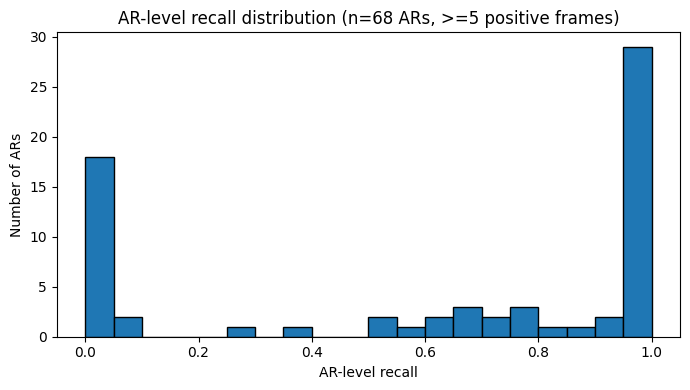


Saved: /kaggle/working/ar_recall_distribution.png


In [57]:
# E8 — Section E: full AR-level recall distribution (n=68 ARs, >=5 positive frames,
# same stability cutoff used throughout the AR-level analysis). Tests whether the 18
# zero-recall ARs sit on a genuine separate cluster or are just the tail of a continuum,
# and whether they can be explained away by having fewer positive frames (noisier estimates).

print(f"## AR-level recall distribution (n={len(ar_pop)} ARs with >=5 positive frames)\n")
print(ar_pop["recall"].describe().round(4))

bins_r = [0, 0.001, 0.25, 0.5, 0.75, 1.0001]
bin_labels = ["==0", "(0,0.25]", "(0.25,0.5]", "(0.5,0.75]", "(0.75,1.0]"]
ar_pop["recall_bin"] = pd.cut(ar_pop["recall"], bins=bins_r, labels=bin_labels, include_lowest=True, right=True)
print("\nAR counts by recall bin:")
print(ar_pop["recall_bin"].value_counts().reindex(bin_labels))

# --- AR-level FN concentration, same style as the FP concentration check in Section C ---
ar_by_fn = ar_summary.sort_values("n_FN", ascending=False).reset_index(drop=True)
ar_by_fn["cum_fn_pct"] = 100 * ar_by_fn["n_FN"].cumsum() / ar_by_fn["n_FN"].sum()
total_ars_fn = len(ar_by_fn)
n_for_50_fn = int((ar_by_fn["cum_fn_pct"] < 50).sum()) + 1
n_for_80_fn = int((ar_by_fn["cum_fn_pct"] < 80).sum()) + 1
print(f"\n## AR-level FN concentration (all {total_ars_fn} test ARs)")
print(f"ARs needed for 50% of all FN: {n_for_50_fn} ({100*n_for_50_fn/total_ars_fn:.1f}% of ARs)")
print(f"ARs needed for 80% of all FN: {n_for_80_fn} ({100*n_for_80_fn/total_ars_fn:.1f}% of ARs)")

# --- does recall==0 simply reflect fewer positive frames (noisier estimate), rather than a
#     genuine detection failure? ---
zero_recall_mask = ar_pop["recall"] == 0
print(f"\n## n_positive: zero-recall ARs vs other ARs")
print(f"Zero-recall (n={zero_recall_mask.sum()}): n_positive median="
      f"{ar_pop.loc[zero_recall_mask,'n_positive'].median():.0f}, mean="
      f"{ar_pop.loc[zero_recall_mask,'n_positive'].mean():.1f}")
print(f"Other (n={(~zero_recall_mask).sum()}): n_positive median="
      f"{ar_pop.loc[~zero_recall_mask,'n_positive'].median():.0f}, mean="
      f"{ar_pop.loc[~zero_recall_mask,'n_positive'].mean():.1f}")
u3, p3 = stats.mannwhitneyu(ar_pop.loc[zero_recall_mask, "n_positive"],
                              ar_pop.loc[~zero_recall_mask, "n_positive"], alternative="two-sided")
print(f"Mann-Whitney U (n_positive, zero-recall vs other): U={u3:.1f}, p={p3:.4f}")
print("(If p is small AND zero-recall ARs have FEWER positive frames, low recall could partly")
print(" reflect noisy small-sample estimates rather than a genuine detection failure.)")

# --- publication-quality plot ---
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(ar_pop["recall"], bins=20, edgecolor="black")
ax.set_xlabel("AR-level recall")
ax.set_ylabel("Number of ARs")
ax.set_title(f"AR-level recall distribution (n={len(ar_pop)} ARs, >=5 positive frames)")
plt.tight_layout()
plt.savefig("/kaggle/working/ar_recall_distribution.png", dpi=150)
plt.show()
print("\nSaved: /kaggle/working/ar_recall_distribution.png")

In [58]:
# E9 — Section F: temporal/contextual error analysis (descriptive only; test set locked)
# F.2: does recall depend on position within the AR's whole observation record?
# F.3: do errors cluster right after unusually large cadence gaps?

# tr (sorted by AR, ts) was built in E4
# --- F.2: position within the AR's whole observation record ---
tr["ar_frac_position"] = tr.groupby("AR").cumcount() / (tr.groupby("AR")["AR"].transform("size") - 1)
tr["seq_stage"] = pd.cut(tr["ar_frac_position"], bins=[-0.01, 0.33, 0.67, 1.01], labels=["early", "mid", "late"])
seq_summary = tr[tr.error_type.isin(["TP", "FN"])].groupby("seq_stage", observed=True).agg(
    n=("error_type", "size"), recall=("error_type", lambda s: (s == "TP").mean())
).reset_index()
print("\n## F.2: Recall by position within the AR's full observation record\n")
print(seq_summary.round(4))

# --- F.3: cadence gaps ---
tr["delta_h"] = tr.groupby("AR")["ts"].diff().dt.total_seconds() / 3600.0
gap_threshold = tr["delta_h"].quantile(0.95)
print(f"\n## F.3: Cadence gap check (95th percentile gap = {gap_threshold:.2f}h)\n")
after_gap = tr[(tr["delta_h"] > gap_threshold) & tr.error_type.isin(["TP", "FN", "FP", "TN"])]
print(f"Frames immediately after a gap > {gap_threshold:.2f}h: {len(after_gap)}")
print("Error-type rates immediately after a large gap:")
print(after_gap["error_type"].value_counts(normalize=True).round(4))
print("\nOverall error-type rates, for comparison:")
print(tr["error_type"].value_counts(normalize=True).round(4))

# --- F.2 significance test: is the early/mid/late recall difference real, or noise? ---
seq_tab = pd.crosstab(
    tr.loc[tr.error_type.isin(["TP", "FN"]), "seq_stage"],
    tr.loc[tr.error_type.isin(["TP", "FN"]), "error_type"]
)
print("\n## F.2 significance test\n")
print(seq_tab)

chi2_f2, p_f2, dof_f2, expected_f2 = chi2_contingency(seq_tab)
print(f"\nChi-square test (recall across early/mid/late AR-sequence position): "
      f"chi2={chi2_f2:.2f}, dof={dof_f2}, p={p_f2:.3e}")

# effect size: Cramer's V (<0.1 negligible, 0.1-0.3 small, 0.3-0.5 moderate, >0.5 large)
n_total = seq_tab.values.sum()
cramers_v = np.sqrt(chi2_f2 / (n_total * (min(seq_tab.shape) - 1)))
print(f"Cramer's V (effect size): {cramers_v:.4f}")


## F.2: Recall by position within the AR's full observation record

  seq_stage     n  recall
0     early  8492  0.8282
1       mid  6344  0.8127
2      late  6706  0.7525

## F.3: Cadence gap check (95th percentile gap = 0.20h)

Frames immediately after a gap > 0.20h: 306
Error-type rates immediately after a large gap:
error_type
TN    0.6275
TP    0.1569
FP    0.1471
FN    0.0686
Name: proportion, dtype: float64

Overall error-type rates, for comparison:
error_type
TN    0.5996
TP    0.1819
FP    0.1731
FN    0.0455
Name: proportion, dtype: float64

## F.2 significance test

error_type    FN    TP
seq_stage             
early       1459  7033
mid         1188  5156
late        1660  5046

Chi-square test (recall across early/mid/late AR-sequence position): chi2=143.37, dof=2, p=7.373e-32
Cramer's V (effect size): 0.0816


In [59]:
# G1 — Grad-CAM setup: output folders, model copy, Grad-CAM class, helpers, verification
import os, json
from datetime import datetime

GRADCAM_ROOT = "/kaggle/working/gradcam"
GRADCAM_DIRS = {
    "sanity_check": f"{GRADCAM_ROOT}/sanity_check",
    "TP": f"{GRADCAM_ROOT}/TP",
    "FP": f"{GRADCAM_ROOT}/FP",
    "FN": f"{GRADCAM_ROOT}/FN",
    "TN": f"{GRADCAM_ROOT}/TN",
    "zero_recall_AR": f"{GRADCAM_ROOT}/zero_recall_AR",
    "metadata": f"{GRADCAM_ROOT}/metadata",
}
for d in GRADCAM_DIRS.values():
    os.makedirs(d, exist_ok=True)
GRADCAM_SEED = 42

# --- separate copy of the frozen CNN-1 (final_model is never touched) ---
# ReLU.inplace=False avoids a PyTorch hook/in-place conflict; weights and math are unchanged.
gradcam_model = CNN1().to(device)
gradcam_ckpt = torch.load(CNN1_CFG["checkpoint_path"], map_location=device, weights_only=False)
gradcam_model.load_state_dict(gradcam_ckpt["model_state"])
gradcam_model.eval()
for m in gradcam_model.modules():
    if isinstance(m, nn.ReLU):
        m.inplace = False

target_layer = gradcam_model.features[5]   # ReLU after the last conv+BN, before AdaptiveAvgPool2d(1)

class GradCAMExplainer:
    """Grad-CAM on the pre-sigmoid logit; generate_full() returns every diagnostic value."""
    def __init__(self, model, layer):
        self.model = model
        self.activations = None
        self.gradients = None
        self.h1 = layer.register_forward_hook(self._fwd)
        self.h2 = layer.register_full_backward_hook(self._bwd)

    def _fwd(self, module, inp, out):
        self.activations = out

    def _bwd(self, module, grad_in, grad_out):
        self.gradients = grad_out[0]

    def generate_full(self, x):
        self.model.zero_grad()
        x = x.clone().requires_grad_(True)
        logit = self.model(x)                 # continuous logit -- NOT the thresholded label
        prob = torch.sigmoid(logit).item()
        logit.backward()
        act = self.activations                 # [1, C, H, W]
        grad = self.gradients                  # [1, C, H, W]
        weights = grad.mean(dim=(2, 3), keepdim=True)
        cam_raw = torch.relu((weights * act).sum(dim=1, keepdim=True))
        cam_up = torch.nn.functional.interpolate(cam_raw, size=(224, 224),
                                                  mode="bilinear", align_corners=False)
        cam_np = cam_up.squeeze().detach().cpu().numpy()
        cam_norm = (cam_np - cam_np.min()) / (cam_np.max() - cam_np.min() + 1e-8)
        return dict(
            logit=logit.item(), prob=prob,
            activation_shape=tuple(act.shape), gradient_shape=tuple(grad.shape),
            cam_raw=cam_np, cam_normalized=cam_norm, heatmap_shape=cam_norm.shape,
            heatmap_min=float(cam_np.min()), heatmap_max=float(cam_np.max()),
            heatmap_mean=float(cam_np.mean()),
        )

    def close(self):
        self.h1.remove(); self.h2.remove()

def load_raw_and_input(ar, filename):
    with Image.open(IMAGE_ROOT_REAL / ar / filename) as im:
        raw = np.asarray(im.convert("L"), dtype=np.float32)
    arr = ((raw / 255.0 - PIXEL_MEAN) / (PIXEL_STD + 1e-8)).astype(np.float32)
    x = torch.from_numpy(arr).unsqueeze(0).unsqueeze(0).to(device)
    return raw, x

explainer = GradCAMExplainer(gradcam_model, target_layer)

# --- verification: this is the exact frozen model ---
print("=" * 60)
print("GRAD-CAM VERIFICATION -- reusing the FROZEN final model")
print("=" * 60)
print(f"MODEL: CNN-1")
print(f"CHECKPOINT: {CNN1_CFG['checkpoint_path']}")
print(f"EPOCH: {gradcam_ckpt['epoch']}")
print(f"DEVICE: {device}")
print(f"MODEL MODE: {'eval' if not gradcam_model.training else 'train'}")
print(f"FINAL CONV LAYER (target): features[5] -> {target_layer}")
print(f"FROZEN DECISION THRESHOLD: {FROZEN_THRESHOLD:.8f}")
print(f"SEED: {GRADCAM_SEED}")

assert gradcam_ckpt["epoch"] == 5, "Grad-CAM checkpoint epoch != 5 -- STOP, not the frozen final model"
assert round(FROZEN_THRESHOLD, 4) == 0.4712, "Threshold does not match the locked value -- STOP"
print("\nChecks passed: using the exact frozen CNN-1 checkpoint (epoch 5) and locked threshold.")

GRAD-CAM VERIFICATION -- reusing the FROZEN final model
MODEL: CNN-1
CHECKPOINT: /kaggle/working/cnn1_best.pt
EPOCH: 5
DEVICE: cuda
MODEL MODE: eval
FINAL CONV LAYER (target): features[5] -> ReLU()
FROZEN DECISION THRESHOLD: 0.47119141
SEED: 42

Checks passed: using the exact frozen CNN-1 checkpoint (epoch 5) and locked threshold.


In [60]:
# G2 -- deterministic, reproducible case selection (seed=42).
# Every case is chosen by an explicit, objective probability-based rule -- no manual
# picking of visually attractive images.

def dist_to_thr(df_sub):
    return (df_sub["p_flare"] - FROZEN_THRESHOLD).abs()

cases = []

for err, sub in [("TP", test_results[test_results.error_type == "TP"]),
                  ("FP", test_results[test_results.error_type == "FP"]),
                  ("FN", test_results[test_results.error_type == "FN"])]:
    # "high-confidence" = the model's most extreme output in the direction consistent
    # with that error type (highest prob for TP/FP; lowest -- most confidently wrong -- for FN)
    ascending_hc = True if err == "FN" else False
    hc = sub.sort_values(["p_flare", "AR", "ts"], ascending=[ascending_hc, True, True]).iloc[0]
    nt = sub.assign(_d=dist_to_thr(sub)).sort_values(["_d", "AR", "ts"]).iloc[0]
    cases.append({"case": f"High-confidence {err}", **hc.to_dict()})
    cases.append({"case": f"Near-threshold {err}", **nt.to_dict()})

# Optional representative TN: probability closest to the TN median (a "typical" negative,
# not the most extreme one, since TN is the optional/context category in the spec).
tn_sub = test_results[test_results.error_type == "TN"]
tn_med = tn_sub["p_flare"].median()
tn_row = tn_sub.assign(_d=(tn_sub["p_flare"] - tn_med).abs()).sort_values(["_d", "AR", "ts"]).iloc[0]
cases.append({"case": "Representative TN", **tn_row.to_dict()})

case_table = pd.DataFrame(cases)
case_table["image_path"] = case_table.apply(lambda r: str(IMAGE_ROOT_REAL / r["AR"] / r["filename"]), axis=1)

display_cols = ["case", "AR", "ts", "label", "pred_label", "p_flare", "error_type", "fscore", "filename"]
print("## Deterministic case selection (TP/FP/FN high-confidence + near-threshold, representative TN)\n")
display(case_table[display_cols].round(4))

case_table.to_csv(f"{GRADCAM_DIRS['metadata']}/main_case_selection.csv", index=False)
print(f"\nSaved: {GRADCAM_DIRS['metadata']}/main_case_selection.csv")

## Deterministic case selection (TP/FP/FN high-confidence + near-threshold, representative TN)



,case,AR,ts,label,pred_label,p_flare,error_type,fscore,filename
0,High-confidence TP,1944,2014-01-04 00:00:00,1,1,1.0000,TP,130.0,1944_hmi.M_720s.20140104_000000_TAI.1.magnetog...
1,Near-threshold TP,1532,2012-08-04 17:12:00,1,1,0.4712,TP,18.0,1532_hmi.M_720s.20120804_171200_TAI.1.magnetog...
2,High-confidence FP,1897,2013-11-16 13:24:00,0,1,0.9990,FP,0.0,1897_hmi.M_720s.20131116_132400_TAI.1.magnetog...
3,Near-threshold FP,1196,2011-04-25 03:36:00,0,1,0.4712,FP,0.0,1196_hmi.M_720s.20110425_033600_TAI.1.magnetog...
4,High-confidence FN,2405,2015-08-29 08:00:00,1,0,0.1302,FN,14.0,2405_hmi.M_720s.20150829_080000_TAI.1.magnetog...
5,Near-threshold FN,1691,2013-03-14 01:48:00,1,0,0.4709,FN,21.0,1691_hmi.M_720s.20130314_014800_TAI.1.magnetog...
6,Representative TN,1076,2010-06-01 22:00:00,0,0,0.2252,TN,0.0,1076_hmi.M_720s.20100601_220000_TAI.1.magnetog...



Saved: /kaggle/working/gradcam/metadata/main_case_selection.csv


## SANITY CHECK -- one known test image

Case: High-confidence TP | AR=1944 | ts=2014-01-04 00:00:00 | filename=1944_hmi.M_720s.20140104_000000_TAI.1.magnetogram_224.png
Image shape (raw): (224, 224)
Model output (logit): 9.302405
Model output (probability): 0.999909  (locked p_flare from FINAL-EVAL: 1.000000)
True label: 1  | Predicted label: 1  | Threshold: 0.4712
Target layer: ReLU()
Activation shape: (1, 128, 28, 28)
Gradient shape: (1, 128, 28, 28)
Heatmap shape (after resize to 224x224): (224, 224)
Heatmap min/max/mean (pre-normalization): 0.000000 / 0.139878 / 0.013098

All sanity assertions PASSED: heatmap is finite, non-constant, correctly shaped, and matches the locked probability.


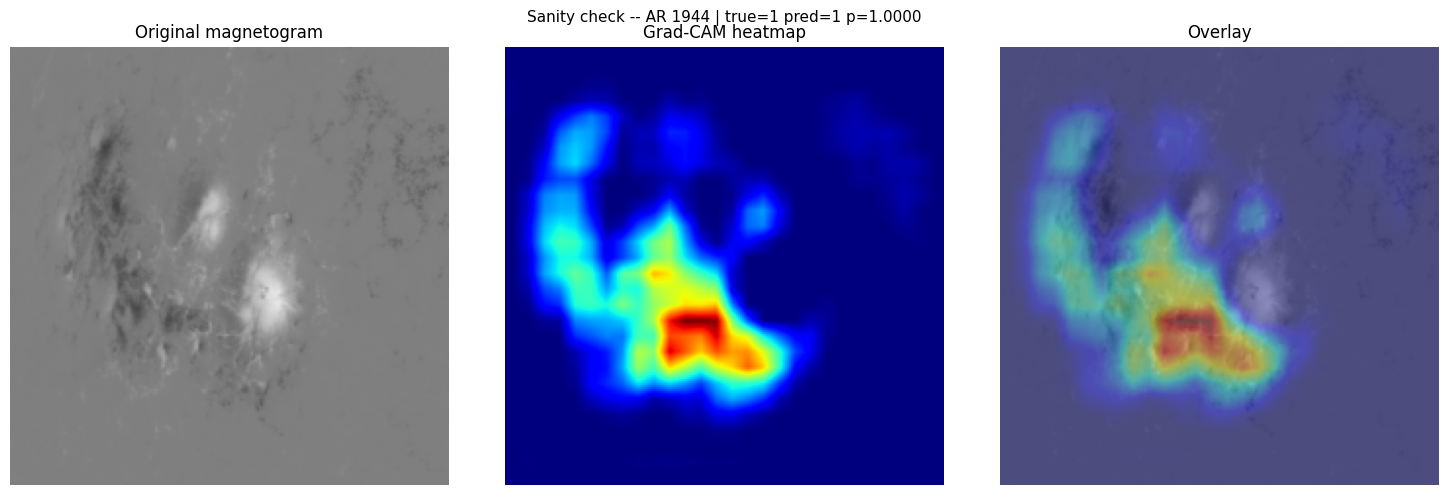


Saved: /kaggle/working/gradcam/sanity_check/sanity_check.png


In [61]:
# G3 -- sanity check on one known test image: probability, shapes, finite/non-constant heatmap
sanity_row = case_table[case_table["case"] == "High-confidence TP"].iloc[0]
raw_img, x_in = load_raw_and_input(sanity_row["AR"], sanity_row["filename"])
diag = explainer.generate_full(x_in)

print("## SANITY CHECK -- one known test image\n")
print(f"Case: High-confidence TP | AR={sanity_row['AR']} | ts={sanity_row['ts']} | filename={sanity_row['filename']}")
print(f"Image shape (raw): {raw_img.shape}")
print(f"Model output (logit): {diag['logit']:.6f}")
print(f"Model output (probability): {diag['prob']:.6f}  (locked p_flare from FINAL-EVAL: {sanity_row['p_flare']:.6f})")
print(f"True label: {int(sanity_row['label'])}  | Predicted label: {int(sanity_row['pred_label'])}  | Threshold: {FROZEN_THRESHOLD:.4f}")
print(f"Target layer: {target_layer}")
print(f"Activation shape: {diag['activation_shape']}")
print(f"Gradient shape: {diag['gradient_shape']}")
print(f"Heatmap shape (after resize to 224x224): {diag['heatmap_shape']}")
print(f"Heatmap min/max/mean (pre-normalization): {diag['heatmap_min']:.6f} / {diag['heatmap_max']:.6f} / {diag['heatmap_mean']:.6f}")

assert abs(diag["prob"] - sanity_row["p_flare"]) < 1e-3, "Sanity-check probability mismatch -- STOP"
assert np.isfinite(diag["cam_raw"]).all(), "Heatmap contains non-finite values -- STOP"
assert diag["cam_raw"].max() > diag["cam_raw"].min(), "Heatmap is constant/degenerate -- STOP"
assert diag["heatmap_shape"] == (224, 224), "Heatmap is not 224x224 -- STOP"
print("\nAll sanity assertions PASSED: heatmap is finite, non-constant, correctly shaped, and matches the locked probability.")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(raw_img, cmap="gray", vmin=0, vmax=255); axes[0].set_title("Original magnetogram"); axes[0].axis("off")
axes[1].imshow(diag["cam_normalized"], cmap="jet"); axes[1].set_title("Grad-CAM heatmap"); axes[1].axis("off")
axes[2].imshow(raw_img, cmap="gray", vmin=0, vmax=255)
axes[2].imshow(diag["cam_normalized"], cmap="jet", alpha=0.40)
axes[2].set_title("Overlay"); axes[2].axis("off")
fig.suptitle(f"Sanity check -- AR {sanity_row['AR']} | true={int(sanity_row['label'])} pred={int(sanity_row['pred_label'])} "
             f"p={sanity_row['p_flare']:.4f}", fontsize=11)
plt.tight_layout()
plt.savefig(f"{GRADCAM_DIRS['sanity_check']}/sanity_check.png", dpi=150)
plt.show()
print(f"\nSaved: {GRADCAM_DIRS['sanity_check']}/sanity_check.png")

In [62]:
# G4 -- generate + save one annotated 3-panel figure per selected case
# (original / heatmap / overlay, with label/pred/prob/error/AR/ts
# annotations, consistent formatting, no image enhancement beyond the heatmap overlay).

def make_gradcam_figure(row, out_path, explainer=explainer):
    raw, x = load_raw_and_input(row["AR"], row["filename"])
    diag = explainer.generate_full(x)
    prob_ok = abs(diag["prob"] - row["p_flare"]) < 1e-3   # cross-check vs the locked prediction

    fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.6))
    axes[0].imshow(raw, cmap="gray", vmin=0, vmax=255); axes[0].set_title("Original"); axes[0].axis("off")
    axes[1].imshow(diag["cam_normalized"], cmap="jet"); axes[1].set_title("Grad-CAM"); axes[1].axis("off")
    axes[2].imshow(raw, cmap="gray", vmin=0, vmax=255)
    axes[2].imshow(diag["cam_normalized"], cmap="jet", alpha=0.40)
    axes[2].set_title("Overlay"); axes[2].axis("off")

    fscore_val = row["fscore"] if "fscore" in row and pd.notna(row["fscore"]) else float("nan")
    fig.suptitle(
        f"{row['case']} | AR {row['AR']} | {row['ts']}\n"
        f"true={int(row['label'])} pred={int(row['pred_label'])} p={row['p_flare']:.4f} "
        f"({row['error_type']}) | fscore={fscore_val:.1f}",
        fontsize=10,
    )
    plt.tight_layout()
    plt.savefig(out_path, dpi=150)
    plt.close(fig)
    return diag, prob_ok

FOLDER_BY_ERROR = {"TP": "TP", "FP": "FP", "FN": "FN", "TN": "TN"}
gradcam_stats = []

for _, row in case_table.iterrows():
    folder = GRADCAM_DIRS[FOLDER_BY_ERROR[row["error_type"]]]
    fname = f"{row['case'].replace(' ', '_')}_AR{row['AR']}.png"
    out_path = f"{folder}/{fname}"
    diag, prob_ok = make_gradcam_figure(row, out_path)
    if not prob_ok:
        print(f"WARNING: probability mismatch for case '{row['case']}' (AR {row['AR']}) -- "
              f"recomputed p={diag['prob']:.4f} vs locked p_flare={row['p_flare']:.4f}")
    # quantitative summary: mean/max activation, area above
    # a fixed normalized threshold, centroid of the high-activation region.
    area_above = float((diag["cam_normalized"] >= 0.5).mean())
    yx = np.argwhere(diag["cam_normalized"] >= 0.5)
    centroid = tuple(yx.mean(axis=0)) if len(yx) else (float("nan"), float("nan"))
    gradcam_stats.append({
        "case": row["case"], "AR": row["AR"], "ts": row["ts"], "error_type": row["error_type"],
        "p_flare": row["p_flare"], "prob_check": diag["prob"], "prob_match": prob_ok,
        "heatmap_mean": diag["heatmap_mean"], "heatmap_max": diag["heatmap_max"],
        "area_frac_above_0.5": area_above, "centroid_row": centroid[0], "centroid_col": centroid[1],
        "figure_path": out_path,
    })
    print(f"Saved: {out_path}  (p_check={diag['prob']:.4f}, match={prob_ok})")

print(f"\nAll {len(case_table)} main-category Grad-CAM figures generated and saved.")

Saved: /kaggle/working/gradcam/TP/High-confidence_TP_AR1944.png  (p_check=0.9999, match=True)
Saved: /kaggle/working/gradcam/TP/Near-threshold_TP_AR1532.png  (p_check=0.4715, match=True)
Saved: /kaggle/working/gradcam/FP/High-confidence_FP_AR1897.png  (p_check=0.9989, match=True)
Saved: /kaggle/working/gradcam/FP/Near-threshold_FP_AR1196.png  (p_check=0.4715, match=True)
Saved: /kaggle/working/gradcam/FN/High-confidence_FN_AR2405.png  (p_check=0.1303, match=True)
Saved: /kaggle/working/gradcam/FN/Near-threshold_FN_AR1691.png  (p_check=0.4712, match=True)
Saved: /kaggle/working/gradcam/TN/Representative_TN_AR1076.png  (p_check=0.2252, match=True)

All 7 main-category Grad-CAM figures generated and saved.


In [63]:
# G5 -- Grad-CAM for zero-recall ARs and FP-heavy ARs
# Deterministic selection, seed=42: the 3 zero-recall ARs with the most positive frames
# (most data to choose from), and -- within each -- the lowest-, median-, and
# highest-probability FN frame (low- vs higher-probability FN cases, where they exist).
# A matched comparison set is drawn the same way from "working" ARs (recall > 0,
# n_positive >= 5), using the top-3 working ARs by n_positive for a data-comparable set.
# This does NOT claim the zero-recall ARs are physically different -- it only asks whether
# the model's spatial attention differs qualitatively between the two groups.

zr_pop = ar_summary[ar_summary["AR"].isin(zero_recall_ars)].sort_values("n_positive", ascending=False)
zr_top_ars = zr_pop["AR"].head(3).tolist()
print(f"Zero-recall ARs selected (most positive frames): {zr_top_ars}")

working_pop = ar_summary[(ar_summary["n_positive"] >= 5) & (ar_summary["recall"] > 0)
                          & (~ar_summary["AR"].isin(zero_recall_ars))].sort_values("n_positive", ascending=False)
working_top_ars = working_pop["AR"].head(3).tolist()
print(f"Working ARs selected for comparison (recall > 0, most positive frames): {working_top_ars}")

def pick_low_med_high(df_sub, ar_id, err_type, group_label):
    sub = (df_sub[(df_sub["AR"] == ar_id) & (df_sub["error_type"] == err_type)]
           .sort_values(["p_flare", "ts"]).reset_index(drop=True))
    n = len(sub)
    if n == 0:
        return []
    if n == 1:
        slots = [(0, "only-available")]
    elif n == 2:
        slots = [(0, "low-probability"), (n - 1, "high-probability")]
    else:
        slots = [(0, "low-probability"), (n // 2, "median-probability"), (n - 1, "high-probability")]
    picks, seen = [], set()
    for i, tag in slots:
        if i in seen:
            continue
        seen.add(i)
        row = sub.iloc[i]
        picks.append({"case": f"{group_label} {err_type} ({tag})", **row.to_dict()})
    return picks

zr_cases = []
for ar_id in zr_top_ars:
    zr_cases += pick_low_med_high(test_results, ar_id, "FN", "Zero-recall AR")
for ar_id in working_top_ars:
    zr_cases += pick_low_med_high(test_results, ar_id, "FN", "Working AR")
    zr_cases += pick_low_med_high(test_results, ar_id, "TP", "Working AR")

zr_case_table = pd.DataFrame(zr_cases)
zr_case_table["image_path"] = zr_case_table.apply(lambda r: str(IMAGE_ROOT_REAL / r["AR"] / r["filename"]), axis=1)
print(f"\nTotal zero-recall-AR-analysis cases: {len(zr_case_table)}")
display(zr_case_table[["case", "AR", "ts", "label", "pred_label", "p_flare", "error_type", "fscore"]].round(4))

zr_case_table.to_csv(f"{GRADCAM_DIRS['metadata']}/zero_recall_AR_case_selection.csv", index=False)

# ---- FP-heavy ARs: top-3 by raw FP count (ar_fp_sorted from E5) ----
fp_heavy_ars = ar_fp_sorted["AR"].head(3).tolist()
print(f"\nFP-heavy ARs selected (highest raw FP count): {fp_heavy_ars}")

fp_cases = []
for ar_id in fp_heavy_ars:
    fp_cases += pick_low_med_high(test_results, ar_id, "FP", "FP-heavy AR")

fp_case_table = pd.DataFrame(fp_cases)
fp_case_table["image_path"] = fp_case_table.apply(lambda r: str(IMAGE_ROOT_REAL / r["AR"] / r["filename"]), axis=1)
print(f"Total FP-heavy-AR-analysis cases: {len(fp_case_table)}")
display(fp_case_table[["case", "AR", "ts", "label", "pred_label", "p_flare", "error_type"]].round(4))
fp_case_table.to_csv(f"{GRADCAM_DIRS['metadata']}/fp_heavy_AR_case_selection.csv", index=False)

# ---- one shared render + stats + save loop for both groups ----
def run_group(case_tbl, out_dir, tag):
    rows = []
    for _, row in case_tbl.iterrows():
        fname = f"{row['case'].replace(' ', '_').replace('(', '').replace(')', '')}_AR{row['AR']}.png"
        out_path = f"{out_dir}/{fname}"
        diag, prob_ok = make_gradcam_figure(row, out_path)
        rows.append({"case": row["case"], "AR": row["AR"], "p_flare": row["p_flare"],
                     "prob_match": prob_ok, "heatmap_mean": diag["heatmap_mean"],
                     "area_frac_above_0.5": float((diag["cam_normalized"] >= 0.5).mean()),
                     "figure_path": out_path})
        print(f"Saved: {out_path} (p_check={diag['prob']:.4f}, match={prob_ok})")
    pd.DataFrame(rows).to_csv(f"{GRADCAM_DIRS['metadata']}/{tag}_gradcam_stats.csv", index=False)
    return rows

zr_stats = run_group(zr_case_table, GRADCAM_DIRS["zero_recall_AR"], "zero_recall_AR")
fp_stats = run_group(fp_case_table, GRADCAM_DIRS["FP"], "fp_heavy_AR")

Zero-recall ARs selected (most positive frames): ['1528', '2405', '1467']
Working ARs selected for comparison (recall > 0, most positive frames): ['2205', '2297', '2268']

Total zero-recall-AR-analysis cases: 18


,case,AR,ts,label,pred_label,p_flare,error_type,fscore
0,Zero-recall AR FN (low-probability),1528,2012-07-29 01:36:00,1,0,0.1735,FN,15.0
1,Zero-recall AR FN (median-probability),1528,2012-07-31 22:12:00,1,0,0.3201,FN,15.0
2,Zero-recall AR FN (high-probability),1528,2012-07-27 04:00:00,1,0,0.4641,FN,50.0
3,Zero-recall AR FN (low-probability),2405,2015-08-29 08:00:00,1,0,0.1302,FN,14.0
4,Zero-recall AR FN (median-probability),2405,2015-08-30 00:36:00,1,0,0.2257,FN,10.0
5,Zero-recall AR FN (high-probability),2405,2015-08-28 23:36:00,1,0,0.3059,FN,14.0
6,Zero-recall AR FN (low-probability),1467,2012-04-26 13:48:00,1,0,0.2588,FN,20.0
7,Zero-recall AR FN (median-probability),1467,2012-04-28 08:24:00,1,0,0.3298,FN,11.0
8,Zero-recall AR FN (high-probability),1467,2012-04-27 11:36:00,1,0,0.3962,FN,20.0
9,Working AR TP (low-probability),2205,2014-11-14 14:48:00,1,1,0.6519,TP,31.0



FP-heavy ARs selected (highest raw FP count): ['1770', '2155', '1745']
Total FP-heavy-AR-analysis cases: 9


,case,AR,ts,label,pred_label,p_flare,error_type
0,FP-heavy AR FP (low-probability),1770,2013-06-20 09:24:00,0,1,0.4719,FP
1,FP-heavy AR FP (median-probability),1770,2013-06-17 12:36:00,0,1,0.6743,FP
2,FP-heavy AR FP (high-probability),1770,2013-06-18 05:48:00,0,1,0.8550,FP
3,FP-heavy AR FP (low-probability),2155,2014-09-08 04:24:00,0,1,0.4712,FP
4,FP-heavy AR FP (median-probability),2155,2014-09-12 21:00:00,0,1,0.5981,FP
5,FP-heavy AR FP (high-probability),2155,2014-09-05 16:12:00,0,1,0.9150,FP
6,FP-heavy AR FP (low-probability),1745,2013-05-20 02:36:00,0,1,0.4714,FP
7,FP-heavy AR FP (median-probability),1745,2013-05-18 06:36:00,0,1,0.6699,FP
8,FP-heavy AR FP (high-probability),1745,2013-05-14 00:24:00,0,1,0.9683,FP


Saved: /kaggle/working/gradcam/zero_recall_AR/Zero-recall_AR_FN_low-probability_AR1528.png (p_check=0.1736, match=True)
Saved: /kaggle/working/gradcam/zero_recall_AR/Zero-recall_AR_FN_median-probability_AR1528.png (p_check=0.3201, match=True)
Saved: /kaggle/working/gradcam/zero_recall_AR/Zero-recall_AR_FN_high-probability_AR1528.png (p_check=0.4643, match=True)
Saved: /kaggle/working/gradcam/zero_recall_AR/Zero-recall_AR_FN_low-probability_AR2405.png (p_check=0.1303, match=True)
Saved: /kaggle/working/gradcam/zero_recall_AR/Zero-recall_AR_FN_median-probability_AR2405.png (p_check=0.2259, match=True)
Saved: /kaggle/working/gradcam/zero_recall_AR/Zero-recall_AR_FN_high-probability_AR2405.png (p_check=0.3059, match=True)
Saved: /kaggle/working/gradcam/zero_recall_AR/Zero-recall_AR_FN_low-probability_AR1467.png (p_check=0.2588, match=True)
Saved: /kaggle/working/gradcam/zero_recall_AR/Zero-recall_AR_FN_median-probability_AR1467.png (p_check=0.3301, match=True)
Saved: /kaggle/working/gradca

In [64]:
# G6 -- combine metadata, write the full reproducibility record, and remove hooks.
# The frozen `final_model` used for the locked test evaluation was never touched by any
# Grad-CAM cell; only `gradcam_model`, a separately loaded copy, was used.

all_case_meta = pd.concat([
    case_table.assign(analysis="main"),
    zr_case_table.assign(analysis="zero_recall_AR"),
    fp_case_table.assign(analysis="fp_heavy_AR"),
], ignore_index=True)
all_case_meta.to_csv(f"{GRADCAM_DIRS['metadata']}/all_selected_cases.csv", index=False)
print(f"Saved combined metadata: {GRADCAM_DIRS['metadata']}/all_selected_cases.csv  ({len(all_case_meta)} cases)")

all_stats = pd.concat([
    pd.DataFrame(gradcam_stats).assign(analysis="main"),
    pd.DataFrame(zr_stats).assign(analysis="zero_recall_AR"),
    pd.DataFrame(fp_stats).assign(analysis="fp_heavy_AR"),
], ignore_index=True)
all_stats.to_csv(f"{GRADCAM_DIRS['metadata']}/all_gradcam_quantitative_stats.csv", index=False)
print(f"Saved combined quantitative stats: {GRADCAM_DIRS['metadata']}/all_gradcam_quantitative_stats.csv")

repro_gc = dict(
    seed=GRADCAM_SEED,
    checkpoint_path=CNN1_CFG["checkpoint_path"],
    checkpoint_epoch=gradcam_ckpt["epoch"],
    architecture="CNN1 (see cell B6 in this notebook)",
    target_layer=str(target_layer),
    target_layer_name="features[5] (final ReLU after last conv+BN, pre-GAP)",
    image_preprocessing=f"grayscale, /255, normalize with TRAIN pixel_mean={PIXEL_MEAN:.6f}, pixel_std={PIXEL_STD:.6f}",
    decision_threshold=float(FROZEN_THRESHOLD),
    gradcam_target="pre-sigmoid logit (continuous), not the thresholded label",
    n_main_cases=len(case_table),
    n_zero_recall_cases=len(zr_case_table),
    n_fp_heavy_cases=len(fp_case_table),
    zero_recall_ARs_used=zr_top_ars,
    working_ARs_used=working_top_ars,
    fp_heavy_ARs_used=fp_heavy_ars,
    all_probability_checks_passed=bool(all_stats["prob_match"].all()),
    generated_at=datetime.now().isoformat(timespec="seconds"),
)
with open(f"{GRADCAM_DIRS['metadata']}/gradcam_reproducibility_record.json", "w") as f:
    json.dump(repro_gc, f, indent=2, default=str)
print(f"\nSaved: {GRADCAM_DIRS['metadata']}/gradcam_reproducibility_record.json")
for k, v in repro_gc.items():
    print(f"  {k}: {v}")

explainer.close()
print("\nGrad-CAM hooks removed. Frozen final_model (used for the locked test evaluation) was never touched.")

Saved combined metadata: /kaggle/working/gradcam/metadata/all_selected_cases.csv  (34 cases)
Saved combined quantitative stats: /kaggle/working/gradcam/metadata/all_gradcam_quantitative_stats.csv

Saved: /kaggle/working/gradcam/metadata/gradcam_reproducibility_record.json
  seed: 42
  checkpoint_path: /kaggle/working/cnn1_best.pt
  checkpoint_epoch: 5
  architecture: CNN1 (see cell B6 in this notebook)
  target_layer: ReLU()
  target_layer_name: features[5] (final ReLU after last conv+BN, pre-GAP)
  image_preprocessing: grayscale, /255, normalize with TRAIN pixel_mean=0.499992, pixel_std=0.018177
  decision_threshold: 0.47119140625
  gradcam_target: pre-sigmoid logit (continuous), not the thresholded label
  n_main_cases: 7
  n_zero_recall_cases: 18
  n_fp_heavy_cases: 9
  zero_recall_ARs_used: ['1528', '2405', '1467']
  working_ARs_used: ['2205', '2297', '2268']
  fp_heavy_ARs_used: ['1770', '2155', '1745']
  all_probability_checks_passed: True
  generated_at: 2026-09-24T14:04:52

Gra